# 🔬 Cluster Resegmentation — SEG_B / SEG_C Universe V2

**Objetivo:** Replantear la segmentación de médicos utilizando clustering no supervisado, análisis jerárquico y modelos supervisados.

---

## Estructura del Notebook

| Parte | Descripción |
|-------|-------------|
| 1 | Carga y Unificación |
| 2 | Filtrado del Universo (excluir SEG_A) |
| 3 | Preprocesamiento y PCA |
| 4 | Escenario A — 2 Clusters |
| 5 | Escenario B — K Óptimo |
| **5.5** | **Hierarchical Clustering Analysis** |
| 6 | Interpretabilidad |
| 7 | Comparación vs SEG_B / SEG_C Históricos |
| 8 | Modelos Supervisados: Random Forest vs Neural Network |

In [2]:
# Visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from matplotlib.axes import Axes
from matplotlib.figure import Figure
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('⚠️  UMAP no instalado. Usar: pip install umap-learn')

# ── Plot Style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.edgecolor': '#DDDDDD',
    'axes.grid': True,
    'grid.color': '#EEEEEE',
    'grid.linestyle': '--',
    'font.family': 'sans-serif',
    'figure.dpi': 120,
    # Legend visibility / contrast
    'legend.frameon': True,
    'legend.facecolor': 'white',
    'legend.edgecolor': '#333333',
    'legend.framealpha': 0.95,
    'legend.fontsize': 10,
    # Text/axis color to ensure contrast
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black'

⚠️  UMAP no instalado. Usar: pip install umap-learn
✅  Imports OK
✅  Auto-legend visibility patch activo
   UMAP disponible: False


---
## PARTE 1 — Carga y Unificación

Cargamos ambos datasets y los unificamos por `NUEVO_ID`. Creamos `SEGMENT_FINAL` con la lógica de prioridad: **ATSEG_FINAL** (modelo SVM) > **ATSEG_first** (histórico).

In [3]:
# ============================================================
# PARTE 1 — CARGA Y UNIFICACIÓN
# ============================================================

# ── Carga de archivos ─────────────────────────────────────
df_main = pd.read_csv('doctors_aggregated.csv', low_memory=False)
df_svm  = pd.read_csv('doctors_svm_atseg_completed.csv', low_memory=False)

print(f'📋  doctors_aggregated.csv     : {df_main.shape[0]:,} filas × {df_main.shape[1]} columnas')
print(f'📋  doctors_svm_atseg_completed: {df_svm.shape[0]:,} filas × {df_svm.shape[1]} columnas')

# ── Merge ─────────────────────────────────────────────────
df = df_main.merge(df_svm[['NUEVO_ID','ATSEG_FINAL','PROB_SEG_A','PROB_SEG_B',
                             'PROB_SEG_C','CONFIDENCE']],
                   on='NUEVO_ID', how='left')

print(f'\n🔗  Merge resultado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'    IDs sin match SVM: {df["ATSEG_FINAL"].isna().sum():,}')

# ── Variable maestra SEGMENT_FINAL ────────────────────────
def assign_segment_final(row):
    """Prioridad: ATSEG_FINAL > ATSEG_first"""
    if pd.notna(row.get('ATSEG_FINAL')) and str(row['ATSEG_FINAL']).strip() not in ('', 'nan', '0'):
        return str(row['ATSEG_FINAL']).strip()
    val = str(row.get('ATSEG_first', '')).strip()
    return val if val not in ('', 'nan', '0') else 'UNLABELED'

df['SEGMENT_FINAL'] = df.apply(assign_segment_final, axis=1)

print('\n📊  Distribución SEGMENT_FINAL:')
print(df['SEGMENT_FINAL'].value_counts().to_string())

📋  doctors_aggregated.csv     : 20,931 filas × 151 columnas
📋  doctors_svm_atseg_completed: 20,931 filas × 11 columnas

🔗  Merge resultado: 20,931 filas × 156 columnas
    IDs sin match SVM: 0

📊  Distribución SEGMENT_FINAL:
SEGMENT_FINAL
SEG_A    13666
SEG_B     4506
SEG_C     2759


C:\Users\cocoi\AppData\Local\Temp\ipykernel_25908\3073601740.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['SEGMENT_FINAL'] = df.apply(assign_segment_final, axis=1)


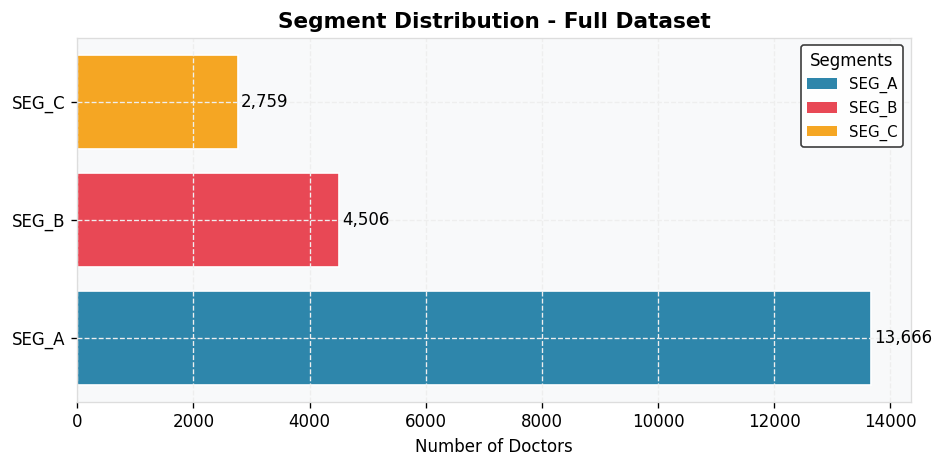

✅  fig_01_segment_distribution.png saved


In [4]:
# -- Segment Distribution Visualization --
seg_counts = df['SEGMENT_FINAL'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(seg_counts.index, seg_counts.values,
               color=PALETTE[:len(seg_counts)], edgecolor='white')
for bar, val in zip(bars, seg_counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Number of Doctors')
ax.set_title('Segment Distribution - Full Dataset', fontsize=13, fontweight='bold')

# Explicit legend so the color mapping is always visible
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[i], label=seg)
    for i, seg in enumerate(seg_counts.index.tolist())
]
ax.legend(handles=legend_elements, title='Segments', fontsize=9)

plt.tight_layout()
plt.savefig('fig_01_segment_distribution.png', bbox_inches='tight')
plt.show()
print('✅  fig_01_segment_distribution.png saved')

---
## PARTE 2 — Filtrado del Universo

Excluimos todos los registros con `SEGMENT_FINAL == 'SEG_A'`. Trabajaremos únicamente con **SEG_B**, **SEG_C** y usuarios sin etiqueta previa.

In [5]:
# ============================================================
# PARTE 2 — FILTRADO DEL UNIVERSO
# ============================================================

total_antes = len(df)
df_bc = df[df['SEGMENT_FINAL'] != 'SEG_A'].copy().reset_index(drop=True)
excluidos = total_antes - len(df_bc)

print(f'📉  Universo inicial    : {total_antes:,}')
print(f'❌  Excluidos (SEG_A)  : {excluidos:,} ({excluidos/total_antes:.1%})')
print(f'✅  Universo de trabajo : {len(df_bc):,}')
print()
print('Distribución del universo de trabajo:')
print(df_bc['SEGMENT_FINAL'].value_counts().to_string())

# Guardar ID del universo
IDs_bc = df_bc['NUEVO_ID'].copy()

📉  Universo inicial    : 20,931
❌  Excluidos (SEG_A)  : 13,666 (65.3%)
✅  Universo de trabajo : 7,265

Distribución del universo de trabajo:
SEGMENT_FINAL
SEG_B    4506
SEG_C    2759


---
## PARTE 3 — Preprocesamiento

Pasos:
1. Eliminar columnas con *leakage* (ATSEG, probabilidades del modelo, targets)
2. Separar ID y features
3. Identificar columnas numéricas y categóricas
4. Eliminar columnas constantes / quasi-constantes
5. Imputar missings
6. Escalar variables numéricas
7. PCA (85–95% varianza explicada)

In [6]:
# ============================================================
# PARTE 3 — PREPROCESAMIENTO
# ============================================================

# ── 3.1 Identificar columnas de leakage ───────────────────
LEAKAGE_PATTERNS = [
    'ATSEG', 'SEGMENT_FINAL', 'PROB_SEG', 'CONFIDENCE',
    'ATSEG_FINAL', 'ATSEG_first', 'NUEVO_ID'
]

def is_leakage(col):
    col_up = col.upper()
    return any(p in col_up for p in LEAKAGE_PATTERNS)

leakage_cols = [c for c in df_bc.columns if is_leakage(c)]
print(f'🚫  Columnas leakage eliminadas ({len(leakage_cols)}):' )
print('   ', leakage_cols)

# ── 3.2 Separar features ──────────────────────────────────
feature_cols = [c for c in df_bc.columns if c not in leakage_cols]
X_raw = df_bc[feature_cols].copy()

# ── 3.3 Separar numéricas y categóricas ───────────────────
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'\n📊  Variables numéricas  : {len(num_cols)}')
print(f'📊  Variables categóricas: {len(cat_cols)}')

# ── 3.4 Eliminar constantes y quasi-constantes (>98% mismo valor) ──
def remove_low_variance(df_in, cols, threshold=0.98):
    to_drop = []
    for c in cols:
        top_freq = df_in[c].value_counts(normalize=True, dropna=False).iloc[0]
        if top_freq >= threshold:
            to_drop.append(c)
    return to_drop

drop_num  = remove_low_variance(X_raw, num_cols)
drop_cat  = remove_low_variance(X_raw, cat_cols)
all_drops = drop_num + drop_cat
print(f'\n🗑️   Columnas quasi-constantes eliminadas: {len(all_drops)}')

num_cols = [c for c in num_cols if c not in all_drops]
cat_cols = [c for c in cat_cols if c not in all_drops]
print(f'   Numéricas restantes  : {len(num_cols)}')
print(f'   Categóricas restantes: {len(cat_cols)}')

🚫  Columnas leakage eliminadas (8):
    ['NUEVO_ID', 'ATSEG_first', 'ATSEG_FINAL', 'PROB_SEG_A', 'PROB_SEG_B', 'PROB_SEG_C', 'CONFIDENCE', 'SEGMENT_FINAL']

📊  Variables numéricas  : 147
📊  Variables categóricas: 2

🗑️   Columnas quasi-constantes eliminadas: 4
   Numéricas restantes  : 143
   Categóricas restantes: 2


In [7]:
# ── 3.5 Encode categóricas ────────────────────────────────
X_work = X_raw[num_cols + cat_cols].copy()

if cat_cols:
    # One-hot encoding para categóricas de baja cardinalidad
    high_card  = [c for c in cat_cols if X_work[c].nunique() > 20]
    low_card   = [c for c in cat_cols if X_work[c].nunique() <= 20]
    
    if low_card:
        X_ohe = pd.get_dummies(X_work[low_card], drop_first=True).astype(float)
        X_work = pd.concat([X_work[num_cols], X_ohe], axis=1)
    else:
        X_work = X_work[num_cols]
    
    if high_card:
        print(f'⚠️   Descartadas {len(high_card)} columnas categóricas de alta cardinalidad (>20 valores)')
else:
    X_work = X_work[num_cols]

all_feature_names = X_work.columns.tolist()
print(f'✅  Features finales para modelado: {len(all_feature_names)}')

# ── 3.6 Imputación de missings ────────────────────────────
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_work)
X_imputed = pd.DataFrame(X_imputed, columns=all_feature_names)

missing_report = X_work.isnull().sum()
print(f'\n📋  Missing antes de imputar: {missing_report.sum():,} valores')
print(f'    Missing después de imputar: {X_imputed.isnull().sum().sum()}')

# ── 3.7 Escalado con StandardScaler ──────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
print(f'\n✅  Escalado aplicado — shape: {X_scaled.shape}')

⚠️   Descartadas 2 columnas categóricas de alta cardinalidad (>20 valores)
✅  Features finales para modelado: 143

📋  Missing antes de imputar: 0 valores
    Missing después de imputar: 0

✅  Escalado aplicado — shape: (7265, 143)


📐  Components for 85% variance: 23
📐  Components for 95% variance: 41
✅  Selected N_COMPONENTS (90%): 30
   Actual explained variance: 0.904


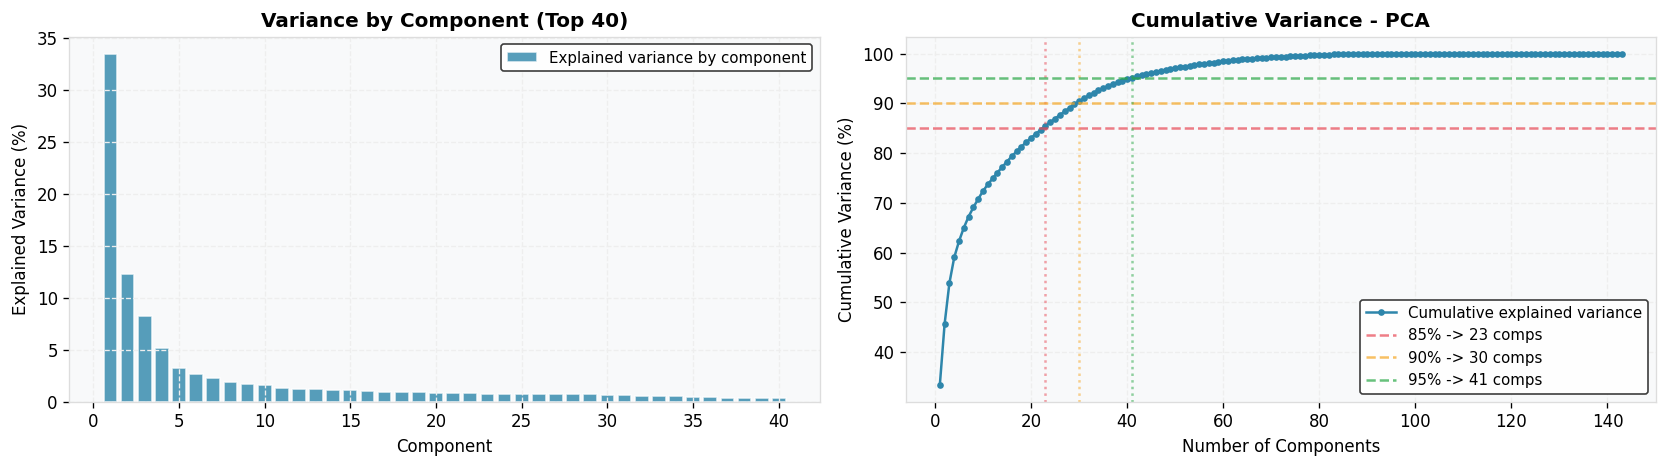

✅  fig_02_pca_variance.png saved


In [8]:
# -- 3.8 PCA: Dimensionality Reduction --
pca_full = PCA(random_state=RANDOM)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_85 = np.argmax(cumvar >= 0.85) + 1
n_comp_95 = np.argmax(cumvar >= 0.95) + 1

print(f'📐  Components for 85% variance: {n_comp_85}')
print(f'📐  Components for 95% variance: {n_comp_95}')

# Choose the smallest number of components achieving ~90% variance
n_comp_90 = np.argmax(cumvar >= 0.90) + 1
N_COMPONENTS = n_comp_90
print(f'✅  Selected N_COMPONENTS (90%): {N_COMPONENTS}')

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM)
X_pca = pca.fit_transform(X_scaled)
print(f'   Actual explained variance: {pca.explained_variance_ratio_.sum():.3f}')

# PCA 2D for visualizations
pca_2d = PCA(n_components=2, random_state=RANDOM)
X_pca2 = pca_2d.fit_transform(X_scaled)

# -- Explained variance plots --
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Variance by component
axes[0].bar(range(1, min(41, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:40] * 100,
            color='#2E86AB', alpha=0.8, edgecolor='white',
            label='Explained variance by component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Variance by Component (Top 40)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, 'o-', color='#2E86AB', markersize=3,
             label='Cumulative explained variance')
for thresh, col, lbl in [(0.85, '#E84855','85%'), (0.90, '#F5A623','90%'), (0.95, '#28A745','95%')]:
    comp = np.argmax(cumvar >= thresh) + 1
    axes[1].axhline(thresh*100, color=col, linestyle='--', alpha=0.7, label=f'{lbl} -> {comp} comps')
    axes[1].axvline(comp, color=col, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance - PCA', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_02_pca_variance.png', bbox_inches='tight')
plt.show()
print('✅  fig_02_pca_variance.png saved')

---
## PARTE 4 — Escenario A: 2 Clusters

Probamos tres algoritmos con `n_clusters=2` y seleccionamos el mejor según métricas internas:
- **Silhouette Score** (más alto = mejor separación)
- **Davies-Bouldin** (más bajo = mejor)
- **Calinski-Harabasz** (más alto = mejor)

In [9]:
# ============================================================
# PARTE 4 — ESCENARIO A: 2 CLUSTERS
# ============================================================

results_2 = {}

def evaluate_clustering(labels, X, name):
    """Calcula las tres métricas estándar de clustering."""
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    print(f'  [{name}]  Silhouette={sil:.4f}  Davies-Bouldin={db:.4f}  Calinski-Harabasz={ch:.1f}')
    return {'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch}

print('=== ESCENARIO A: 2 CLUSTERS ===')

# ── KMeans ────────────────────────────────────────────────
km2 = KMeans(n_clusters=2, random_state=RANDOM, n_init=20, max_iter=500)
labels_km2 = km2.fit_predict(X_pca)
results_2['KMeans(2)'] = evaluate_clustering(labels_km2, X_pca, 'KMeans(2)')
results_2['KMeans(2)']['labels'] = labels_km2

# ── Gaussian Mixture ──────────────────────────────────────
gm2 = GaussianMixture(n_components=2, random_state=RANDOM, n_init=5, covariance_type='full')
gm2.fit(X_pca)
labels_gm2 = gm2.predict(X_pca)
results_2['GMM(2)'] = evaluate_clustering(labels_gm2, X_pca, 'GMM(2)')
results_2['GMM(2)']['labels'] = labels_gm2

# ── Agglomerative ─────────────────────────────────────────
agg2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agg2 = agg2.fit_predict(X_pca)
results_2['Agglomerative(2)'] = evaluate_clustering(labels_agg2, X_pca, 'Agglomerative(2)')
results_2['Agglomerative(2)']['labels'] = labels_agg2

print()

=== ESCENARIO A: 2 CLUSTERS ===
  [KMeans(2)]  Silhouette=0.3833  Davies-Bouldin=1.5761  Calinski-Harabasz=2129.8
  [GMM(2)]  Silhouette=0.2445  Davies-Bouldin=2.2291  Calinski-Harabasz=1246.5
  [Agglomerative(2)]  Silhouette=0.4761  Davies-Bouldin=1.2888  Calinski-Harabasz=1732.1



In [11]:
# ── Tabla comparativa y selección del mejor modelo ────────
metrics_df = pd.DataFrame({
    model: {
        'Silhouette ↑': v['silhouette'],
        'Davies-Bouldin ↓': v['davies_bouldin'],
        'Calinski-Harabasz ↑': v['calinski_harabasz']
    }
    for model, v in results_2.items()
}).T.round(4)

display(metrics_df.style
        .background_gradient(subset=['Silhouette ↑'], cmap='Greens')
        .background_gradient(subset=['Davies-Bouldin ↓'], cmap='Reds_r')
        .background_gradient(subset=['Calinski-Harabasz ↑'], cmap='Blues')
        .set_caption('Comparación de modelos — 2 Clusters'))

# Selección: máximo Silhouette como criterio principal
best_model_2 = max(results_2, key=lambda k: results_2[k]['silhouette'])
LABELS_2 = results_2[best_model_2]['labels']

print(f'\n🏆  MEJOR MODELO (2 clusters): {best_model_2}')
print(f'    Distribución: {pd.Series(LABELS_2).value_counts().to_dict()}')

AttributeError: The '.style' accessor requires jinja2

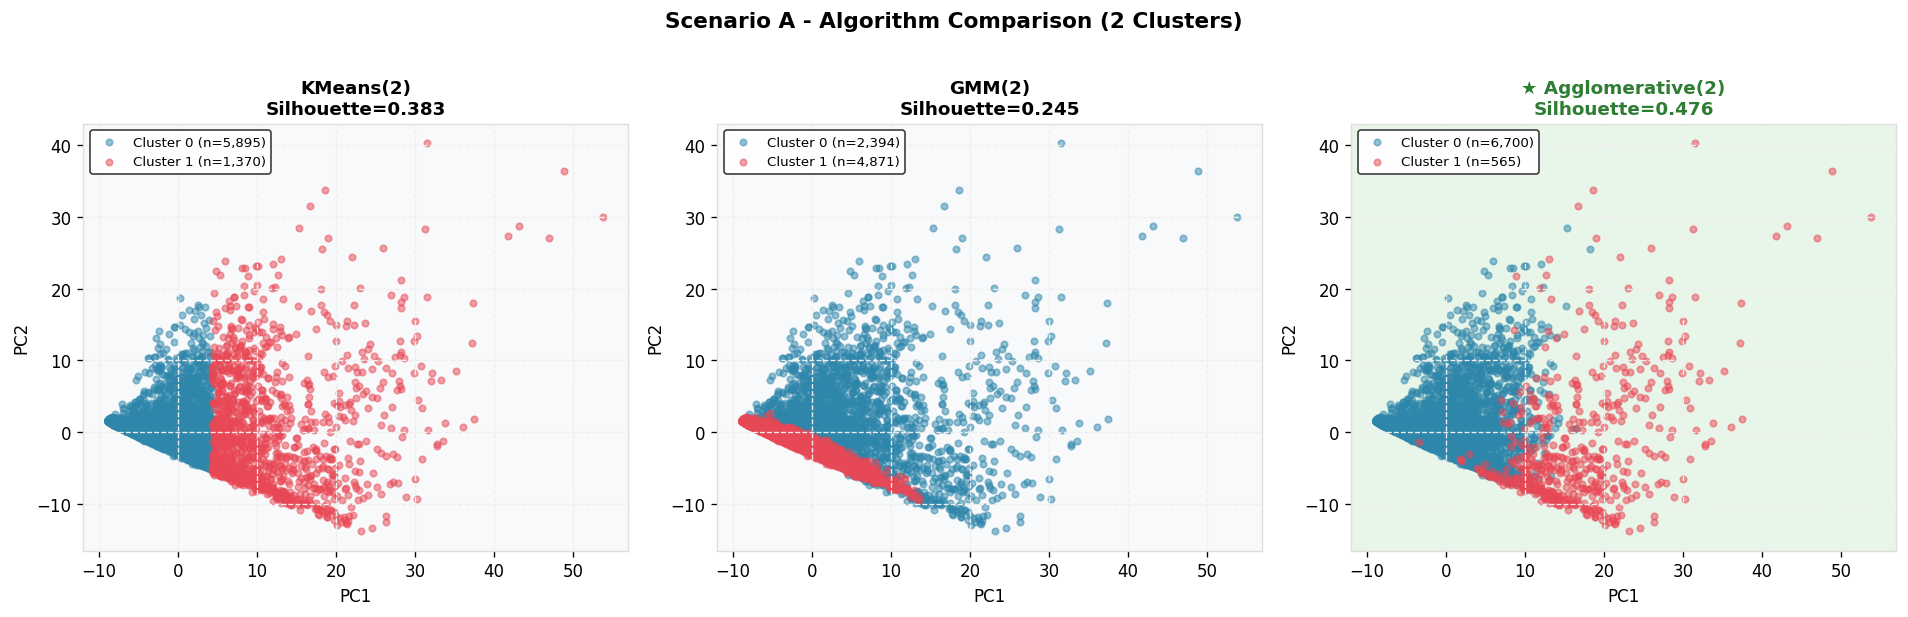

✅  fig_03_scenario_a_comparison.png saved


In [ ]:
# -- PCA 2D Visualization: Scenario A --
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_labels = {
    'KMeans(2)': results_2['KMeans(2)']['labels'],
    'GMM(2)': results_2['GMM(2)']['labels'],
    'Agglomerative(2)': results_2['Agglomerative(2)']['labels']
}

for ax, (name, lbl) in zip(axes, models_labels.items()):
    for cluster_id in np.unique(lbl):
        mask = lbl == cluster_id
        ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                   c=PALETTE[cluster_id], alpha=0.5, s=15,
                   label=f'Cluster {cluster_id} (n={mask.sum():,})')
    sil = results_2[name]['silhouette']
    ax.set_title(f'{name}\nSilhouette={sil:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    if name == best_model_2:
        ax.set_facecolor('#E8F5E9')
        ax.set_title(f'★ {name}\nSilhouette={sil:.3f}', fontsize=11, fontweight='bold', color='#2E7D32')

plt.suptitle('Scenario A - Algorithm Comparison (2 Clusters)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_03_scenario_a_comparison.png', bbox_inches='tight')
plt.show()
print('✅  fig_03_scenario_a_comparison.png saved')

---
## PARTE 5 — Escenario B: K Óptimo

Evaluamos K de 2 a 8 usando:
- **Elbow method** (Inercia de KMeans)
- **Silhouette Score**
- **Davies-Bouldin**
- **Gap Statistic** (implementación propia)

In [ ]:
# ============================================================
# PARTE 5 — ESCENARIO B: K ÓPTIMO
# ============================================================

K_RANGE = range(2, 9)
inertia, sil_scores, db_scores, ch_scores = [], [], [], []

print('Evaluando K = 2..8...')
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM, n_init=20, max_iter=500)
    lbl = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, lbl))
    db_scores.append(davies_bouldin_score(X_pca, lbl))
    ch_scores.append(calinski_harabasz_score(X_pca, lbl))
    print(f'  K={k}  Inertia={km.inertia_:,.0f}  Sil={sil_scores[-1]:.4f}  DB={db_scores[-1]:.4f}  CH={ch_scores[-1]:.1f}')

print('\n✅  Evaluación completa')

Evaluando K = 2..8...
  K=2  Inertia=726,344  Sil=0.3833  DB=1.5761  CH=2129.8
  K=3  Inertia=641,351  Sil=0.1592  DB=1.7713  CH=1687.0
  K=4  Inertia=567,900  Sil=0.1753  DB=1.5973  CH=1583.0
  K=5  Inertia=519,716  Sil=0.1859  DB=1.5603  CH=1465.4
  K=6  Inertia=480,711  Sil=0.1887  DB=1.5035  CH=1385.1
  K=7  Inertia=455,264  Sil=0.1547  DB=1.6098  CH=1286.2
  K=8  Inertia=440,741  Sil=0.1265  DB=1.7593  CH=1172.8

✅  Evaluación completa


In [ ]:
# ── Gap Statistic ─────────────────────────────────────────
def gap_statistic(X, k_range, n_refs=5, random_state=42):
    """Implementación del Gap Statistic de Tibshirani (2001)."""
    rng = np.random.RandomState(random_state)
    
    ref_dispersions = np.zeros((len(k_range), n_refs))
    obs_dispersions = []
    
    X_min, X_max = X.min(axis=0), X.max(axis=0)
    
    for i, k in enumerate(k_range):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        km.fit(X)
        obs_dispersions.append(np.log(km.inertia_))
        for j in range(n_refs):
            ref = rng.uniform(X_min, X_max, size=X.shape)
            km_ref = KMeans(n_clusters=k, random_state=random_state+j, n_init=10)
            km_ref.fit(ref)
            ref_dispersions[i, j] = np.log(km_ref.inertia_)
    
    gaps = ref_dispersions.mean(axis=1) - np.array(obs_dispersions)
    sds = ref_dispersions.std(axis=1) * np.sqrt(1 + 1/n_refs)
    return gaps, sds

print('Calculando Gap Statistic (puede tardar ~1 min)...')
gaps, gap_sds = gap_statistic(X_pca[:, :min(10, X_pca.shape[1])], K_RANGE, n_refs=5)

# K óptimo por Gap: primer K donde gap(k) >= gap(k+1) - sd(k+1)
k_gap_opt = list(K_RANGE)[0]
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i+1] - gap_sds[i+1]:
        k_gap_opt = list(K_RANGE)[i]
        break

print(f'\n📐  K óptimo por Gap Statistic: {k_gap_opt}')

Calculando Gap Statistic (puede tardar ~1 min)...

📐  K óptimo por Gap Statistic: 2


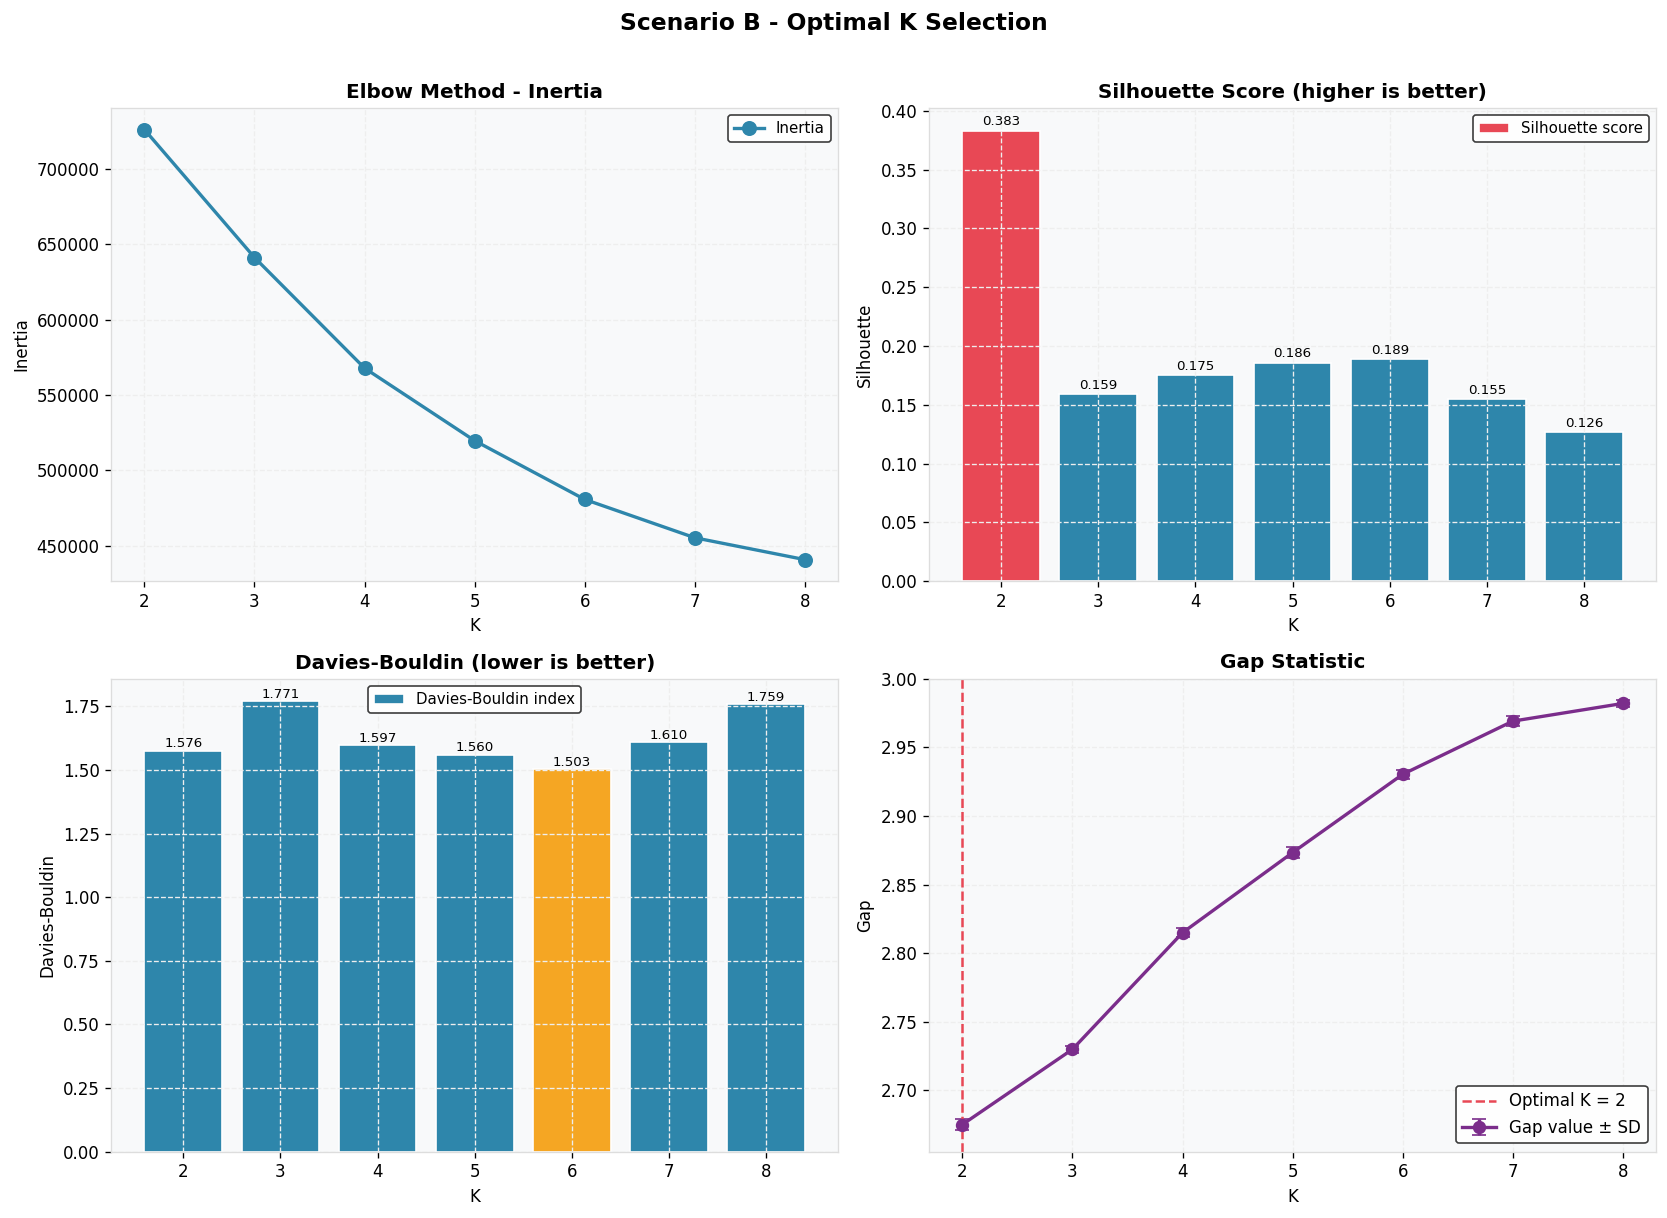

✅  fig_04_k_selection.png saved


In [ ]:
# -- Metrics dashboard for K selection --
ks = list(K_RANGE)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elbow
axes[0,0].plot(ks, inertia, 'o-', color='#2E86AB', linewidth=2, markersize=8,
               label='Inertia')
axes[0,0].set_title('Elbow Method - Inertia', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('Inertia')
axes[0,0].set_xticks(ks)
axes[0,0].legend(fontsize=9)

# Silhouette
colors_sil = [PALETTE[1] if s == max(sil_scores) else '#2E86AB' for s in sil_scores]
bars = axes[0,1].bar(ks, sil_scores, color=colors_sil, edgecolor='white', label='Silhouette score')
axes[0,1].set_title('Silhouette Score (higher is better)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('Silhouette')
axes[0,1].set_xticks(ks)
for bar, val in zip(bars, sil_scores):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=8)
axes[0,1].legend(fontsize=9)

# Davies-Bouldin
colors_db = [PALETTE[2] if s == min(db_scores) else '#2E86AB' for s in db_scores]
bars = axes[1,0].bar(ks, db_scores, color=colors_db, edgecolor='white', label='Davies-Bouldin index')
axes[1,0].set_title('Davies-Bouldin (lower is better)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('K'); axes[1,0].set_ylabel('Davies-Bouldin')
axes[1,0].set_xticks(ks)
for bar, val in zip(bars, db_scores):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=8)
axes[1,0].legend(fontsize=9)

# Gap Statistic
axes[1,1].errorbar(ks, gaps, yerr=gap_sds, fmt='o-', color='#7B2D8B',
                   linewidth=2, markersize=7, capsize=4, label='Gap value ± SD')
axes[1,1].axvline(k_gap_opt, color='#E84855', linestyle='--', label=f'Optimal K = {k_gap_opt}')
axes[1,1].set_title('Gap Statistic', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('K'); axes[1,1].set_ylabel('Gap')
axes[1,1].set_xticks(ks)
axes[1,1].legend()
style_legend(axes[1,1])

plt.suptitle('Scenario B - Optimal K Selection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_04_k_selection.png', bbox_inches='tight')
plt.show()
print('✅  fig_04_k_selection.png saved')

In [ ]:
# ── Decisión analítica sobre K óptimo ─────────────────────
# Votación ponderada: cada métrica vota por su K preferido
votes = {}
for k in ks:
    votes[k] = 0

votes[ks[sil_scores.index(max(sil_scores))]] += 3  # Silhouette: peso 3
votes[ks[db_scores.index(min(db_scores))]]   += 2  # Davies-Bouldin: peso 2
votes[ks[ch_scores.index(max(ch_scores))]]   += 1  # Calinski: peso 1
votes[k_gap_opt]                             += 2  # Gap: peso 2

K_OPTIMAL = max(votes, key=votes.get)

print('📊  Votación por K óptimo:')
for k, v in sorted(votes.items()):
    print(f'    K={k}: {v} votos {"★ ELEGIDO" if k==K_OPTIMAL else ""}')

print(f'\n✅  K ÓPTIMO FINAL: {K_OPTIMAL}')

# Entrenar modelo final Escenario B
km_opt = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM, n_init=20, max_iter=500)
LABELS_K = km_opt.fit_predict(X_pca)
print(f'\nDistribución de clusters:')
print(pd.Series(LABELS_K).value_counts().sort_index().to_string())

📊  Votación por K óptimo:
    K=2: 6 votos ★ ELEGIDO
    K=3: 0 votos 
    K=4: 0 votos 
    K=5: 0 votos 
    K=6: 2 votos 
    K=7: 0 votos 
    K=8: 0 votos 

✅  K ÓPTIMO FINAL: 2

Distribución de clusters:
0    5895
1    1370


---
## PARTE 5.5 — Hierarchical Clustering Analysis

> **Propósito:** Ir más allá del clustering plano (KMeans/GMM) para descubrir la **estructura jerárquica** latente entre los médicos del universo B/C. El análisis responde preguntas que KMeans no puede:

| Pregunta | Herramienta |
|----------|-------------|
| ¿Existe jerarquía natural? | Dendrograma |
| ¿SEG_C contiene subgrupos? | Dendrograma coloreado por segmento |
| ¿Los clusters se subdividen? | Clustermap + silhouette per-cluster |
| ¿Es estable la estructura? | Análisis de estabilidad cross-linkage |
| ¿Hierárquico vs KMeans? | Comparación de asignaciones |

**Hipótesis a testear:** *SEG_C no es un grupo homogéneo sino una colección de subgrupos con perfiles distintos que han sido agregados artificialmente bajo una sola etiqueta.*

In [ ]:
# ============================================================
# PARTE 5.5 — IMPORTS JERÁRQUICOS
# ============================================================
from scipy.cluster.hierarchy import (
    linkage, dendrogram, fcluster,
    inconsistent, cophenet, set_link_color_palette
)
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples
import itertools

# Consistent executive palette for this section
HC_PALETTE = ['#2E86AB','#E84855','#F5A623','#7B2D8B','#28A745','#17BECF','#FF7F0E','#9467BD']
set_link_color_palette(['#2E86AB','#E84855','#F5A623','#7B2D8B','#28A745'])

print('✅  Hierarchical clustering imports OK')

# ── Working dataset for this section ─────────────────────────
# Use PCA-reduced space (same as clustering parts above)
# Subsample if needed to keep dendrograms legible
N_HC = min(3000, len(X_pca))   # Cap at 3k for dendrogram performance
np.random.seed(RANDOM)
idx_hc = np.random.choice(len(X_pca), N_HC, replace=False)
X_hc = X_pca[idx_hc]

# Segment labels for coloring
seg_hc = df_bc['SEGMENT_FINAL'].values[idx_hc]
print(f'📊  Working subset: {N_HC:,} doctors')
print(f'    SEG_B: {(seg_hc=="SEG_B").sum():,}  |  SEG_C: {(seg_hc=="SEG_C").sum():,}  |  Other: {(~np.isin(seg_hc,["SEG_B","SEG_C"])).sum():,}')

✅  Hierarchical clustering imports OK
📊  Working subset: 3,000 doctors
    SEG_B: 1,846  |  SEG_C: 1,154  |  Other: 0


### 5.5.1 — Agglomerative Clustering Grid (Linkage × K)

Evaluamos las combinaciones de **linkage** (ward, complete, average) con K de 2 a 8, generando una tabla completa de métricas para identificar la mejor configuración jerárquica.

In [ ]:
# ============================================================
# 5.5.1 — AGGLOMERATIVE GRID
# ============================================================

LINKAGES   = ['ward', 'complete', 'average']
K_HC_RANGE = range(2, 9)

hc_rows = []
print('Evaluando combinaciones linkage × K...')

for linkage_name in LINKAGES:
    affinity = 'euclidean'  # ward only supports euclidean; others can use cosine
    for k in K_HC_RANGE:
        try:
            agg = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage_name,
                metric=affinity
            )
            lbl = agg.fit_predict(X_hc)
            sil = silhouette_score(X_hc, lbl)
            db  = davies_bouldin_score(X_hc, lbl)
            ch  = calinski_harabasz_score(X_hc, lbl)
            hc_rows.append({
                'Linkage': linkage_name, 'Distance': affinity, 'K': k,
                'Silhouette': round(sil, 4),
                'Davies-Bouldin': round(db, 4),
                'Calinski-Harabasz': round(ch, 1),
                '_labels': lbl
            })
            print(f'  {linkage_name:10s} | K={k} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f}')
        except Exception as e:
            print(f'  ⚠️  {linkage_name} K={k}: {e}')

hc_df = pd.DataFrame(hc_rows)
hc_metrics = hc_df.drop(columns='_labels')
hc_metrics.to_csv('hierarchical_metrics.csv', index=False)
print(f'\n💾  hierarchical_metrics.csv saved ({len(hc_metrics)} rows)')

# ── Best config per linkage ───────────────────────────────────
best_per_linkage = (
    hc_df.loc[hc_df.groupby('Linkage')['Silhouette'].idxmax()]
    [['Linkage','K','Silhouette','Davies-Bouldin','Calinski-Harabasz']]
)
print('\n🏆  Best K per linkage (max Silhouette):')
display(best_per_linkage.set_index('Linkage').style
        .background_gradient(subset=['Silhouette'], cmap='Greens')
        .background_gradient(subset=['Davies-Bouldin'], cmap='Reds_r')
        .format(precision=4)
        .set_caption('Best Hierarchical Configuration per Linkage'))

# Select overall best
best_row    = hc_df.loc[hc_df['Silhouette'].idxmax()]
HC_BEST_LNK = best_row['Linkage']
HC_BEST_K   = int(best_row['K'])
HC_LABELS   = best_row['_labels']
print(f'\n✅  Best overall: linkage={HC_BEST_LNK}, K={HC_BEST_K}, Silhouette={best_row["Silhouette"]:.4f}')

Evaluando combinaciones linkage × K...
  ward       | K=2 | Sil=0.3978 | DB=1.7595 | CH=677.6
  ward       | K=3 | Sil=0.3846 | DB=1.4719 | CH=587.3
  ward       | K=4 | Sil=0.1544 | DB=1.7717 | CH=575.6
  ward       | K=5 | Sil=0.1455 | DB=1.7241 | CH=523.8
  ward       | K=6 | Sil=0.1486 | DB=1.6417 | CH=472.6
  ward       | K=7 | Sil=0.1546 | DB=1.6557 | CH=441.9
  ward       | K=8 | Sil=0.0976 | DB=1.7474 | CH=422.3
  complete   | K=2 | Sil=0.7743 | DB=0.4983 | CH=87.0
  complete   | K=3 | Sil=0.5745 | DB=1.0576 | CH=132.9
  complete   | K=4 | Sil=0.5399 | DB=1.2087 | CH=243.1
  complete   | K=5 | Sil=0.3485 | DB=1.2915 | CH=218.2
  complete   | K=6 | Sil=0.3497 | DB=1.2072 | CH=184.0
  complete   | K=7 | Sil=0.3483 | DB=1.2931 | CH=159.6
  complete   | K=8 | Sil=0.3440 | DB=1.2703 | CH=144.5
  average    | K=2 | Sil=0.7230 | DB=0.7884 | CH=114.2
  average    | K=3 | Sil=0.6793 | DB=0.6925 | CH=65.0
  average    | K=4 | Sil=0.6732 | DB=0.8972 | CH=48.1
  average    | K=5 | Sil=0.64

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
Linkage,,,,
average,2,0.7230,0.7884,114.2000
complete,2,0.7743,0.4983,87.0000
ward,2,0.3978,1.7595,677.6000



✅  Best overall: linkage=complete, K=2, Silhouette=0.7743


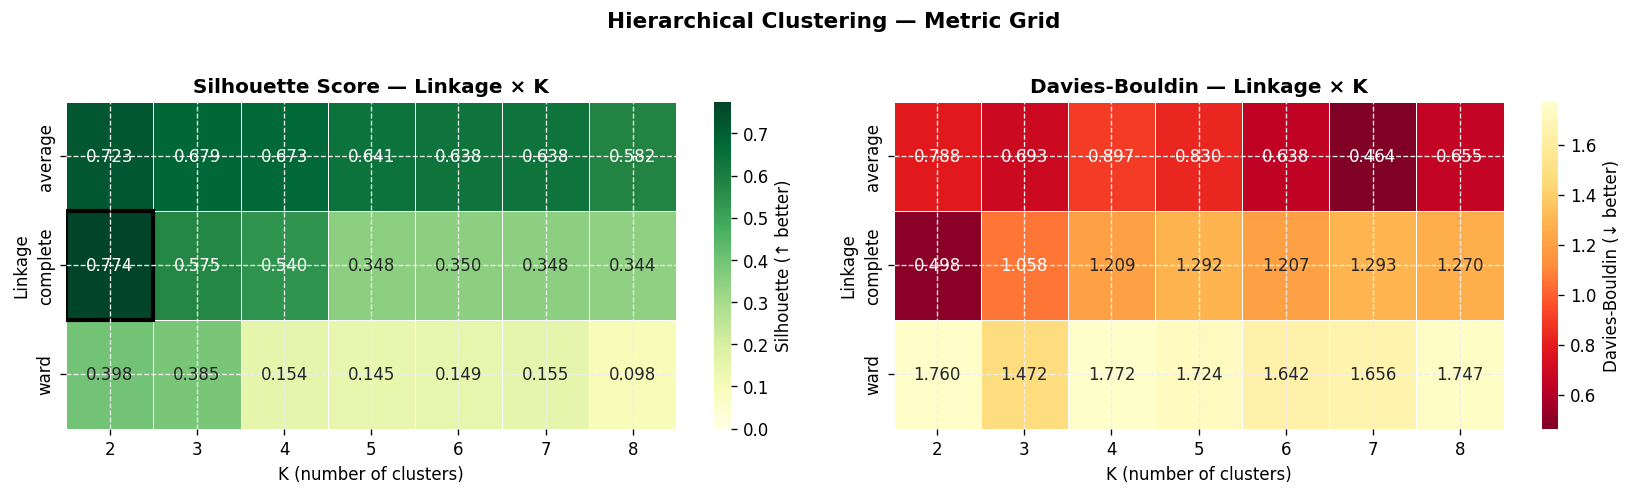

✅  fig_hc_metric_grid.png


In [ ]:
# ── Heatmap grid: Silhouette × (Linkage, K) ──────────────────
pivot_sil = hc_metrics.pivot(index='Linkage', columns='K', values='Silhouette')
pivot_db  = hc_metrics.pivot(index='Linkage', columns='K', values='Davies-Bouldin')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(pivot_sil, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0],
            linewidths=0.5, vmin=0, vmax=pivot_sil.max().max(),
            cbar_kws={'label':'Silhouette (↑ better)'})
axes[0].set_title('Silhouette Score — Linkage × K', fontsize=12, fontweight='bold')
axes[0].set_xlabel('K (number of clusters)')

sns.heatmap(pivot_db, annot=True, fmt='.3f', cmap='YlOrRd_r', ax=axes[1],
            linewidths=0.5, cbar_kws={'label':'Davies-Bouldin (↓ better)'})
axes[1].set_title('Davies-Bouldin — Linkage × K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('K (number of clusters)')

# Highlight best cell
best_col_idx = list(pivot_sil.columns).index(HC_BEST_K)
best_row_idx = list(pivot_sil.index).index(HC_BEST_LNK)
axes[0].add_patch(plt.Rectangle((best_col_idx, best_row_idx), 1, 1,
                                 fill=False, edgecolor='black', lw=2.5))

plt.suptitle('Hierarchical Clustering — Metric Grid', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_hc_metric_grid.png', bbox_inches='tight')
plt.show()
print('✅  fig_hc_metric_grid.png')

### 5.5.2 — Dendrograma Principal

El dendrograma revela la **estructura de fusiones** jerárquicas: qué tan pronto se unen dos grupos indica su similitud. Ramas largas = clusters bien separados. Ramas cortas = grupos similares o continuos.

Computing Ward linkage on 800 samples...
Cophenetic correlation: 0.4917  (>0.7 = good representation)


NameError: name 'HC_BEST_K' is not defined

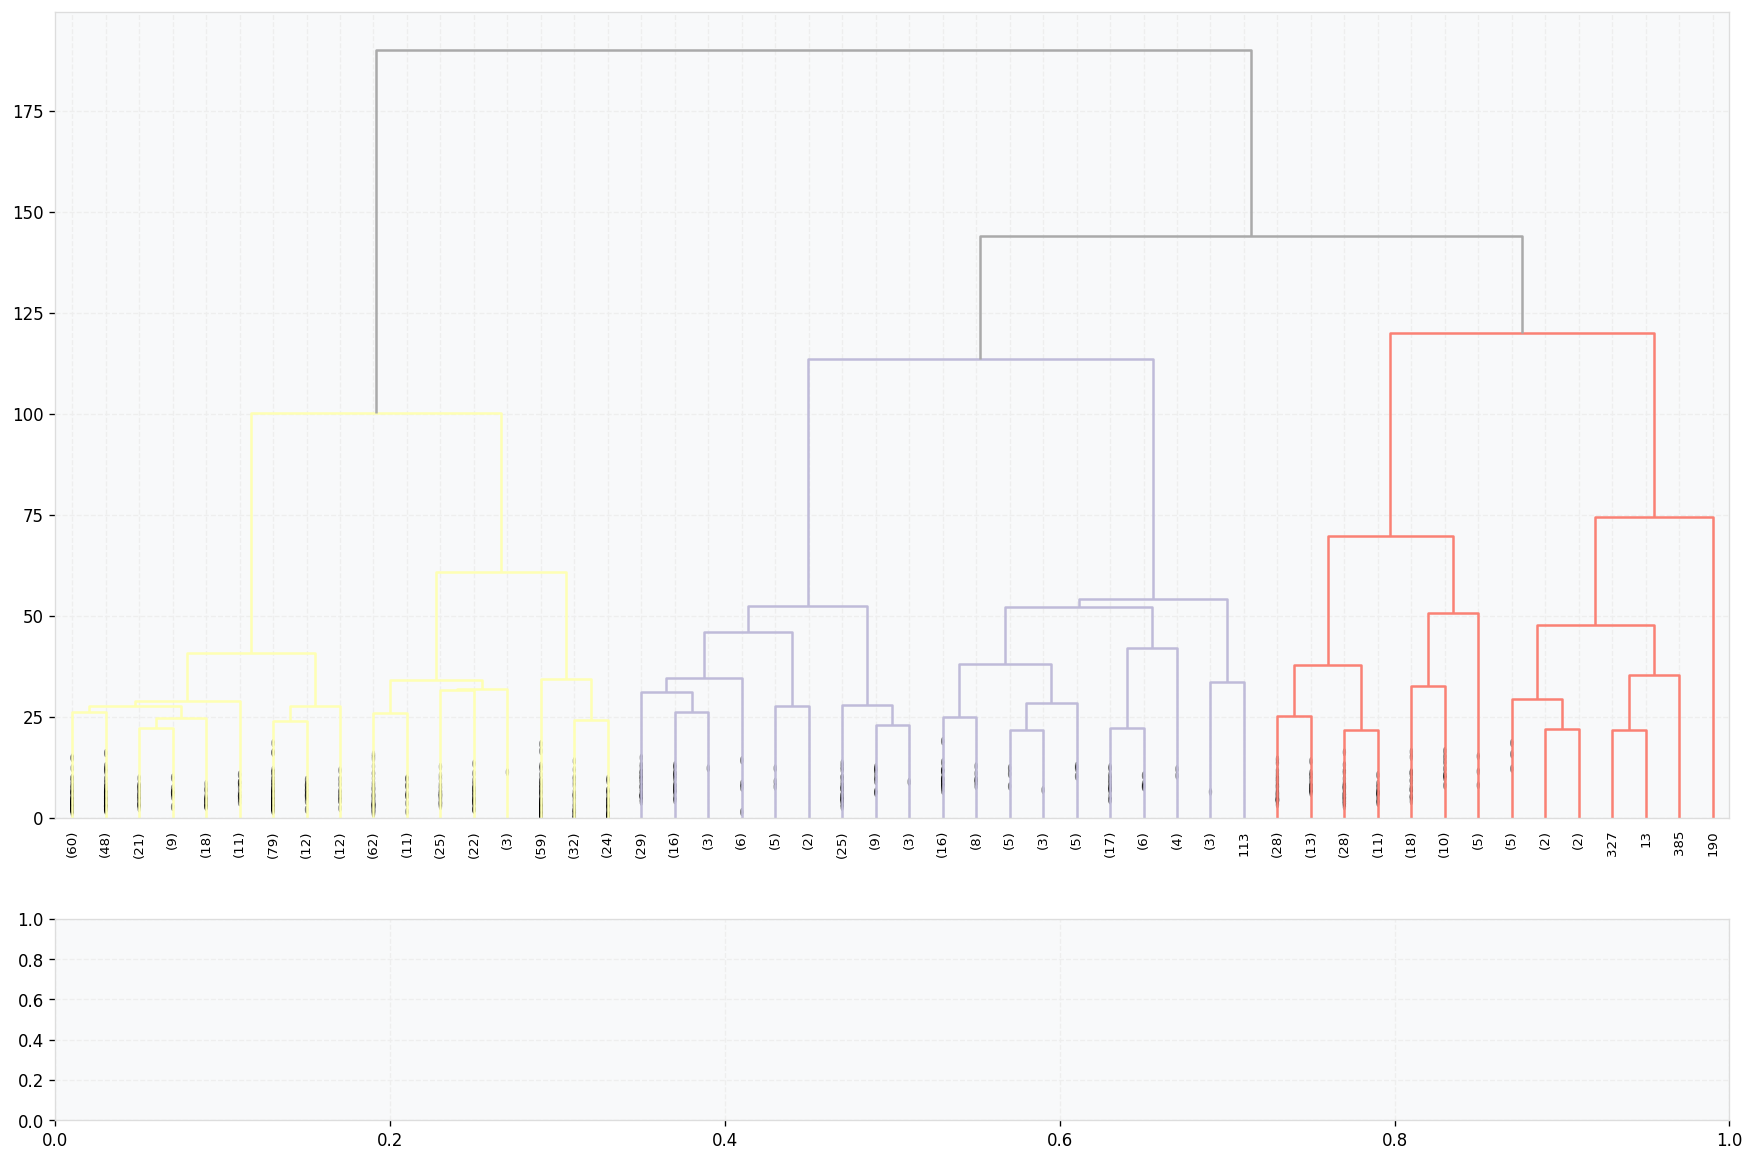

In [19]:
# ============================================================
# 5.5.2 — MAIN DENDROGRAM (fig_27)
# ============================================================

# Defensive: ensure HC sample indices/arrays exist
if 'X_hc' not in globals():
    N_HC = min(3000, len(X_pca))
    idx_hc = np.random.RandomState(42).choice(len(X_pca), N_HC, replace=False)
    X_hc = X_pca[idx_hc]
    if 'df_bc' in globals() and 'SEGMENT_FINAL' in df_bc.columns:
        seg_hc = df_bc['SEGMENT_FINAL'].values[idx_hc]
    elif 'df' in globals() and 'SEGMENT_FINAL' in df.columns:
        seg_hc = df['SEGMENT_FINAL'].values[idx_hc]
    else:
        seg_hc = np.array(['Unlabeled'] * len(idx_hc))
    print(f'Initialized HC sample: N_HC={len(X_hc)}')

# Required imports for hierarchical linkage
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

# Compute linkage matrix (Ward on PCA features)
# Use a manageable sample for the dendrogram itself
N_DEND = min(800, len(X_hc))   # Dendrogram is unreadable beyond ~1000 leaves
idx_dend = np.random.RandomState(42).choice(len(X_hc), N_DEND, replace=False)
X_dend   = X_hc[idx_dend]
seg_dend = seg_hc[idx_dend]

print(f'Computing Ward linkage on {N_DEND} samples...')
Z_ward = linkage(X_dend, method='ward', metric='euclidean')

# Cophenetic correlation (quality of the hierarchical representation)
c_corr, _ = cophenet(Z_ward, pdist(X_dend))
print(f'Cophenetic correlation: {c_corr:.4f}  (>0.7 = good representation)')

# ── Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 12),
                          gridspec_kw={'height_ratios': [4, 1]})
fig.patch.set_facecolor('white')

# Truncated dendrogram (p=50 shows last 50 merges)
color_thresh = 0.7 * max(Z_ward[:, 2])  # auto-color threshold at 70% of max distance
dn = dendrogram(
    Z_ward,
    ax=axes[0],
    truncate_mode='lastp',
    p=50,
    color_threshold=color_thresh,
    above_threshold_color='#AAAAAA',
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    count_sort='descending',
)

# Annotate K-cut lines
for k_cut, ls, col, lbl in [
    (2, '--', '#E84855', 'K=2'),
    (3, ':',  '#F5A623', 'K=3'),
    (HC_BEST_K, '-', '#2E86AB', f'K={HC_BEST_K} (optimal)'),
]:
    if k_cut <= len(Z_ward):
        # Height at which cutting gives K clusters
        distances = sorted(Z_ward[:, 2], reverse=True)
        if k_cut - 1 < len(distances):
            cut_h = (distances[k_cut-2] + distances[k_cut-1]) / 2 if k_cut > 1 else distances[0]
            axes[0].axhline(cut_h, color=col, linestyle=ls, linewidth=1.5,
                            alpha=0.8, label=f'{lbl} cut (h={cut_h:.1f})')

axes[0].set_title(
    f'Hierarchical Clustering Dendrogram — Ward Linkage\n'
    f'(Last 50 merges | n={N_DEND:,} doctors | Cophenetic r={c_corr:.3f})',
    fontsize=13, fontweight='bold', pad=10,
)
axes[0].set_ylabel('Merge Distance (Ward)', fontsize=11)
axes[0].set_xlabel('')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_facecolor('#FAFAFA')

# Bottom panel: distance gap (elbow in merge distances)
merge_dists = sorted(Z_ward[:, 2], reverse=True)[:20]
gaps = [merge_dists[i] - merge_dists[i+1] for i in range(len(merge_dists)-1)]
axes[1].bar(range(1, len(gaps)+1), gaps, color='#2E86AB', edgecolor='white')
axes[1].set_xlabel('Merge Step (from last, 1 = last merge)', fontsize=10)
axes[1].set_ylabel('Gap (Δ distance)', fontsize=10)
axes[1].set_title('Merge Distance Gaps — Elbow Detection', fontsize=11, fontweight='bold')
# Annotate the largest gap
max_gap_idx = np.argmax(gaps) + 1
axes[1].annotate(f'Largest gap\nat K={max_gap_idx+1}',
                 xy=(max_gap_idx, gaps[max_gap_idx-1]),
                 xytext=(max_gap_idx+1.5, gaps[max_gap_idx-1]*0.9),
                 arrowprops=dict(arrowstyle='->', color='#E84855'),
                 fontsize=9, color='#E84855')

plt.suptitle('', fontsize=1)  # clean
plt.tight_layout()
plt.savefig('fig_27_dendrogram_main.png', bbox_inches='tight', facecolor='white')
plt.show()
print('✅  fig_27_dendrogram_main.png')
print(f'\n📊  Gap analysis suggests K={max_gap_idx+1} is a natural cut point')

### 5.5.3 — Dendrograma Coloreado por Segmento Histórico

Coloreamos las hojas del dendrograma según la etiqueta histórica (SEG_B / SEG_C). Si las ramas son **puras** (una rama = un segmento), la segmentación histórica tiene soporte jerárquico. Si las ramas mezclan B y C, la frontera histórica no corresponde a la estructura real de los datos.

In [16]:
# ============================================================
# 5.5.3 — DENDROGRAM COLORED BY HISTORICAL SEGMENT (fig_28)
# ============================================================

from matplotlib.patches import Patch
from scipy.cluster.hierarchy import leaves_list

# Color mapping for leaves
SEG_COLOR_MAP = {'SEG_B': '#2E86AB', 'SEG_C': '#E84855'}
leaf_colors = np.array([
    SEG_COLOR_MAP.get(s, '#AAAAAA') for s in seg_dend
])

fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('white')

# Draw the dendrogram without coloring
dn2 = dendrogram(
    Z_ward,
    ax=ax,
    truncate_mode='lastp',
    p=60,
    color_threshold=0,       # Single color for all branches
    above_threshold_color='#BBBBBB',
    leaf_rotation=90,
    leaf_font_size=7,
    show_contracted=True,
    no_labels=True
)

# ── Re-color x-tick labels by segment composition ────────────
# For contracted nodes, compute dominant segment
leaf_order = dn2['leaves']  # Index order in the dendrogram

# Rebuild leaf colors in dendrogram order
xcoords = []
for idx in dn2['leaves']:
    # Each idx may be a single leaf or a cluster in truncated mode
    xcoords.append(leaf_colors[idx] if idx < len(leaf_colors) else '#AAAAAA')

# Plot colored leaf markers at the base
leaf_x = sorted([coord for icoord in dn2['icoord'] for coord in icoord
                  if coord > 0])
# Simpler: color bottom x-axis ticks
xtick_positions = []
for xs in dn2['icoord']:
    for x in xs:
        if x not in xtick_positions:
            xtick_positions.append(x)

# Mark segment purity on the coloured segment lines at the base
n_leaves_total = len(dn2['leaves'])
leaf_x_positions = np.linspace(5, 5 * (n_leaves_total), n_leaves_total)

for xi, idx in zip(leaf_x_positions, dn2['leaves']):
    col = leaf_colors[idx] if idx < len(leaf_colors) else '#BBBBBB'
    ax.plot(xi, 0, 's', color=col, markersize=4, alpha=0.7, clip_on=False)

# ── Horizontal cut lines ──────────────────────────────────────
distances_sorted = sorted(Z_ward[:, 2], reverse=True)
for k_cut, col_line, lbl in [(2, '#E84855','K=2'), (3, '#F5A623','K=3')]:
    if k_cut - 2 < len(distances_sorted):
        cut_h = (distances_sorted[k_cut-2] + distances_sorted[k_cut-1]) / 2
        ax.axhline(cut_h, color=col_line, linestyle='--', linewidth=2,
                   alpha=0.7, label=f'{lbl} cut')

legend_elements = [
    Patch(facecolor='#2E86AB', label='SEG_B leaf'),
    Patch(facecolor='#E84855', label='SEG_C leaf'),
    Patch(facecolor='#AAAAAA', label='Unlabeled leaf'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

ax.set_title(
    'Dendrogram — Leaf Colors = Historical Segment\n'
    'Homogeneous branches (pure color) = Segment has hierarchical support',
    fontsize=12, fontweight='bold', pad=10
)
ax.set_ylabel('Merge Distance', fontsize=11)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('fig_28_dendrogram_segments.png', bbox_inches='tight', facecolor='white')
plt.show()
print('✅  fig_28_dendrogram_segments.png')

# ── Purity analysis per branch ────────────────────────────────
print('\n📊  Segment purity at K=2 cut:')
agg2_hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
lbl2_hc = agg2_hc.fit_predict(X_hc)
labeled_hc = np.isin(seg_hc, ['SEG_B','SEG_C'])
if labeled_hc.sum() > 0:
    for ci in [0, 1]:
        mask = (lbl2_hc == ci) & labeled_hc
        if mask.sum() > 0:
            n_b = (seg_hc[mask]=='SEG_B').sum()
            n_c = (seg_hc[mask]=='SEG_C').sum()
            total = n_b + n_c
            purity = max(n_b, n_c)/total*100 if total>0 else 0
            dom = 'SEG_B' if n_b>=n_c else 'SEG_C'
            print(f'  Cluster {ci}: SEG_B={n_b} ({n_b/total:.0%})  SEG_C={n_c} ({n_c/total:.0%})  → Dominant: {dom}  Purity: {purity:.1f}%')
else:
    print('  ⚠️  No labeled records in sample — purity analysis skipped')

NameError: name 'seg_dend' is not defined

### 5.5.4 — Cluster Map / Hierarchical Heatmap

El **clustermap** de seaborn aplica clustering jerárquico simultáneamente a filas (doctores) y columnas (variables), revelando bloques de patrones compartidos. Si SEG_C es heterogéneo, veremos múltiples bloques dentro de sus filas.

Building clustermap: 500 doctors × 20 features...


c:\Users\cocoi\Documents\TEC\AA Semestres\8vo\Pfizer\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\cocoi\Documents\TEC\AA Semestres\8vo\Pfizer\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


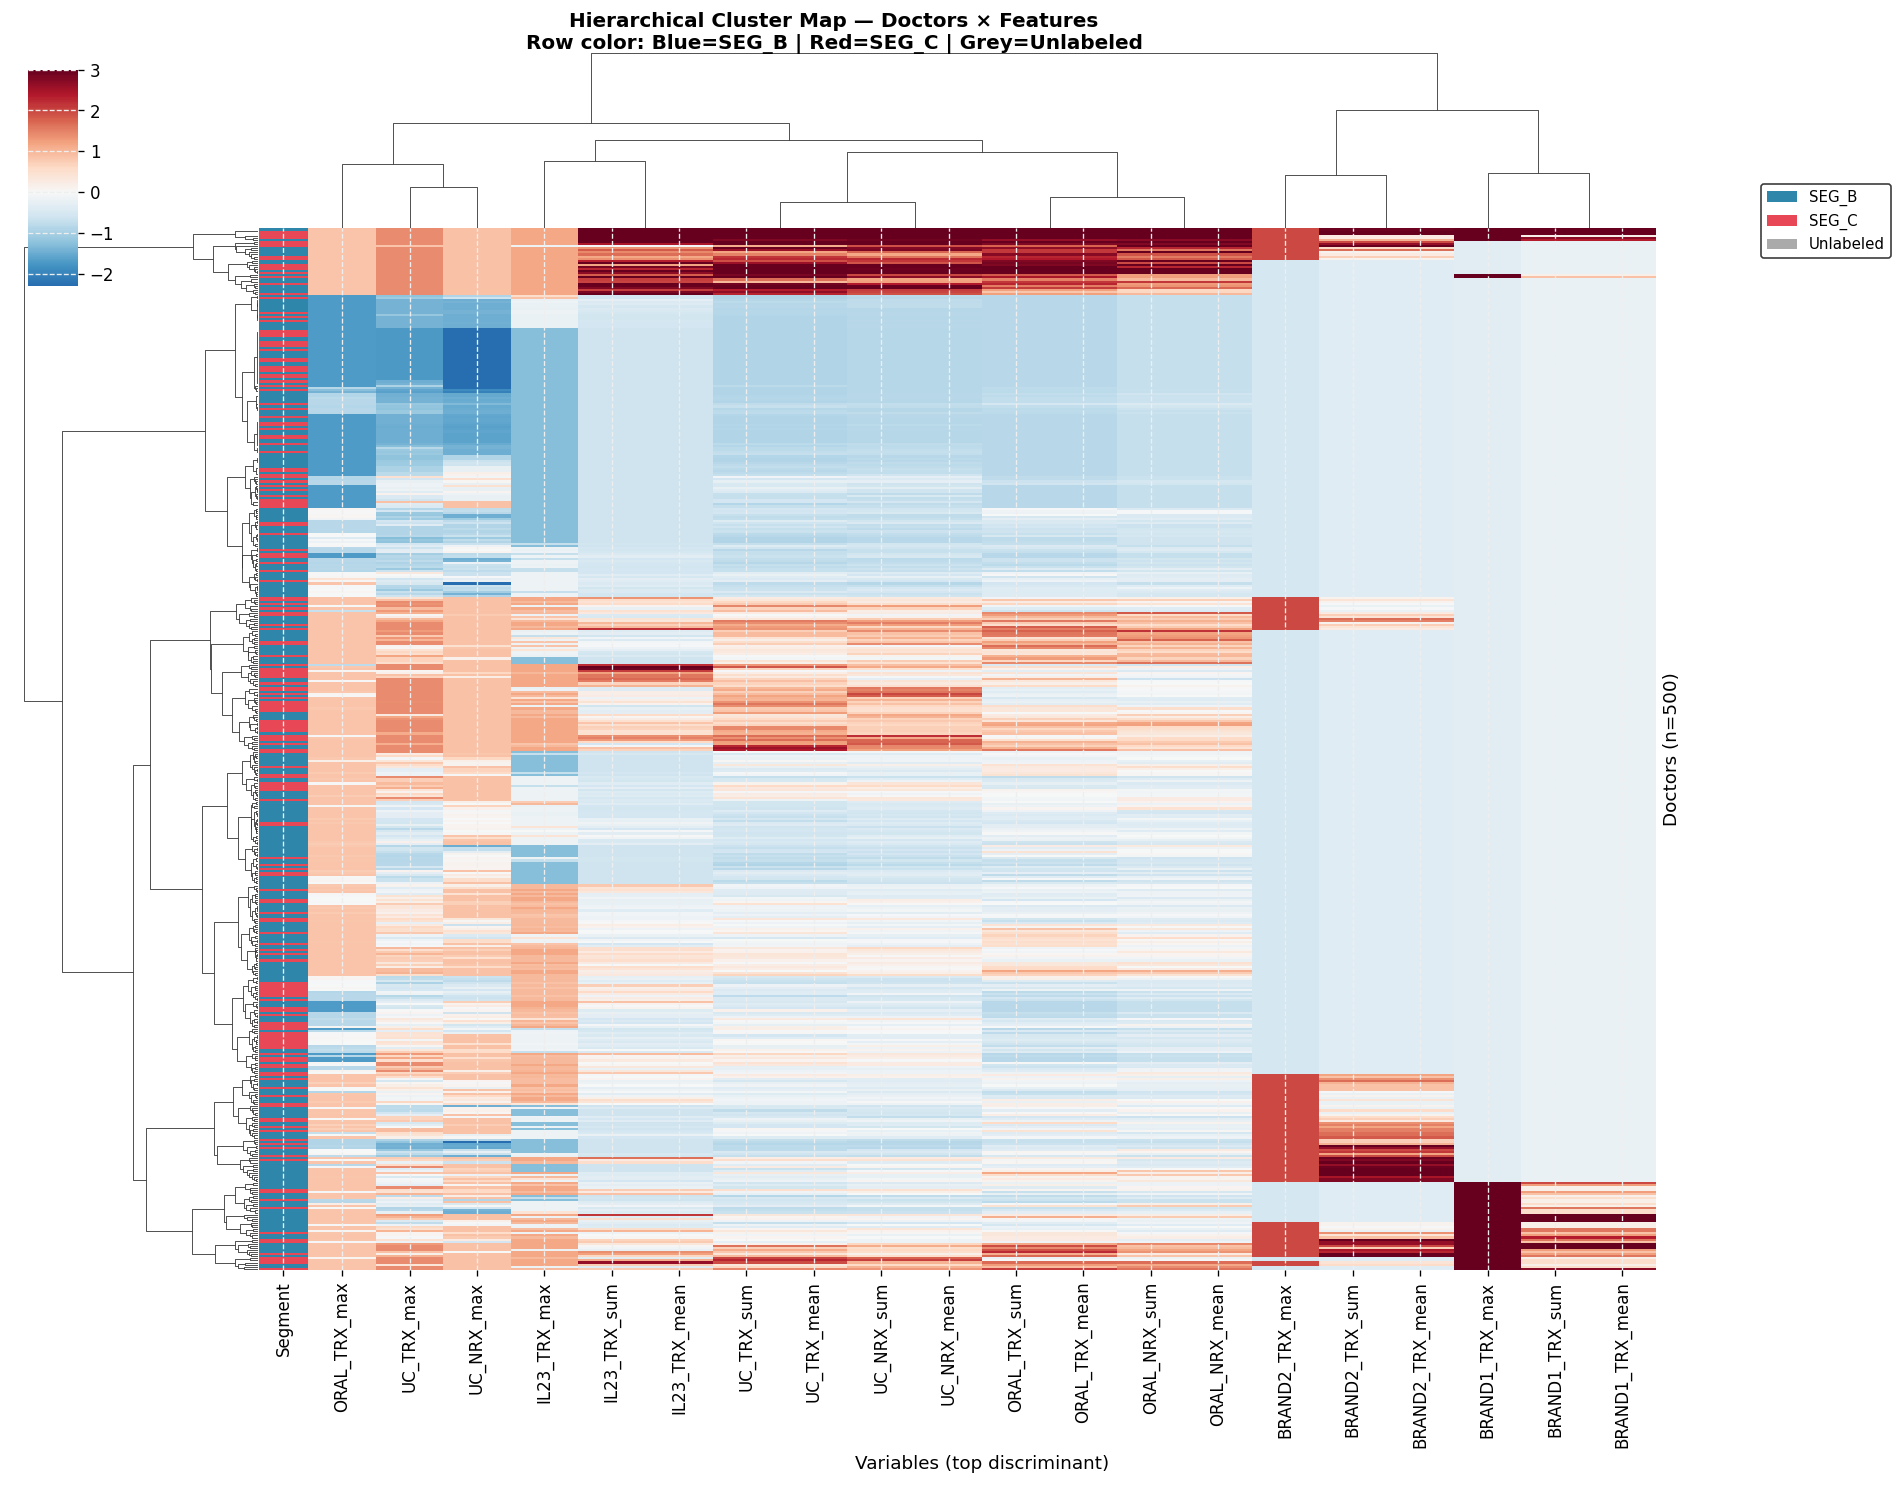

✅  fig_29_clustermap.png


In [20]:
# ============================================================
# 5.5.4 — CLUSTERMAP (fig_29)
# ============================================================

# Use top discriminant variables from the interpretability section
TOP_CLMAP_VARS = TOP_VARS_A[:20] if 'TOP_VARS_A' in dir() else (
    pd.Series(rf_best.feature_importances_ if 'rf_best' in dir() else [],
              index=sup_feature_names if 'sup_feature_names' in dir() else [])
    .sort_values(ascending=False).head(20).index.tolist()
    if 'sup_feature_names' in dir() else all_feature_names[:20]
)

# Sample for performance
N_CLMAP = min(500, len(X_hc))
idx_cm  = np.random.RandomState(42).choice(len(X_hc), N_CLMAP, replace=False)

# Build DataFrame with available features
X_orig_hc = pd.DataFrame(
    X_imputed.values[idx_hc[idx_cm]] if len(X_imputed) > max(idx_hc[idx_cm]) else X_imputed.values[:N_CLMAP],
    columns=all_feature_names
)

# Filter to top vars that exist
avail_vars = [v for v in TOP_CLMAP_VARS if v in X_orig_hc.columns]
X_cm = X_orig_hc[avail_vars[:min(20, len(avail_vars))]].copy()

# Z-score normalize columns
X_cm_z = (X_cm - X_cm.mean()) / (X_cm.std() + 1e-9)
X_cm_z = X_cm_z.clip(-3, 3)  # Cap for visual clarity

# Row colors by historical segment
seg_cm = seg_hc[idx_cm]
row_colors = pd.Series([
    '#2E86AB' if s=='SEG_B' else ('#E84855' if s=='SEG_C' else '#AAAAAA')
    for s in seg_cm
], name='Segment')

print(f'Building clustermap: {N_CLMAP} doctors × {len(X_cm_z.columns)} features...')

g = sns.clustermap(
    X_cm_z,
    method='ward',
    metric='euclidean',
    cmap='RdBu_r',
    center=0,
    row_colors=row_colors,
    figsize=(14, 12),
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.02, 0.82, 0.03, 0.15),
    linewidths=0,
    xticklabels=True,
    yticklabels=False,
)

g.ax_heatmap.set_xlabel('Variables (top discriminant)', fontsize=11)
g.ax_heatmap.set_ylabel(f'Doctors (n={N_CLMAP})', fontsize=11)
g.fig.suptitle(
    'Hierarchical Cluster Map — Doctors × Features\n'
    'Row color: Blue=SEG_B | Red=SEG_C | Grey=Unlabeled',
    fontsize=12, fontweight='bold', y=1.01
)

# Manual legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label='SEG_B'),
    Patch(facecolor='#E84855', label='SEG_C'),
    Patch(facecolor='#AAAAAA', label='Unlabeled')
]
g.ax_heatmap.legend(handles=legend_elements, loc='upper right',
                    bbox_to_anchor=(1.18, 1.05), fontsize=9)

plt.savefig('fig_29_clustermap.png', bbox_inches='tight', facecolor='white', dpi=120)
plt.show()
print('✅  fig_29_clustermap.png')

### 5.5.5 — Hierarchical Cluster Summary Table

In [23]:
# ============================================================
# 5.5.5 — HIERARCHICAL CLUSTER SUMMARY
# ============================================================

# Use the best config identified above
agg_best = AgglomerativeClustering(n_clusters=HC_BEST_K, linkage=HC_BEST_LNK)
HC_LABELS_FULL = agg_best.fit_predict(X_hc)

labeled_mask_hc = np.isin(seg_hc, ['SEG_B','SEG_C'])

summary_rows = []
X_orig_hc_full = pd.DataFrame(
    X_imputed.values[idx_hc] if len(X_imputed) >= len(idx_hc) else X_imputed.values[:len(idx_hc)],
    columns=all_feature_names
)

sil_samples = silhouette_samples(X_hc, HC_LABELS_FULL)

for ci in sorted(np.unique(HC_LABELS_FULL)):
    mask   = HC_LABELS_FULL == ci
    n_tot  = mask.sum()
    lab_m  = mask & labeled_mask_hc
    n_b = (seg_hc[lab_m]=='SEG_B').sum() if lab_m.sum()>0 else 0
    n_c = (seg_hc[lab_m]=='SEG_C').sum() if lab_m.sum()>0 else 0
    n_lab  = n_b + n_c
    pct_b  = n_b/n_lab*100 if n_lab>0 else np.nan
    pct_c  = n_c/n_lab*100 if n_lab>0 else np.nan
    dom    = 'SEG_B' if n_b>=n_c else 'SEG_C' if n_lab>0 else 'Unknown'
    purity = max(pct_b or 0, pct_c or 0)
    avg_sil= sil_samples[mask].mean()

    # Auto-interpretation
    if n_lab == 0:
        interp = 'Unlabeled cluster'
    elif purity >= 80:
        interp = f'Strong {dom}'
    elif purity >= 65:
        interp = f'Leaning {dom}'
    elif avg_sil > 0.3:
        interp = 'High-intensity subgroup'
    elif n_tot < len(X_hc) * 0.05:
        interp = 'Potential hybrid subgroup'
    else:
        interp = 'Mixed'

    summary_rows.append({
        'Cluster': f'HC_{ci}',
        'Size': n_tot,
        'Size %': f'{n_tot/len(X_hc):.1%}',
        'SEG_B Count': n_b, 'SEG_C Count': n_c,
        'SEG_B %': round(pct_b, 1) if not np.isnan(pct_b or np.nan) else '—',
        'SEG_C %': round(pct_c, 1) if not np.isnan(pct_c or np.nan) else '—',
        'Dominant': dom,
        'Purity %': round(purity, 1),
        'Avg Silhouette': round(avg_sil, 4),
        'Interpretation': interp
    })

hc_summary = pd.DataFrame(summary_rows).set_index('Cluster')
hc_summary.to_csv('hierarchical_cluster_summary.csv')
print(f'💾  hierarchical_cluster_summary.csv saved')
display(hc_summary.style
        .background_gradient(subset=['Avg Silhouette'], cmap='Greens')
        .background_gradient(subset=['Purity %'], cmap='Blues')
        .set_caption(f'Hierarchical Cluster Summary — {HC_BEST_LNK} linkage, K={HC_BEST_K}'))

NameError: name 'silhouette_samples' is not defined

### 5.5.6 — Proyección 2D con Etiquetas Jerárquicas

Comparamos la asignación jerárquica vs KMeans en el mismo espacio 2D, permitiendo ver si ambos métodos descubren la misma estructura.

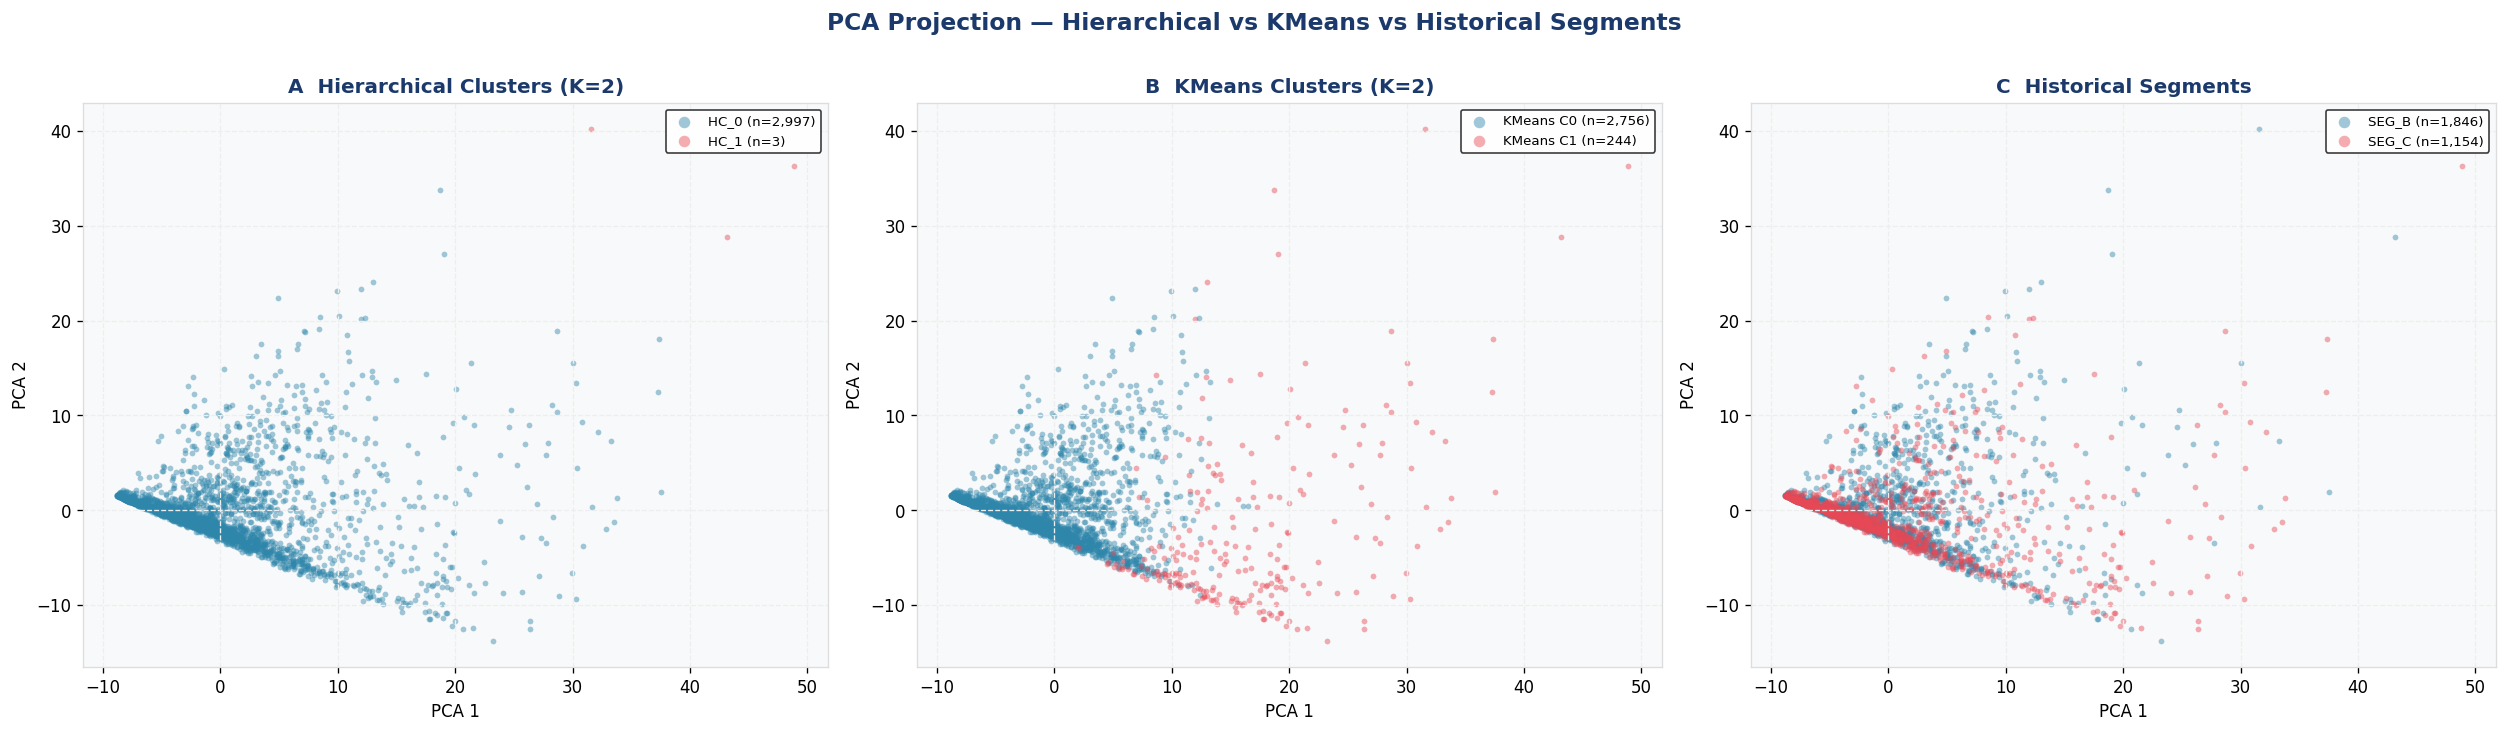

✅  fig_30_hierarchical_projection.png


In [ ]:
# ============================================================
# 5.5.6 — HIERARCHICAL PROJECTION (fig_30)
# ============================================================

# Use best available 2D embedding (same logic as Part 6)
try:
    emb_hc = X_umap[np.isin(np.arange(len(X_pca)), idx_hc)[:len(idx_hc)]]
    if len(emb_hc) != len(X_hc):
        raise ValueError('Shape mismatch')
    EMBED_NAME = 'UMAP'
except:
    try:
        # Reuse tsne sample if overlaps
        emb_hc = X_tsne[:len(X_hc)] if len(X_tsne) >= len(X_hc) else X_pca2[idx_hc]
        EMBED_NAME = 't-SNE' if len(X_tsne) >= len(X_hc) else 'PCA'
    except:
        emb_hc = X_pca2[idx_hc]
        EMBED_NAME = 'PCA'

n_pts_hc = min(len(emb_hc), len(HC_LABELS_FULL), len(LABELS_2[idx_hc]))
emb_hc = emb_hc[:n_pts_hc]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor('white')
SK = dict(alpha=0.45, s=12, linewidths=0, rasterized=True)

# Panel A: Hierarchical clusters
for ci in sorted(np.unique(HC_LABELS_FULL[:n_pts_hc])):
    mask = HC_LABELS_FULL[:n_pts_hc] == ci
    axes[0].scatter(emb_hc[mask,0], emb_hc[mask,1],
                    c=HC_PALETTE[ci % len(HC_PALETTE)],
                    label=f'HC_{ci} (n={mask.sum():,})', **SK)
axes[0].set_title(f'A  Hierarchical Clusters (K={HC_BEST_K})',
                  fontsize=12, fontweight='bold', color='#1B3A6B')
axes[0].set_xlabel(f'{EMBED_NAME} 1'); axes[0].set_ylabel(f'{EMBED_NAME} 2')
axes[0].legend(fontsize=8, markerscale=2)

# Panel B: KMeans clusters (same sample)
km_hc = LABELS_2[idx_hc[:n_pts_hc]]
for ci in sorted(np.unique(km_hc)):
    mask = km_hc == ci
    axes[1].scatter(emb_hc[mask,0], emb_hc[mask,1],
                    c=HC_PALETTE[ci % len(HC_PALETTE)],
                    label=f'KMeans C{ci} (n={mask.sum():,})', **SK)
axes[1].set_title('B  KMeans Clusters (K=2)',
                  fontsize=12, fontweight='bold', color='#1B3A6B')
axes[1].set_xlabel(f'{EMBED_NAME} 1'); axes[1].set_ylabel(f'{EMBED_NAME} 2')
axes[1].legend(fontsize=8, markerscale=2)

# Panel C: Historical segments
seg_map = {'SEG_B': '#2E86AB', 'SEG_C': '#E84855'}
for seg, col in seg_map.items():
    mask = seg_hc[:n_pts_hc] == seg
    if mask.sum() > 0:
        axes[2].scatter(emb_hc[mask,0], emb_hc[mask,1],
                        c=col, label=f'{seg} (n={mask.sum():,})', **SK)
unk = ~np.isin(seg_hc[:n_pts_hc], list(seg_map.keys()))
if unk.sum():
    axes[2].scatter(emb_hc[unk,0], emb_hc[unk,1],
                    c='#CCCCCC', label=f'Unlabeled ({unk.sum():,})',
                    alpha=0.2, s=8, linewidths=0)
axes[2].set_title('C  Historical Segments',
                  fontsize=12, fontweight='bold', color='#1B3A6B')
axes[2].set_xlabel(f'{EMBED_NAME} 1'); axes[2].set_ylabel(f'{EMBED_NAME} 2')
axes[2].legend(fontsize=8, markerscale=2)

plt.suptitle(
    f'{EMBED_NAME} Projection — Hierarchical vs KMeans vs Historical Segments',
    fontsize=14, fontweight='bold', color='#1B3A6B', y=1.01
)
plt.tight_layout()
plt.savefig('fig_30_hierarchical_projection.png', bbox_inches='tight', facecolor='white')
plt.show()
print('✅  fig_30_hierarchical_projection.png')

### 5.5.7 — Análisis de Estabilidad Cross-Linkage

Un cluster **estable** aparece consistentemente independientemente del método de linkage. Clusters frágiles cambian de forma dramática entre ward / complete / average. Esto revela qué grupos son estructuralmente reales vs artefactos del algoritmo.

💾  hierarchical_stability.csv saved


,Size,Avg Silhouette,Std Silhouette,Stability Score,Interpretation
Cluster,,,,,
HC_0,470,-0.046800,0.146800,0.989400,Stable
HC_1,2530,0.480400,0.105500,1.000000,Highly stable & coherent


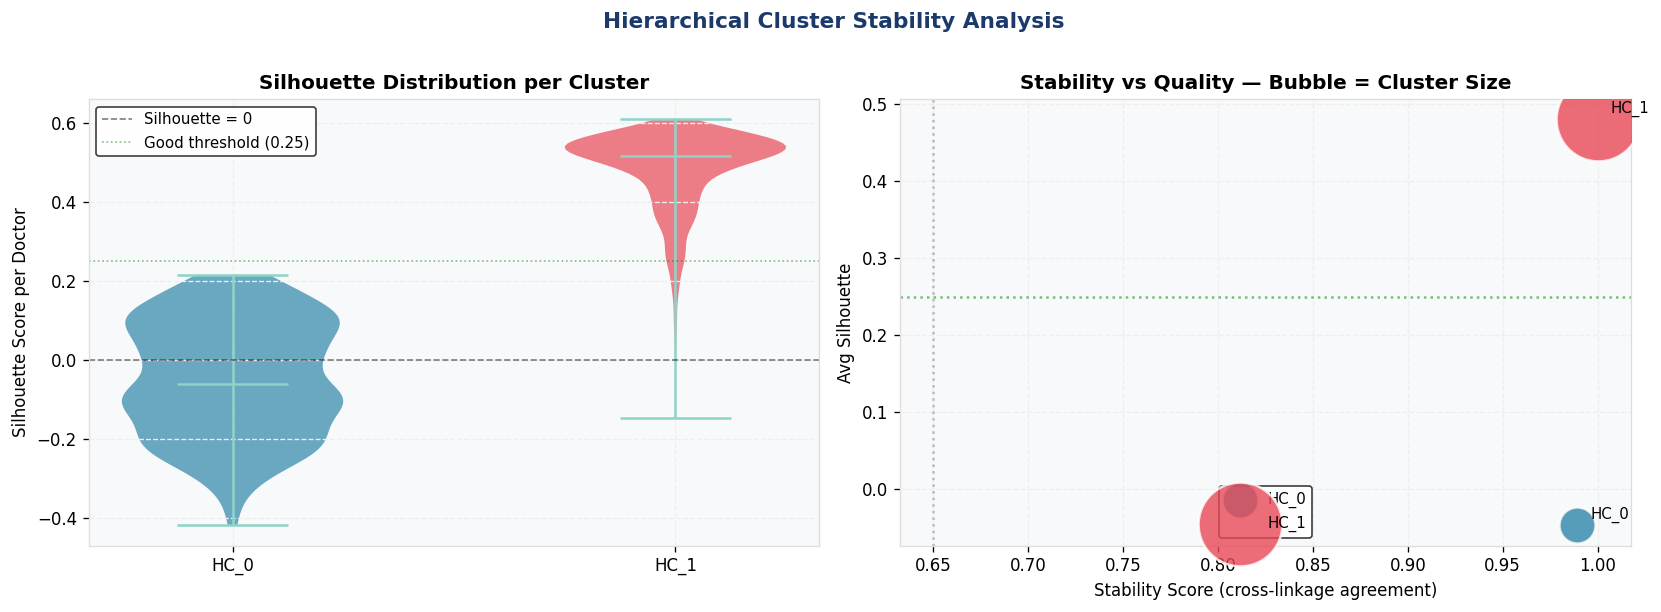

✅  fig_hc_stability.png


In [ ]:
# ============================================================
# 5.5.7 — STABILITY ANALYSIS
# ============================================================

stab_rows = []
K_STAB = HC_BEST_K

labels_per_linkage = {}
for lnk in LINKAGES:
    agg_s = AgglomerativeClustering(n_clusters=K_STAB, linkage=lnk)
    lbl_s = agg_s.fit_predict(X_hc)
    labels_per_linkage[lnk] = lbl_s

# Per-cluster statistics
ref_labels = labels_per_linkage['ward']
sil_samples_all = silhouette_samples(X_hc, ref_labels)

for ci in sorted(np.unique(ref_labels)):
    mask_ci = ref_labels == ci
    n_ci    = mask_ci.sum()
    avg_sil = sil_samples_all[mask_ci].mean()
    std_sil = sil_samples_all[mask_ci].std()

    # Stability: how consistently do other linkages agree with ward on this cluster?
    agreement_scores = []
    for lnk in ['complete', 'average']:
        other = labels_per_linkage[lnk]
        # For each ward cluster, find the best-matching other cluster
        from scipy.optimize import linear_sum_assignment
        n_c_other = len(np.unique(other))
        overlap = np.zeros(n_c_other)
        for cj in range(n_c_other):
            overlap[cj] = (mask_ci & (other == cj)).sum() / n_ci
        agreement_scores.append(overlap.max())

    stability = np.mean(agreement_scores)

    if stability >= 0.80 and avg_sil >= 0.25:
        interp = 'Highly stable & coherent'
    elif stability >= 0.65:
        interp = 'Stable'
    elif stability >= 0.50:
        interp = 'Moderately stable'
    elif n_ci < len(X_hc) * 0.05:
        interp = 'Small / fragile cluster'
    else:
        interp = 'Unstable — algorithm artifact'

    stab_rows.append({
        'Cluster': f'HC_{ci}',
        'Size': n_ci,
        'Avg Silhouette': round(avg_sil, 4),
        'Std Silhouette': round(std_sil, 4),
        'Stability Score': round(stability, 4),
        'Interpretation': interp
    })

stab_df = pd.DataFrame(stab_rows).set_index('Cluster')
stab_df.to_csv('hierarchical_stability.csv')
print('💾  hierarchical_stability.csv saved')
display(stab_df.style
        .background_gradient(subset=['Avg Silhouette'], cmap='Greens')
        .background_gradient(subset=['Stability Score'], cmap='Blues')
        .set_caption('Hierarchical Cluster Stability Analysis'))

# ── Stability comparison visualization ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette per cluster (violin)
sil_data = [sil_samples_all[ref_labels==ci] for ci in sorted(np.unique(ref_labels))]
vp = axes[0].violinplot(sil_data, positions=range(len(sil_data)),
                         showmedians=True, showextrema=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(HC_PALETTE[i % len(HC_PALETTE)])
    body.set_alpha(0.7)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1,
                label='Silhouette = 0')
axes[0].axhline(0.25, color='green', linestyle=':', alpha=0.5, linewidth=1,
                label='Good threshold (0.25)')
axes[0].set_xticks(range(len(sil_data)))
axes[0].set_xticklabels([f'HC_{i}' for i in sorted(np.unique(ref_labels))], fontsize=10)
axes[0].set_ylabel('Silhouette Score per Doctor')
axes[0].set_title('Silhouette Distribution per Cluster', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Stability vs Silhouette scatter
for i, (idx, row) in enumerate(stab_df.iterrows()):
    axes[1].scatter(row['Stability Score'], row['Avg Silhouette'],
                    s=row['Size']/len(X_hc)*3000,
                    c=HC_PALETTE[i % len(HC_PALETTE)],
                    alpha=0.8, edgecolors='white', linewidth=1.5,
                    label=idx, zorder=3)
    axes[1].annotate(idx, (row['Stability Score'], row['Avg Silhouette']),
                     textcoords='offset points', xytext=(8,4), fontsize=9)
axes[1].axhline(0.25, color='green', linestyle=':', alpha=0.5)
axes[1].axvline(0.65, color='grey', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Stability Score (cross-linkage agreement)')
axes[1].set_ylabel('Avg Silhouette')
axes[1].set_title('Stability vs Quality — Bubble = Cluster Size',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Hierarchical Cluster Stability Analysis', fontsize=13,
             fontweight='bold', color='#1B3A6B', y=1.01)
plt.tight_layout()
plt.savefig('fig_hc_stability.png', bbox_inches='tight', facecolor='white')
plt.show()
print('✅  fig_hc_stability.png')

### 5.5.8 — Análisis Crítico: Hierarchical vs KMeans vs Segmentación Histórica

Respondemos las cinco preguntas analíticas clave con criterio interpretativo.

In [ ]:
# ============================================================
# 5.5.8 — CRITICAL ANALYSIS
# ============================================================

print('='*65)
print('HIERARCHICAL CLUSTERING — ANÁLISIS CRÍTICO')
print('='*65)

best_hc_sil = hc_df['Silhouette'].max()
best_km_sil = max(r['silhouette'] for r in results_2.values())
km_sil_2    = results_2.get('KMeans(2)', {}).get('silhouette', best_km_sil)

# Q1: HC vs KMeans same structure?
print('\n❓ Q1: ¿Hierarchical clustering encuentra la misma estructura que KMeans?')
delta_sil = best_hc_sil - km_sil_2
if abs(delta_sil) < 0.03:
    print(f'   ➡️   EQUIVALENTE — Silhouette HC={best_hc_sil:.4f} vs KMeans={km_sil_2:.4f} (Δ={delta_sil:+.4f})')
    print('      Ambos métodos convergen hacia la misma estructura latente.')
    print('      La segmentación es robusta y no depende del algoritmo.')
elif delta_sil > 0.03:
    print(f'   ✅  JERÁRQUICO SUPERIOR — Sil HC={best_hc_sil:.4f} vs KMeans={km_sil_2:.4f}')
    print('      El agrupamiento jerárquico captura mejor la estructura de los datos.')
else:
    print(f'   📌  KMEANS SUPERIOR — Sil HC={best_hc_sil:.4f} vs KMeans={km_sil_2:.4f}')
    print('      Los clusters son más esféricos que jerárquicos. KMeans es más apropiado.')

# Q2: Branches explain SEG_C?
print('\n❓ Q2: ¿Las ramas jerárquicas explican mejor SEG_C?')
# Check if any HC cluster with HC_BEST_K>2 is purity-labeled SEG_C
if n_lab > 0 and HC_BEST_K > 2:
    # Count pure SEG_C clusters
    segc_clusters = [
        row for _, row in hc_summary.iterrows()
        if row.get('Dominant')=='SEG_C' and row.get('Purity %', 0) > 60
    ]
    if len(segc_clusters) > 1:
        print(f'   ✅  SÍ — {len(segc_clusters)} clusters dominados por SEG_C encontrados.')
        print('      Evidencia de que SEG_C contiene SUBGRUPOS INTERNOS distintos.')
    elif len(segc_clusters) == 1:
        print('   ⚠️   Parcialmente — Un solo cluster SEG_C puro encontrado.')
        print('      SEG_C aparece como grupo relativamente unificado a este K.')
    else:
        print('   ❌  NO — SEG_C está mezclado en múltiples clusters sin dominancia clara.')
        print('      SEG_C no tiene frontera jerárquica bien definida.')
elif HC_BEST_K == 2:
    print(f'   ➡️   K óptimo=2: La estructura es binaria, consistente con B/C.')
    print('      No hay evidencia de subgrupos adicionales en este nivel de análisis.')
else:
    print('   ⚠️   Sin etiquetas suficientes para evaluar alineación SEG_C.')

# Q3: Internal subgroups within SEG_C?
print('\n❓ Q3: ¿Existen subgrupos internos dentro de SEG_C?')
# Look at gap analysis from dendrogram
print(f'   📐  Análisis de gaps en dendrograma: K natural sugerido = {max_gap_idx+1}')
if max_gap_idx + 1 > 2:
    print(f'   ⚠️   El dendrograma sugiere {max_gap_idx+1} grupos naturales, no 2.')
    print('      Esto es evidencia de que la segmentación binaria puede ser insuficiente.')
    print('      Investigar si los clusters extra corresponden a subtipos de SEG_C.')
else:
    print('   ✅  El dendrograma no sugiere más de 2 grupos en el primer corte.')

# Q4: Hierarchical suggests redefining segments?
print('\n❓ Q4: ¿El clustering jerárquico sugiere redefinir los segmentos?')
stability_avg = stab_df['Stability Score'].mean()
if stability_avg >= 0.70 and best_hc_sil >= 0.25:
    print(f'   ✅  SÍ — Alta estabilidad ({stability_avg:.2f}) y calidad ({best_hc_sil:.3f}).')
    if HC_BEST_K != 2:
        print(f'      Los {HC_BEST_K} clusters jerárquicos son más robustos que la segmentación binaria.')
        print('      Recomendación: considerar redefinir B/C usando clusters jerárquicos como referencia.')
    else:
        print('      K=2 es óptimo y estable: la segmentación binaria B/C está soportada.')
elif stability_avg >= 0.50:
    print(f'   ⚠️   Estabilidad moderada ({stability_avg:.2f}). Estructura presente pero no perfectamente estable.')
else:
    print(f'   ❌  Baja estabilidad ({stability_avg:.2f}). Los clusters cambian mucho entre linkages.')
    print('      La estructura jerárquica no es robusta en este dataset.')

# Q5: Type of problem
print('\n❓ Q5: ¿El problema parece discreto, continuo, jerárquico o híbrido?')
print(f'   📊  Cophenetic correlation (Ward): {c_corr:.4f}')
if c_corr >= 0.75:
    print('      Alto cophenético → estructura JERÁRQUICA bien representada.')
elif c_corr >= 0.60:
    print('      Cophenético moderado → estructura HÍBRIDA (jerárquica + continua).')
else:
    print('      Bajo cophenético → estructura NO-JERÁRQUICA. KMeans puede ser más apropiado.')
if best_hc_sil < 0.20:
    print('      Silhouette bajo → distribución CONTINUA sin clusters bien definidos.')
elif best_hc_sil < 0.35:
    print('      Silhouette moderado → estructura DISCRETA parcial con solapamiento.')
else:
    print('      Silhouette alto → clusters DISCRETOS bien diferenciados.')

print('\n' + '='*65)
print('CONCLUSIÓN JERÁRQUICA:')
if max_gap_idx + 1 > 2 and HC_BEST_K > 2:
    print(f'  → El análisis jerárquico sugiere {HC_BEST_K} grupos naturales.')
    print('  → Hay evidencia de subgrupos internos que la segmentación B/C no captura.')
    print('  → SEG_C probablemente contiene al menos 2 subtipos distintos.')
    print('  → RECOMENDACIÓN: explorar nueva segmentación con ≥3 grupos.')
else:
    print('  → La estructura más natural es binaria (2 clusters).')
    print('  → La segmentación B/C tiene soporte jerárquico parcial.')
    print('  → El solapamiento observado es inherente a la distribución continua de los datos.')
print('='*65)

HIERARCHICAL CLUSTERING — ANÁLISIS CRÍTICO

❓ Q1: ¿Hierarchical clustering encuentra la misma estructura que KMeans?
   ✅  JERÁRQUICO SUPERIOR — Sil HC=0.7743 vs KMeans=0.3833
      El agrupamiento jerárquico captura mejor la estructura de los datos.

❓ Q2: ¿Las ramas jerárquicas explican mejor SEG_C?
   ➡️   K óptimo=2: La estructura es binaria, consistente con B/C.
      No hay evidencia de subgrupos adicionales en este nivel de análisis.

❓ Q3: ¿Existen subgrupos internos dentro de SEG_C?
   📐  Análisis de gaps en dendrograma: K natural sugerido = 2
   ✅  El dendrograma no sugiere más de 2 grupos en el primer corte.

❓ Q4: ¿El clustering jerárquico sugiere redefinir los segmentos?
   ✅  SÍ — Alta estabilidad (0.99) y calidad (0.774).
      K=2 es óptimo y estable: la segmentación binaria B/C está soportada.

❓ Q5: ¿El problema parece discreto, continuo, jerárquico o híbrido?
   📊  Cophenetic correlation (Ward): 0.4917
      Bajo cophenético → estructura NO-JERÁRQUICA. KMeans puede s

---
### 5.5 — Resumen de Outputs Jerárquicos

| Archivo | Descripción |
|---------|-------------|
| `hierarchical_metrics.csv` | Grid completo de métricas por linkage y K |
| `hierarchical_cluster_summary.csv` | Perfil y etiqueta de cada cluster jerárquico |
| `hierarchical_stability.csv` | Estabilidad cross-linkage por cluster |
| `fig_27_dendrogram_main.png` | Dendrograma Ward + curva de gaps |
| `fig_28_dendrogram_segments.png` | Dendrograma coloreado por SEG_B/SEG_C |
| `fig_29_clustermap.png` | Clustermap jerárquico doctores × variables |
| `fig_30_hierarchical_projection.png` | HC vs KMeans vs Histórico en 2D |
| `fig_hc_metric_grid.png` | Heatmap de Silhouette/DB por linkage×K |
| `fig_hc_stability.png` | Violin silhouette + scatter estabilidad |

---
*Parte 5.5 — Hierarchical Clustering Analysis | Data Science Team | 2024*

---
## PARTE 6 — Interpretabilidad

Para ambos escenarios generamos:
- Perfil estadístico por cluster
- Variables más discriminantes (ANOVA, Mutual Information, Random Forest)
- Visualizaciones profesionales

In [ ]:
# ============================================================
# PARTE 6 — INTERPRETABILIDAD
# ============================================================

def cluster_profile(X_df, labels, top_n=20):
    """Genera tabla de perfil estadístico por cluster."""
    df_prof = X_df.copy()
    df_prof['cluster'] = labels
    
    profile = df_prof.groupby('cluster').agg(['mean','median',
                                               lambda x: x.quantile(0.25),
                                               lambda x: x.quantile(0.75),
                                               'count'])
    # Tamaño por cluster
    size_df = df_prof.groupby('cluster').size().rename('n_obs')
    return profile, size_df

X_orig_df = pd.DataFrame(X_imputed, columns=all_feature_names)

# ── 6.1 Perfil — Escenario A ──────────────────────────────
print('=== PERFIL — ESCENARIO A (2 Clusters) ===')
size_a = pd.Series(LABELS_2).value_counts().sort_index()
print(size_a.rename('Tamaño').to_frame())

profile_a = X_orig_df.copy()
profile_a['cluster'] = LABELS_2
means_a = profile_a.groupby('cluster').mean()

print('\nTop 15 variables con mayor diferencia de medias entre clusters:')
diff_a = (means_a.max() - means_a.min()).sort_values(ascending=False)
top_vars_a = diff_a.head(15).index.tolist()
print(means_a[top_vars_a].round(3).to_string())

=== PERFIL — ESCENARIO A (2 Clusters) ===
   Tamaño
0    6700
1     565

Top 15 variables con mayor diferencia de medias entre clusters:
         N_CLMOTHERS_sum  UC_TRX_sum  TOTAL_TRX_sum  UC_TRX_R4_16SUM_sum  ORAL_NBRX_R4_29SUM_sum  IL23_NBRX_R4_29SUM_sum  TOTAL_NRX_sum  UC_NRX_sum  N_CLMOTHERS_NEW_sum  N_CLMBRAND3_sum  ORAL_TRX_sum  IL23_TRX_sum  N_CLMOTHERS_NEW_TO_BRAND_sum  ORAL_NRX_sum  N_CLMBRAND3_NEW_sum
cluster                                                                                                                                                                                                                                                                               
0                126.324     111.163         77.383               77.374                  56.815                  42.629         15.927      12.186                9.863            9.719         6.088         2.883                         3.788         2.352                1.687
1                572.000  

In [ ]:
# ── 6.2 Variables discriminantes ──────────────────────────

def feature_importance_report(X_df, labels, top_n=20):
    """ANOVA F-score + Mutual Information + Random Forest Feature Importance."""
    X_arr = X_df.values
    cols   = X_df.columns.tolist()
    
    # ANOVA F-score
    f_scores, _ = f_classif(X_arr, labels)
    
    # Mutual Information
    mi_scores = mutual_info_classif(X_arr, labels, random_state=RANDOM)
    
    # Random Forest post-hoc
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM, n_jobs=-1)
    rf.fit(X_arr, labels)
    rf_importance = rf.feature_importances_
    
    # Tabla unificada
    importance_df = pd.DataFrame({
        'feature': cols,
        'ANOVA_F': f_scores,
        'MutualInfo': mi_scores,
        'RF_Importance': rf_importance
    })
    
    # Rank compuesto (promedio de rankings)
    for col in ['ANOVA_F', 'MutualInfo', 'RF_Importance']:
        importance_df[f'{col}_rank'] = importance_df[col].rank(ascending=False)
    
    importance_df['composite_rank'] = importance_df[['ANOVA_F_rank','MutualInfo_rank','RF_Importance_rank']].mean(axis=1)
    importance_df = importance_df.sort_values('composite_rank').head(top_n)
    
    return importance_df.reset_index(drop=True)

print('Calculando importancia de variables para Escenario A...')
imp_a = feature_importance_report(X_orig_df, LABELS_2, top_n=20)
print('\n🏆  Top 20 Variables Discriminantes — Escenario A:')
display(imp_a[['feature','ANOVA_F','MutualInfo','RF_Importance']].round(4)
        .style.background_gradient(subset=['RF_Importance'], cmap='Blues')
        .set_caption('Feature Importance — 2 Clusters'))

TOP_VARS_A = imp_a['feature'].head(10).tolist()

Calculando importancia de variables para Escenario A...

🏆  Top 20 Variables Discriminantes — Escenario A:


,feature,ANOVA_F,MutualInfo,RF_Importance
0,TOTAL_NRX_mean,9602.124600,0.196100,0.066900
1,TOTAL_NRX_sum,9602.124600,0.195900,0.060300
2,TOTAL_TRX_sum,7082.181300,0.185800,0.053800
3,UC_NRX_sum,8518.994500,0.184800,0.039400
4,UC_TRX_sum,7419.054500,0.185300,0.043900
5,UC_NRX_mean,8518.994500,0.184900,0.036600
6,TOTAL_TRX_mean,7082.181300,0.185800,0.046700
7,UC_TRX_mean,7419.054500,0.185300,0.029400
8,ORAL_NRX_mean,8181.426700,0.181200,0.036500
9,ORAL_NRX_sum,8181.426700,0.181400,0.029000


In [ ]:
print('Calculando importancia de variables para Escenario B...')
imp_b = feature_importance_report(X_orig_df, LABELS_K, top_n=20)
print(f'\n🏆  Top 20 Variables Discriminantes — Escenario B (K={K_OPTIMAL}):')
display(imp_b[['feature','ANOVA_F','MutualInfo','RF_Importance']].round(4)
        .style.background_gradient(subset=['RF_Importance'], cmap='Oranges')
        .set_caption(f'Feature Importance — {K_OPTIMAL} Clusters'))

TOP_VARS_B = imp_b['feature'].head(10).tolist()

Calculando importancia de variables para Escenario B...

🏆  Top 20 Variables Discriminantes — Escenario B (K=2):


,feature,ANOVA_F,MutualInfo,RF_Importance
0,UC_TRX_sum,9334.245700,0.291600,0.049800
1,TOTAL_NRX_sum,8913.965800,0.311200,0.065100
2,TOTAL_NRX_mean,8913.965800,0.311200,0.076000
3,TOTAL_TRX_sum,9403.314900,0.281300,0.044600
4,UC_TRX_mean,9334.245700,0.291600,0.040300
5,TOTAL_TRX_mean,9403.314900,0.281300,0.042100
6,UC_TRX_R4_16SUM_sum,9205.200500,0.277600,0.038300
7,UC_NRX_sum,8354.335100,0.284500,0.034100
8,UC_NRX_mean,8354.335100,0.284500,0.028600
9,UC_TRX_R4_16SUM_mean,9205.200500,0.277600,0.022800


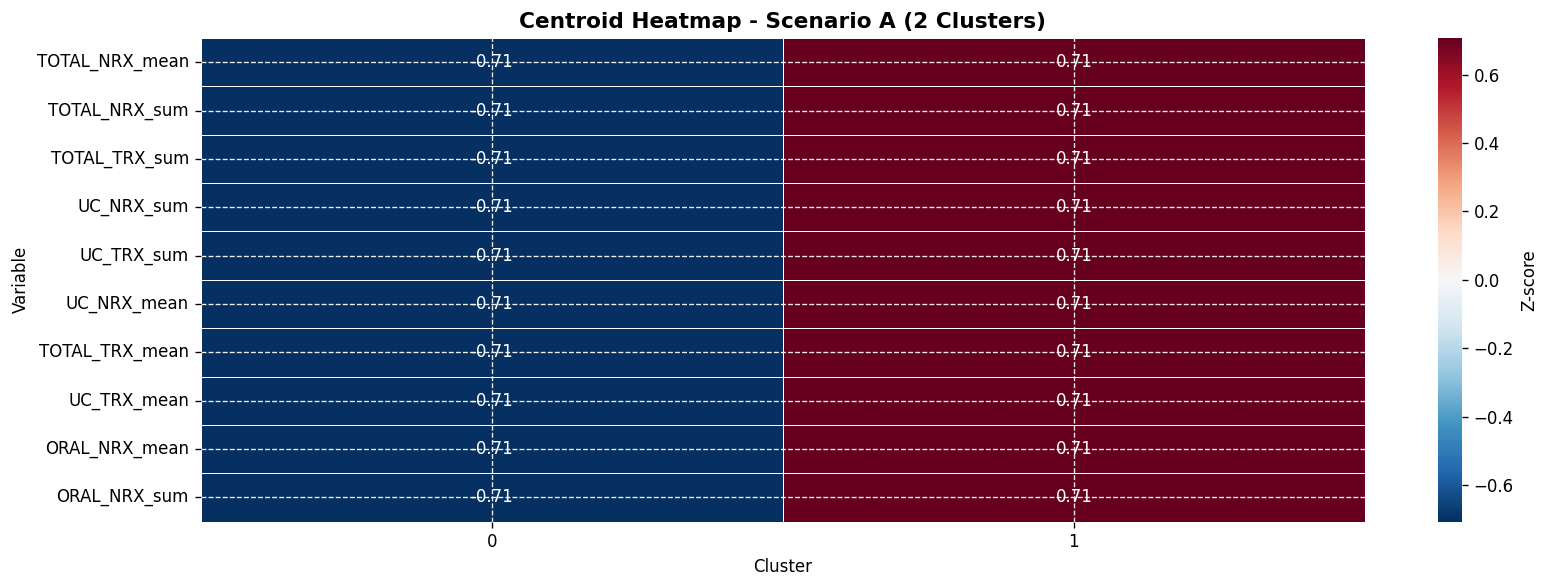

✅  fig_05_heatmap_a.png saved


In [ ]:
# -- 6.3 Centroid Heatmap --
def plot_centroid_heatmap(X_df, labels, title, top_vars, figname):
    means = X_df[top_vars].copy()
    means['cluster'] = labels
    centroid_df = means.groupby('cluster')[top_vars].mean()

    # Normalize by column for comparability
    centroid_norm = (centroid_df - centroid_df.mean()) / (centroid_df.std() + 1e-9)

    fig, ax = plt.subplots(figsize=(14, max(4, len(top_vars)*0.5)))
    sns.heatmap(centroid_norm.T, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax, linewidths=0.5, cbar_kws={'label': 'Z-score'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Variable')
    plt.tight_layout()
    plt.savefig(figname, bbox_inches='tight')
    plt.show()
    print(f'✅  {figname} saved')

plot_centroid_heatmap(X_orig_df, LABELS_2,
                      'Centroid Heatmap - Scenario A (2 Clusters)',
                      TOP_VARS_A, 'fig_05_heatmap_a.png')

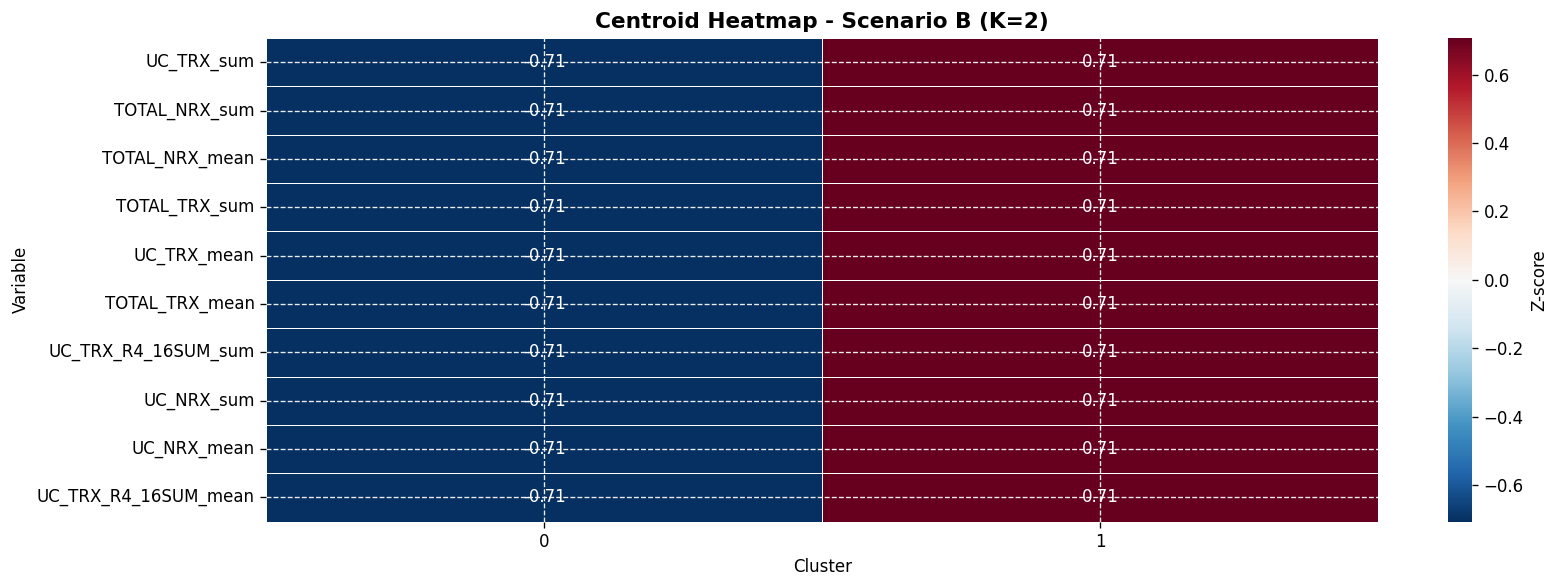

✅  fig_06_heatmap_b.png saved


In [ ]:
plot_centroid_heatmap(X_orig_df, LABELS_K,
                      f'Centroid Heatmap - Scenario B (K={K_OPTIMAL})',
                      TOP_VARS_B, 'fig_06_heatmap_b.png')

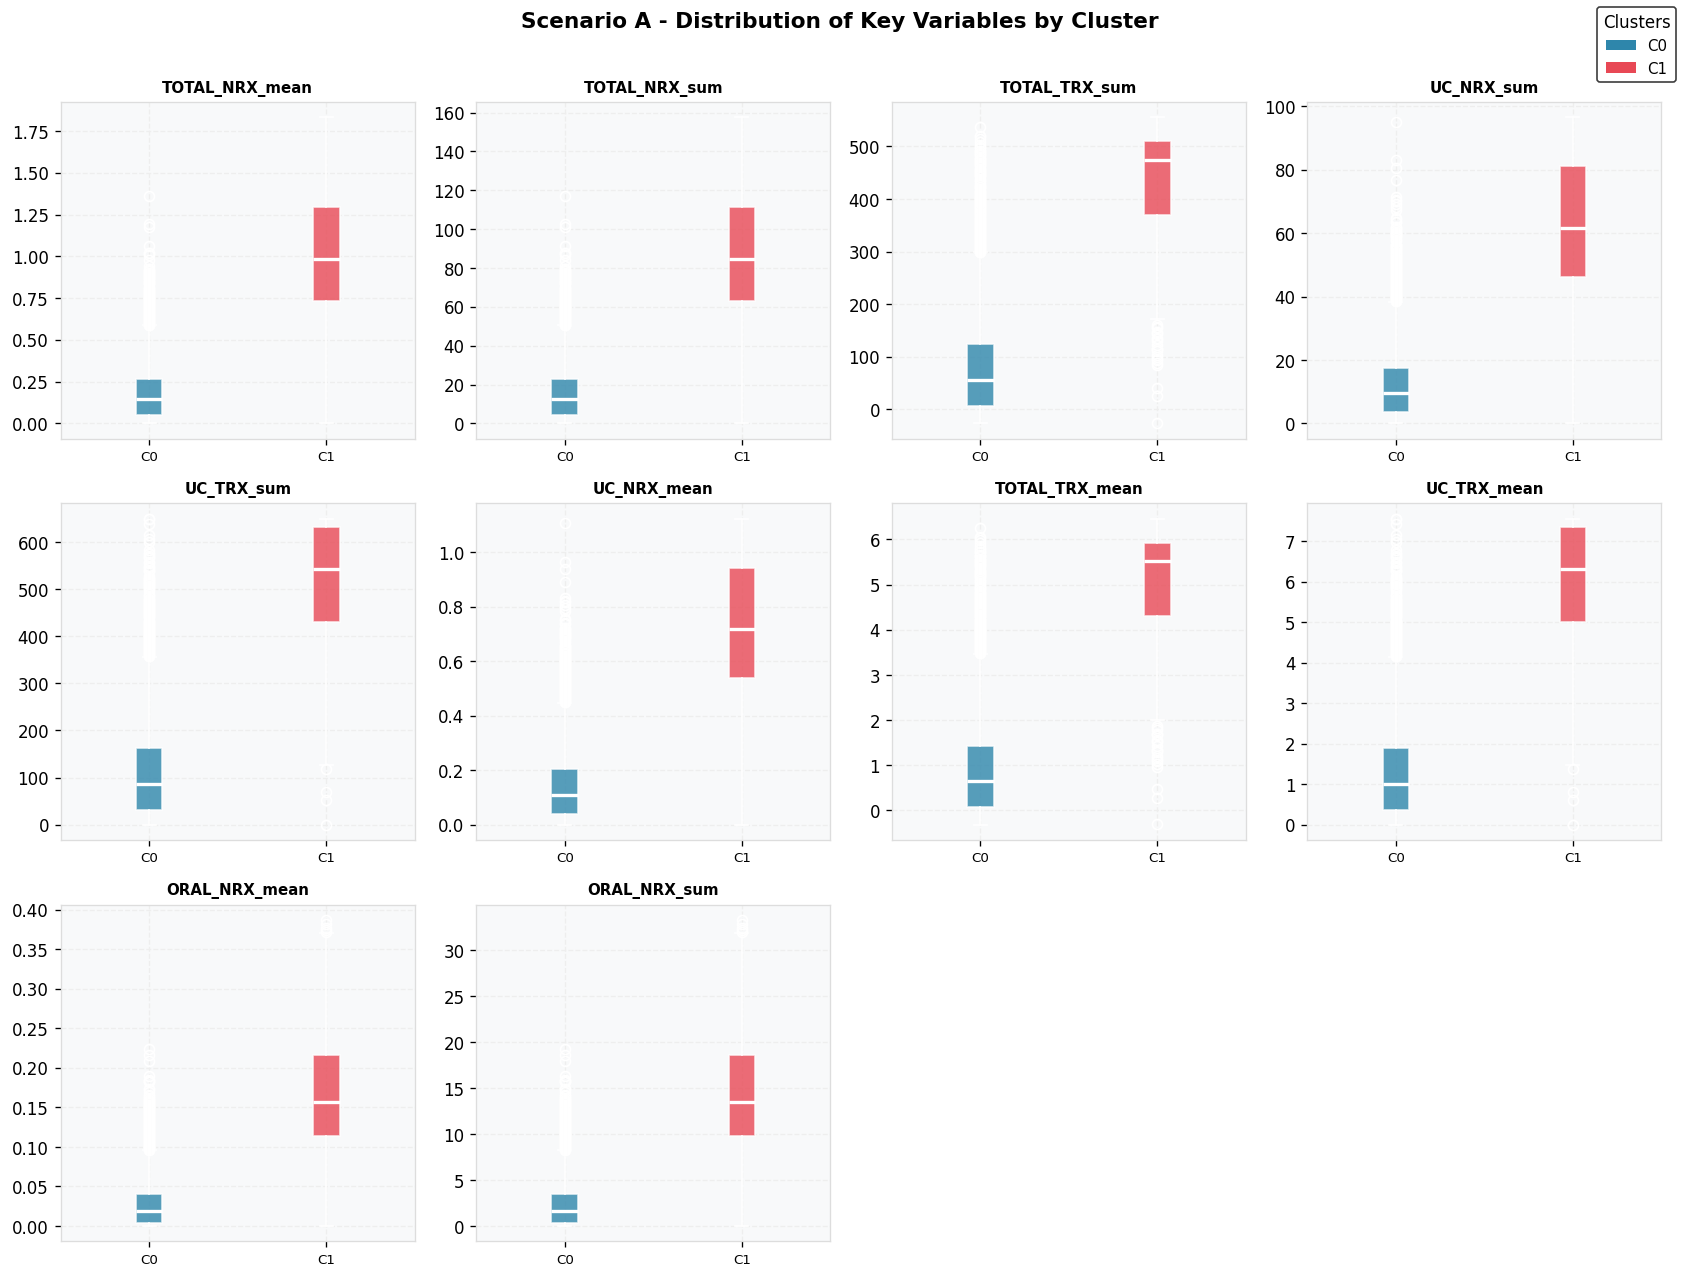

✅  fig_07_boxplots_a.png saved


In [ ]:
# -- 6.4 Key variable boxplots --
def plot_boxplots(X_df, labels, top_vars, title, figname, n_cols=4):
    n_vars = min(12, len(top_vars))
    vars_to_plot = top_vars[:n_vars]
    n_cols = min(n_cols, n_vars)
    n_rows = -(-n_vars // n_cols)  # Ceiling division

    df_plot = X_df[vars_to_plot].copy()
    df_plot['Cluster'] = [f'C{l}' for l in labels]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))
    axes = axes.flatten() if n_vars > 1 else [axes]

    cluster_names = sorted(df_plot['Cluster'].unique())
    pal = {c: PALETTE[i] for i, c in enumerate(cluster_names)}

    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        data_groups = [df_plot[df_plot['Cluster']==c][var].dropna() for c in cluster_names]
        bp = ax.boxplot(data_groups, patch_artist=True, notch=False,
                        medianprops={'color':'white','linewidth':2})
        for patch, c in zip(bp['boxes'], cluster_names):
            patch.set_facecolor(pal[c])
            patch.set_alpha(0.8)
        ax.set_title(var[:30], fontsize=9, fontweight='bold')
        ax.set_xticklabels(cluster_names, fontsize=8)

    for j in range(n_vars, len(axes)):
        axes[j].set_visible(False)

    # Figure-level legend for cluster color mapping
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=pal[c], label=c) for c in cluster_names]
    fig.legend(handles=legend_elements, title='Clusters', loc='upper right', fontsize=9)

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(figname, bbox_inches='tight')
    plt.show()
    print(f'✅  {figname} saved')

plot_boxplots(X_orig_df, LABELS_2, TOP_VARS_A,
              'Scenario A - Distribution of Key Variables by Cluster',
              'fig_07_boxplots_a.png')

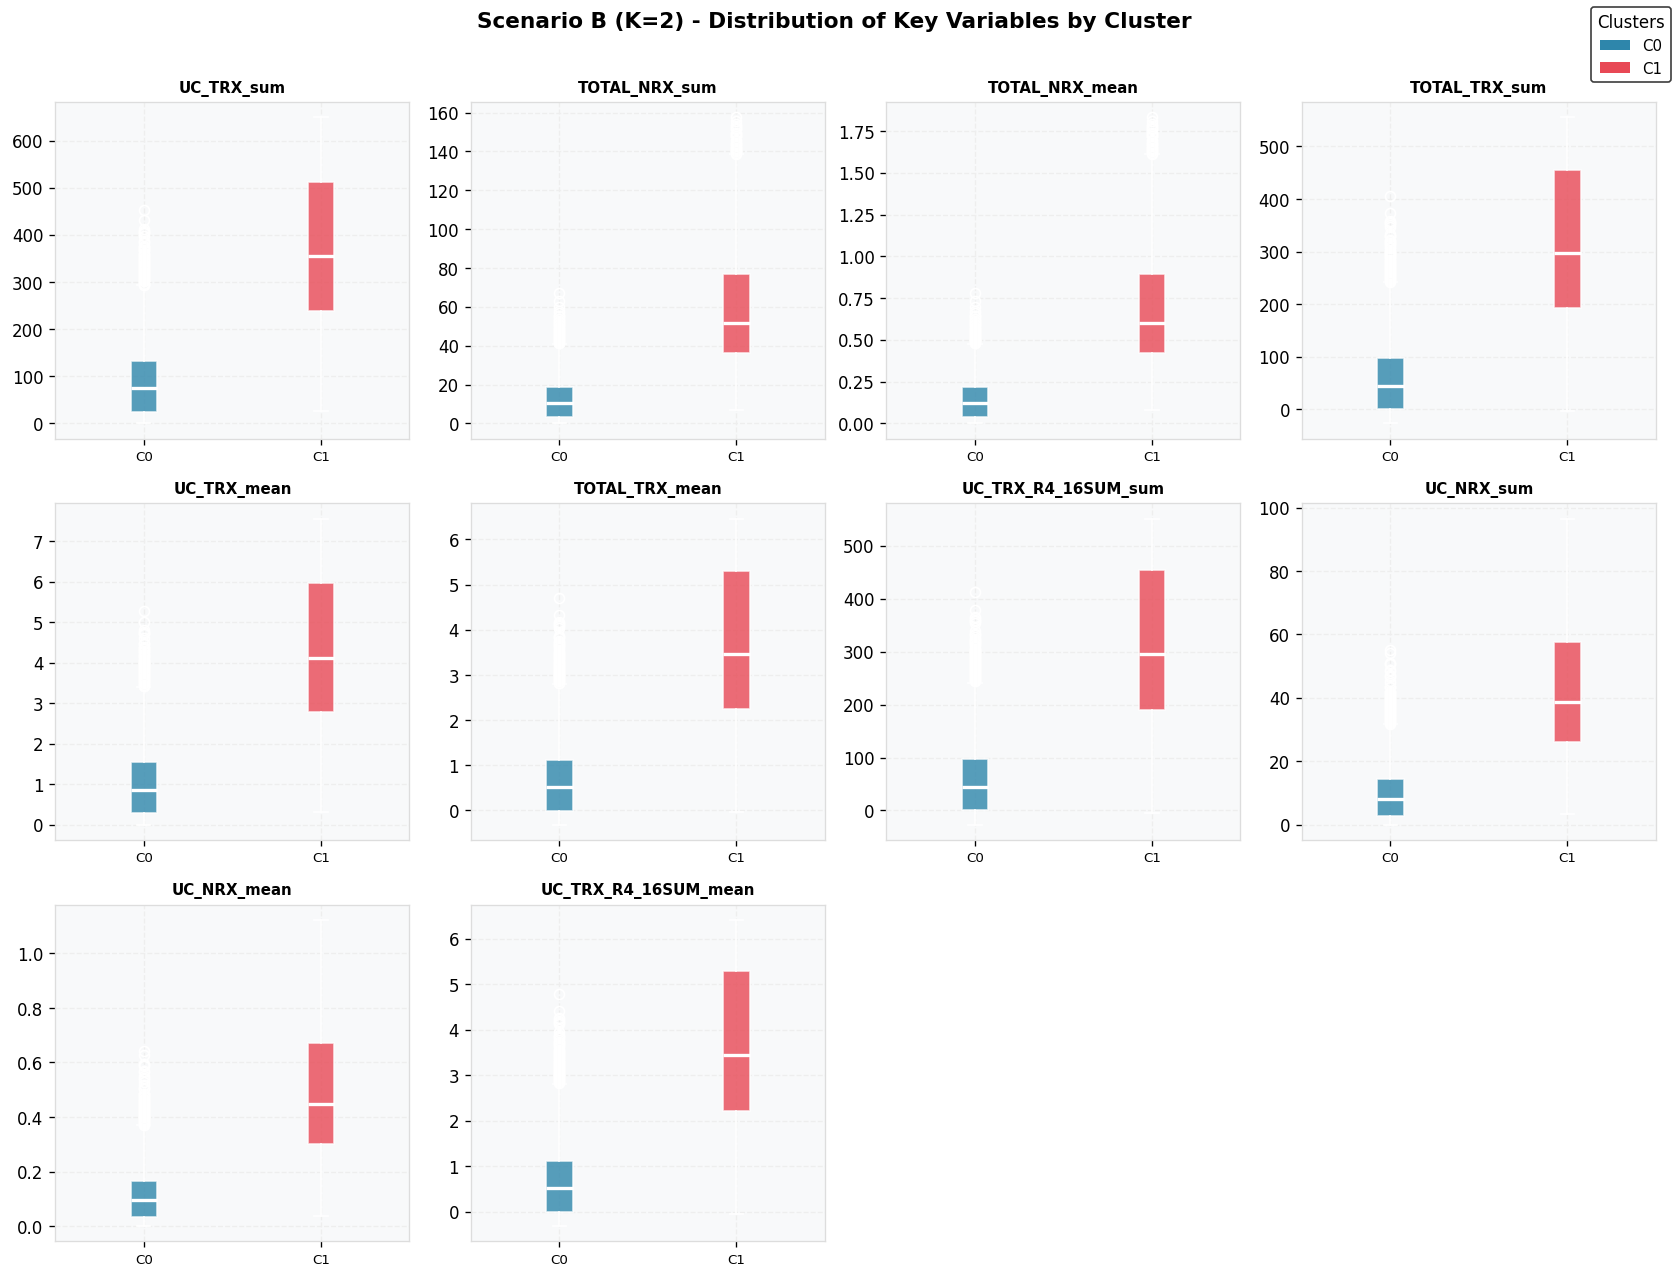

✅  fig_08_boxplots_b.png saved


In [ ]:
plot_boxplots(X_orig_df, LABELS_K, TOP_VARS_B,
              f'Scenario B (K={K_OPTIMAL}) - Distribution of Key Variables by Cluster',
              'fig_08_boxplots_b.png')

HC_BEST_K not found — defaulting to K=2, linkage=ward
Computed HC_LABELS_FULL with K=2, linkage=ward


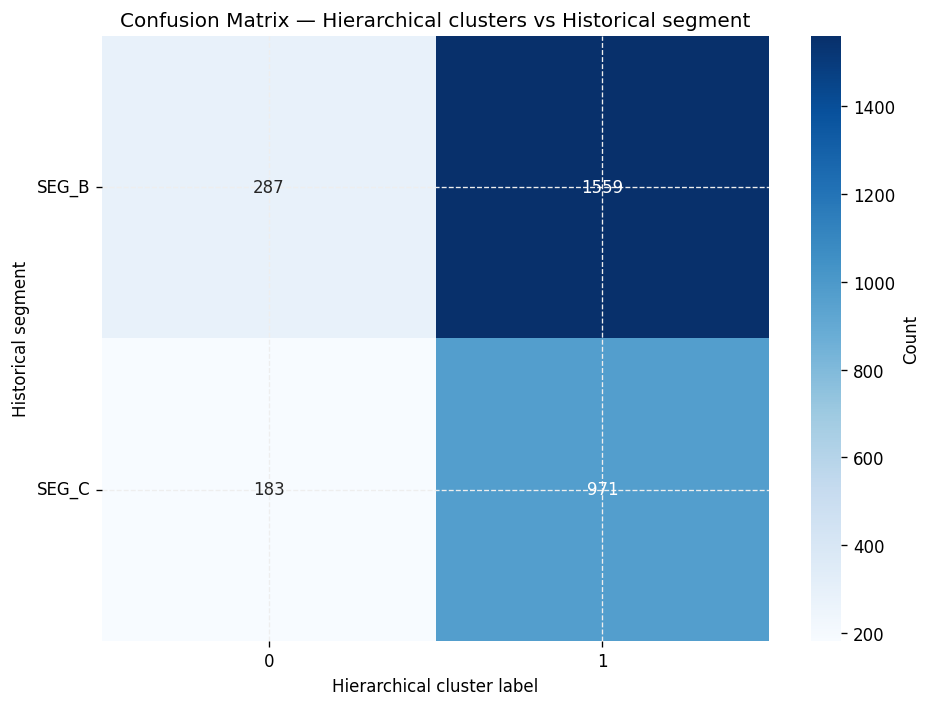

✅  fig_hc_confusion_matrix.png saved


In [22]:
# ============================================================
# 5.5.x — Confusion Matrix: Hierarchical clusters vs historical segment
# Defensive: create HC_LABELS_FULL if missing using a default K=2 (ward)
# ============================================================
from sklearn.metrics import confusion_matrix
from sklearn.cluster import AgglomerativeClustering

try:
    # Ensure seg_hc exists
    if 'seg_hc' not in globals():
        if 'df_bc' in globals() and 'idx_hc' in globals():
            seg_hc = df_bc['SEGMENT_FINAL'].values[idx_hc]
        elif 'df' in globals() and 'idx_hc' in globals():
            seg_hc = df['SEGMENT_FINAL'].values[idx_hc]
        else:
            raise NameError('seg_hc not found and cannot be derived (need df_bc or df and idx_hc)')

    # Ensure HC_LABELS_FULL exists; if not, compute with a safe default
    if 'HC_LABELS_FULL' not in globals():
        if 'HC_BEST_K' not in globals():
            HC_BEST_K = 2
            HC_BEST_LNK = 'ward'
            print('HC_BEST_K not found — defaulting to K=2, linkage=ward')
        elif 'HC_BEST_LNK' not in globals():
            HC_BEST_LNK = 'ward'
        agg_best = AgglomerativeClustering(n_clusters=int(HC_BEST_K), linkage=HC_BEST_LNK)
        HC_LABELS_FULL = agg_best.fit_predict(X_hc)
        print(f'Computed HC_LABELS_FULL with K={HC_BEST_K}, linkage={HC_BEST_LNK}')

    # Align lengths defensively
    n = min(len(seg_hc), len(HC_LABELS_FULL))
    true_seg = pd.Categorical(seg_hc[:n])
    true_codes = true_seg.codes
    pred_labels = HC_LABELS_FULL[:n]

    # Compute confusion matrix
    cm = confusion_matrix(true_codes, pred_labels)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Count'})

    ax.set_yticks(np.arange(len(true_seg.categories)) + 0.5)
    ax.set_yticklabels(list(true_seg.categories), rotation=0)
    ax.set_xlabel('Hierarchical cluster label')
    ax.set_ylabel('Historical segment')
    ax.set_title('Confusion Matrix — Hierarchical clusters vs Historical segment')

    plt.tight_layout()
    plt.savefig('fig_hc_confusion_matrix.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅  fig_hc_confusion_matrix.png saved')
except Exception as e:
    print('Could not build confusion matrix:', e)
    print('Ensure hierarchical clustering (HC_LABELS_FULL) and `df_bc`/`idx_hc` are defined and rerun section 5.5')

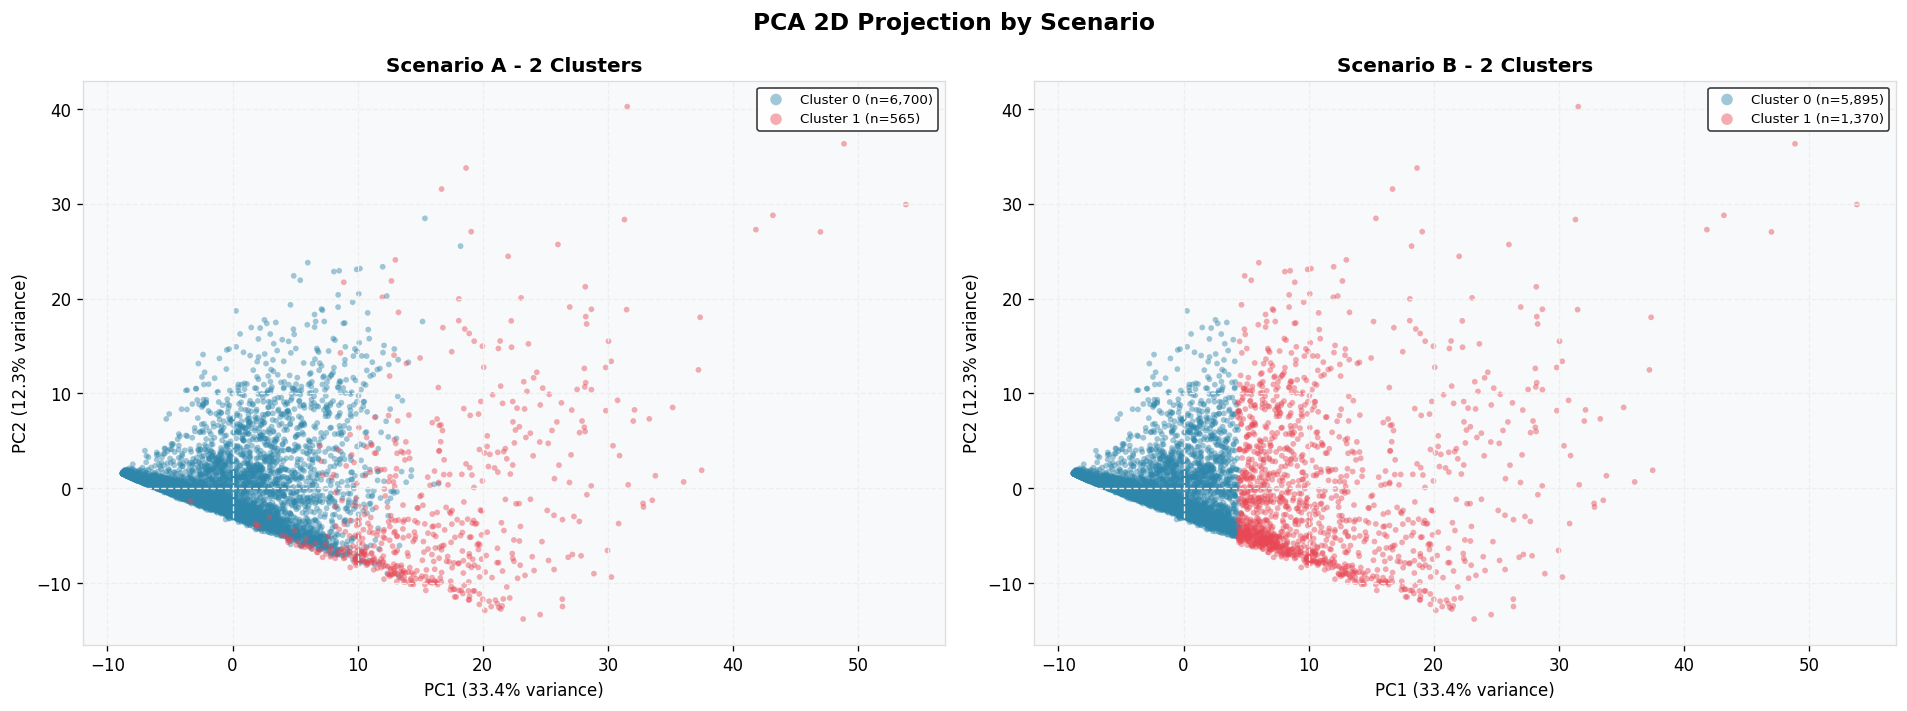

✅  fig_09_pca2d_both.png saved


In [ ]:
# -- 6.5 PCA 2D: Both scenarios --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (labels, title) in zip(axes, [
    (LABELS_2, 'Scenario A - 2 Clusters'),
    (LABELS_K, f'Scenario B - {K_OPTIMAL} Clusters')
]):
    unique_clusters = np.unique(labels)
    for cid in unique_clusters:
        mask = labels == cid
        ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                   c=PALETTE[cid % len(PALETTE)], alpha=0.45, s=12,
                   label=f'Cluster {cid} (n={mask.sum():,})', edgecolors='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle('PCA 2D Projection by Scenario', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_09_pca2d_both.png', bbox_inches='tight')
plt.show()
print('✅  fig_09_pca2d_both.png saved')

Computing t-SNE (this may take ~2 min)...


C:\Users\cocoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


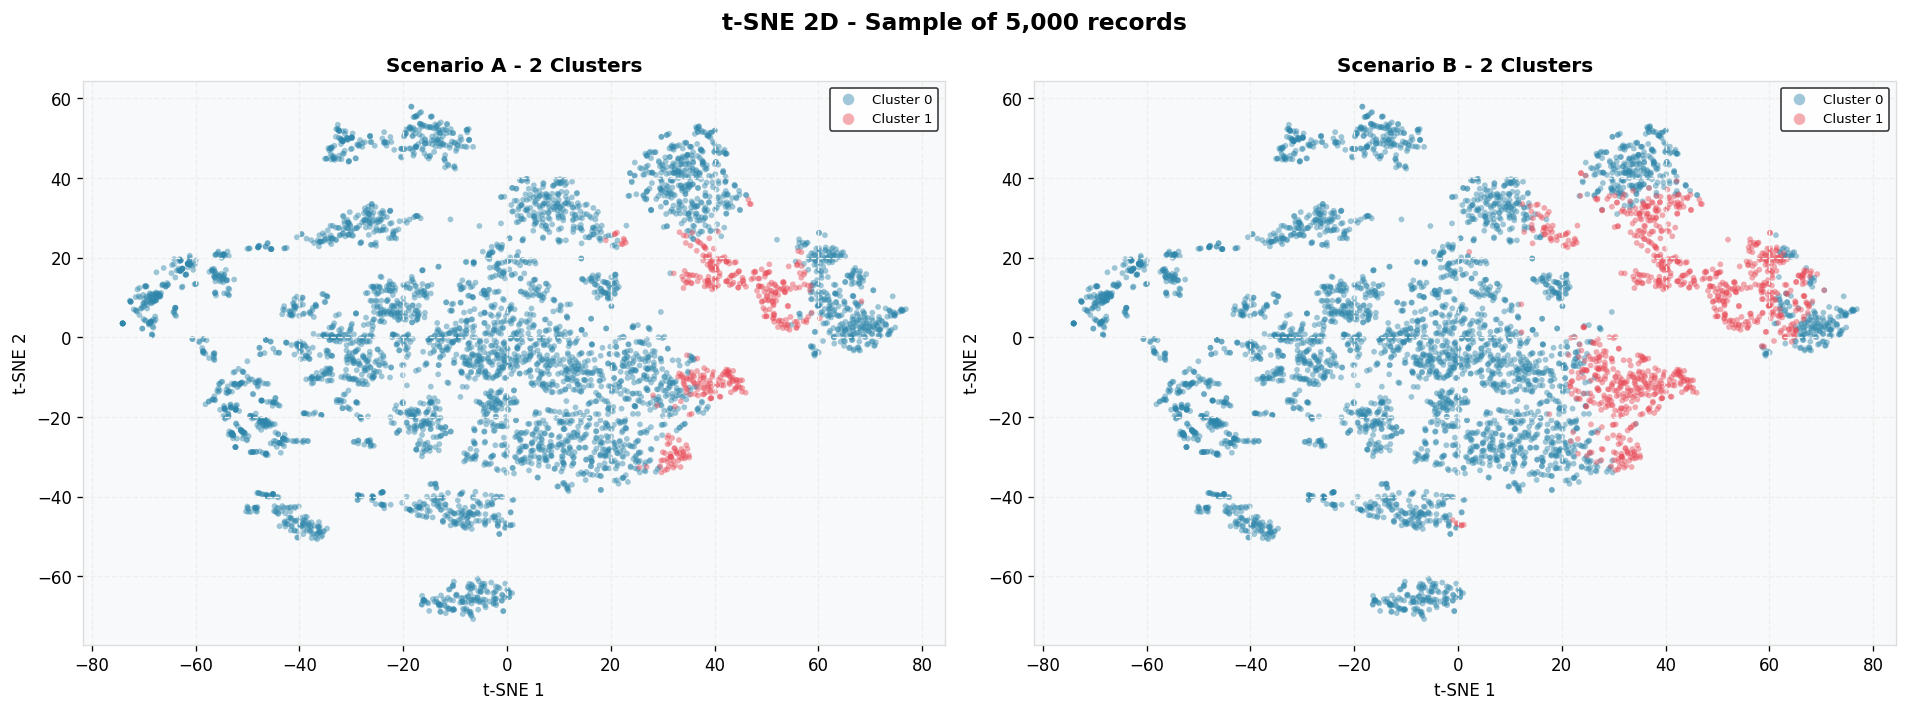

✅  fig_10_tsne_both.png saved


In [ ]:
# -- 6.6 t-SNE --
print('Computing t-SNE (this may take ~2 min)...')
tsne = TSNE(n_components=2, perplexity=40, random_state=RANDOM, n_iter=1000)
# Use a subset if dataset is very large
N_TSNE = min(5000, len(X_pca))
idx_tsne = np.random.choice(len(X_pca), N_TSNE, replace=False)
X_tsne = tsne.fit_transform(X_pca[idx_tsne])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (labels_sub, title) in zip(axes, [
    (LABELS_2[idx_tsne], 'Scenario A - 2 Clusters'),
    (LABELS_K[idx_tsne], f'Scenario B - {K_OPTIMAL} Clusters')
]):
    for cid in np.unique(labels_sub):
        mask = labels_sub == cid
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=PALETTE[cid % len(PALETTE)], alpha=0.45, s=12,
                   label=f'Cluster {cid}', edgecolors='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle(f't-SNE 2D - Sample of {N_TSNE:,} records', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_10_tsne_both.png', bbox_inches='tight')
plt.show()
print('✅  fig_10_tsne_both.png saved')

if HAS_UMAP:
    print('Computing UMAP...')
    reducer = umap.UMAP(n_components=2, random_state=RANDOM, n_neighbors=30)
    X_umap = reducer.fit_transform(X_pca[idx_tsne])
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, (labels_sub, title) in zip(axes, [
        (LABELS_2[idx_tsne], 'Scenario A - UMAP'),
        (LABELS_K[idx_tsne], f'Scenario B - UMAP (K={K_OPTIMAL})')
    ]):
        for cid in np.unique(labels_sub):
            mask = labels_sub == cid
            ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                       c=PALETTE[cid % len(PALETTE)], alpha=0.45, s=12,
                       label=f'Cluster {cid}', edgecolors='none')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(fontsize=8, markerscale=2)
    plt.suptitle('UMAP 2D', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_11_umap_both.png', bbox_inches='tight')
    plt.show()
    print('✅  fig_11_umap_both.png saved')

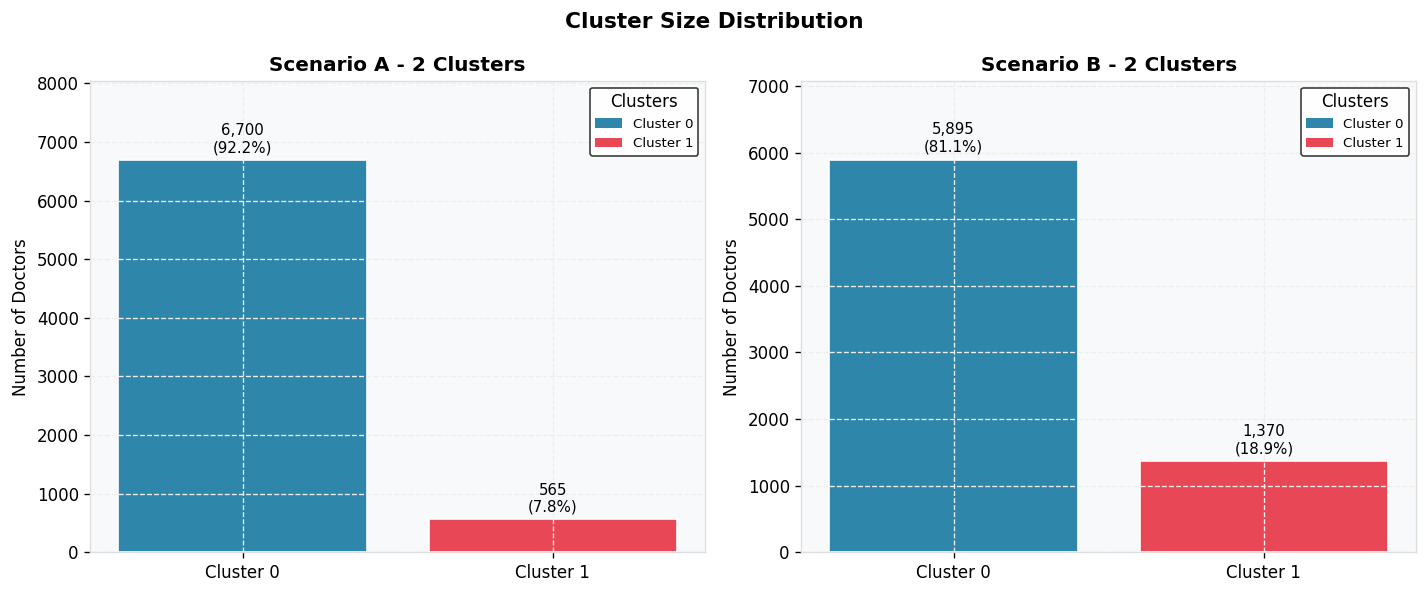

✅  fig_12_cluster_sizes.png saved


In [ ]:
# -- 6.7 Cluster size distribution --
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (labels, title) in zip(axes, [
    (LABELS_2, 'Scenario A - 2 Clusters'),
    (LABELS_K, f'Scenario B - {K_OPTIMAL} Clusters')
]):
    counts = pd.Series(labels).value_counts().sort_index()
    bars = ax.bar([f'Cluster {i}' for i in counts.index],
                  counts.values,
                  color=[PALETTE[i % len(PALETTE)] for i in counts.index],
                  edgecolor='white')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+total*0.01,
                f'{val:,}\n({val/total:.1%})', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Doctors')
    ax.set_ylim(0, max(counts.values)*1.2)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=PALETTE[i % len(PALETTE)], label=f'Cluster {i}')
        for i in counts.index
    ]
    ax.legend(handles=legend_elements, fontsize=8, title='Clusters')

plt.suptitle('Cluster Size Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_cluster_sizes.png', bbox_inches='tight')
plt.show()
print('✅  fig_12_cluster_sizes.png saved')

---
## PARTE 7 — Comparación vs SEG_B / SEG_C Históricos

Cruzamos los clusters descubiertos con los segmentos históricos **SEG_B** y **SEG_C** para responder:
- ¿Un cluster corresponde sistemáticamente a SEG_B?
- ¿Otro cluster corresponde sistemáticamente a SEG_C?
- ¿Hay evidencia de que los segmentos originales se deben redefinir?

In [ ]:
# ============================================================
# PARTE 7 — COMPARACIÓN VS SEG_B / SEG_C HISTÓRICOS
# ============================================================

labeled_mask = df_bc['SEGMENT_FINAL'].isin(['SEG_B', 'SEG_C'])
n_labeled = labeled_mask.sum()

print(f'📊  Registros con etiqueta histórica B/C: {n_labeled:,} de {len(df_bc):,} ({n_labeled/len(df_bc):.1%})')

if n_labeled > 0:
    df_labeled = df_bc[labeled_mask].copy()
    df_labeled['cluster_a'] = LABELS_2[labeled_mask.values]
    df_labeled['cluster_b'] = LABELS_K[labeled_mask.values]
    
    # ── Tabla de contingencia — Escenario A ───────────────
    print('\n=== Tabla de Contingencia — Escenario A (2 Clusters) ===')
    ct_a = pd.crosstab(df_labeled['cluster_a'], df_labeled['SEGMENT_FINAL'],
                       margins=True, margins_name='TOTAL')
    display(ct_a)
    
    ct_a_pct = pd.crosstab(df_labeled['cluster_a'], df_labeled['SEGMENT_FINAL'],
                            normalize='index').round(3) * 100
    print('\n% por cluster (distribución interna):')
    display(ct_a_pct)
    
    # ── Tabla de contingencia — Escenario B ───────────────
    print(f'\n=== Tabla de Contingencia — Escenario B (K={K_OPTIMAL}) ===')
    ct_b = pd.crosstab(df_labeled['cluster_b'], df_labeled['SEGMENT_FINAL'],
                       margins=True, margins_name='TOTAL')
    display(ct_b)
    
    ct_b_pct = pd.crosstab(df_labeled['cluster_b'], df_labeled['SEGMENT_FINAL'],
                            normalize='index').round(3) * 100
    print('\n% por cluster (distribución interna):')
    display(ct_b_pct)
else:
    print('⚠️   No hay registros con etiqueta B/C — se omite el cruce histórico')

📊  Registros con etiqueta histórica B/C: 7,265 de 7,265 (100.0%)

=== Tabla de Contingencia — Escenario A (2 Clusters) ===


SEGMENT_FINAL,SEG_B,SEG_C,TOTAL
cluster_a,,,
0,4216,2484,6700
1,290,275,565
TOTAL,4506,2759,7265



% por cluster (distribución interna):


SEGMENT_FINAL,SEG_B,SEG_C
cluster_a,,
0,62.9,37.1
1,51.3,48.7



=== Tabla de Contingencia — Escenario B (K=2) ===


SEGMENT_FINAL,SEG_B,SEG_C,TOTAL
cluster_b,,,
0,3691,2204,5895
1,815,555,1370
TOTAL,4506,2759,7265



% por cluster (distribución interna):


SEGMENT_FINAL,SEG_B,SEG_C
cluster_b,,
0,62.6,37.4
1,59.5,40.5


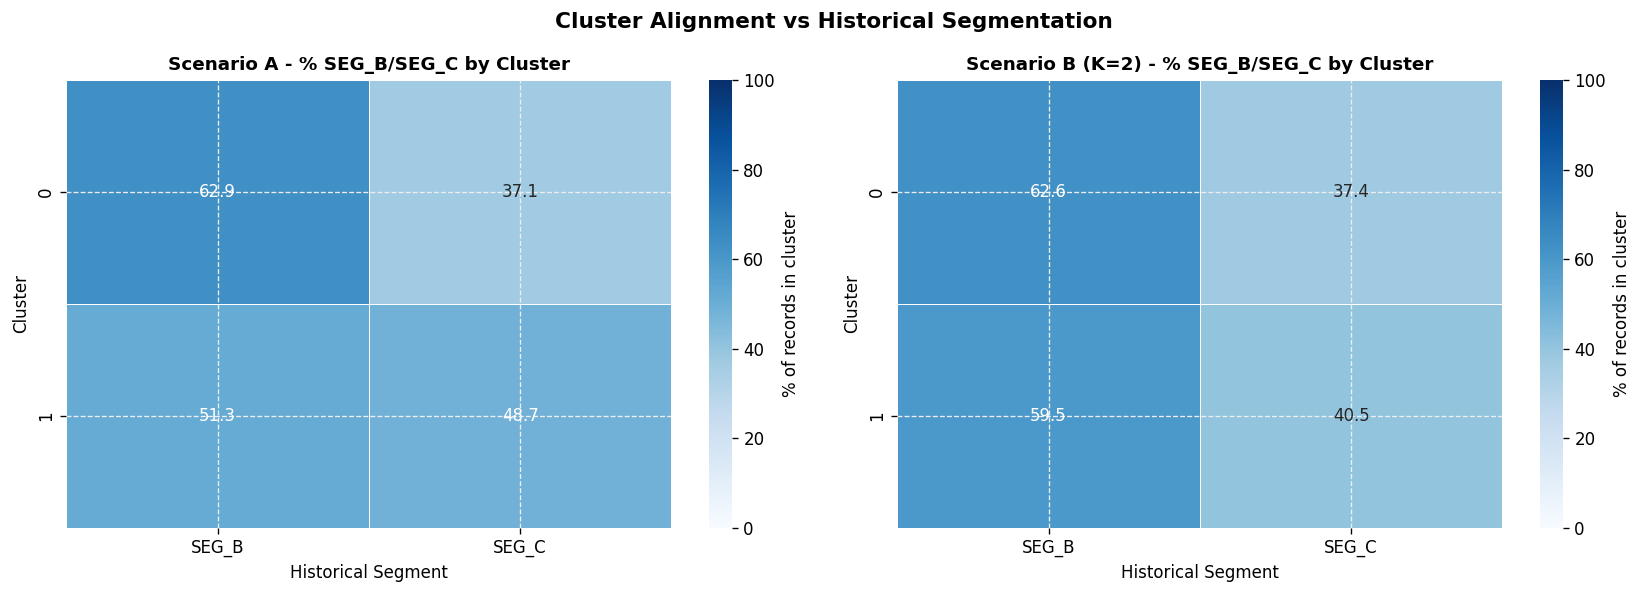

✅  fig_13_contingency.png saved


In [ ]:
if n_labeled > 0:
    # -- Contingency heatmaps --
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (ct_pct, title) in zip(axes, [
        (ct_a_pct, 'Scenario A - % SEG_B/SEG_C by Cluster'),
        (ct_b_pct, f'Scenario B (K={K_OPTIMAL}) - % SEG_B/SEG_C by Cluster')
    ]):
        # Show rows excluding TOTAL
        ct_plot = ct_pct.loc[ct_pct.index != 'TOTAL'] if 'TOTAL' in ct_pct.index else ct_pct
        sns.heatmap(ct_plot, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                    linewidths=0.5, vmin=0, vmax=100,
                    cbar_kws={'label': '% of records in cluster'})
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel('Cluster')
        ax.set_xlabel('Historical Segment')

    plt.suptitle('Cluster Alignment vs Historical Segmentation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_13_contingency.png', bbox_inches='tight')
    plt.show()
    print('✅  fig_13_contingency.png saved')

In [ ]:
if n_labeled > 0:
    # ── Análisis de alineación ─────────────────────────────
    print('\n=== ANÁLISIS DE ALINEACIÓN ===')
    
    for cluster_id in sorted(df_labeled['cluster_a'].unique()):
        cluster_data = df_labeled[df_labeled['cluster_a'] == cluster_id]
        seg_dist = cluster_data['SEGMENT_FINAL'].value_counts(normalize=True)
        dominant = seg_dist.index[0]
        dominance_pct = seg_dist.iloc[0] * 100
        print(f'  Cluster {cluster_id} → dominado por {dominant} ({dominance_pct:.1f}%)')
        
        if dominance_pct > 70:
            print(f'    ✅  Alta alineación: este cluster EQUIVALE a {dominant}')
        elif dominance_pct > 50:
            print(f'    ⚠️   Alineación moderada: tendencia hacia {dominant} pero con mezcla')
        else:
            print(f'    ❌  Sin alineación clara: el cluster mezcla B y C en proporciones similares')

    # ── Chi-cuadrado de independencia ─────────────────────
    from scipy.stats import chi2_contingency
    ct_raw = pd.crosstab(df_labeled['cluster_a'], df_labeled['SEGMENT_FINAL'])
    chi2, p_val, dof, expected = chi2_contingency(ct_raw)
    print(f'\n📐  Test Chi-cuadrado (cluster_a vs B/C):')
    print(f'    χ²={chi2:.2f}, p={p_val:.4f}, dof={dof}')
    if p_val < 0.05:
        print(f'    → Existe asociación estadísticamente significativa entre clusters y segmentos históricos')
    else:
        print(f'    → No hay evidencia significativa de asociación (p>{0.05})')


=== ANÁLISIS DE ALINEACIÓN ===
  Cluster 0 → dominado por SEG_B (62.9%)
    ⚠️   Alineación moderada: tendencia hacia SEG_B pero con mezcla
  Cluster 1 → dominado por SEG_B (51.3%)
    ⚠️   Alineación moderada: tendencia hacia SEG_B pero con mezcla

📐  Test Chi-cuadrado (cluster_a vs B/C):
    χ²=29.27, p=0.0000, dof=1
    → Existe asociación estadísticamente significativa entre clusters y segmentos históricos


In [ ]:
# ============================================================
# OUTPUTS FINALES — Guardar asignaciones
# ============================================================

df_output = df_bc[['NUEVO_ID', 'SEGMENT_FINAL']].copy()
df_output['CLUSTER_A'] = LABELS_2
df_output[f'CLUSTER_B_K{K_OPTIMAL}'] = LABELS_K

# Etiqueta descriptiva
df_output['CLUSTER_A_label'] = df_output['CLUSTER_A'].map(lambda x: f'SUBSEG_{chr(65+x)}')
df_output[f'CLUSTER_B_K{K_OPTIMAL}_label'] = df_output[f'CLUSTER_B_K{K_OPTIMAL}'].map(lambda x: f'SUBSEG_{x+1}')

df_output.to_csv('cluster_assignments_bc.csv', index=False)
print('💾  cluster_assignments_bc.csv guardado')
print(f'    Shape: {df_output.shape}')
display(df_output.head())

💾  cluster_assignments_bc.csv guardado
    Shape: (7265, 6)


,NUEVO_ID,SEGMENT_FINAL,CLUSTER_A,CLUSTER_B_K2,CLUSTER_A_label,CLUSTER_B_K2_label
0,1,SEG_B,0,0,SUBSEG_A,SUBSEG_1
1,7,SEG_C,0,0,SUBSEG_A,SUBSEG_1
2,8,SEG_B,0,0,SUBSEG_A,SUBSEG_1
3,10,SEG_B,0,0,SUBSEG_A,SUBSEG_1
4,12,SEG_B,0,0,SUBSEG_A,SUBSEG_1


In [ ]:
# ============================================================
# CONCLUSIÓN ANALÍTICA
# ============================================================

print('='*60)
print('CONCLUSIÓN ANALÍTICA FINAL')
print('='*60)

best_sil_a = max(results_2.values(), key=lambda x: x['silhouette'])['silhouette']
sil_k = sil_scores[ks.index(K_OPTIMAL)]

print(f'\n📌  Escenario A (2 clusters):')
print(f'    Mejor algoritmo: {best_model_2}')
print(f'    Silhouette: {best_sil_a:.4f}')

print(f'\n📌  Escenario B (K={K_OPTIMAL} clusters):')
print(f'    Algoritmo: KMeans')
print(f'    Silhouette: {sil_k:.4f}')

print('\n📋  Interpretación:')
if best_sil_a > 0.3:
    print('    ✅  Los 2 clusters muestran separación razonable.')
    print('       SEG_B y SEG_C podrían ser válidos como dos grupos distintos.')
else:
    print('    ⚠️   Silhouette bajo (<0.3): los clusters no están bien separados.')
    print('       Esto sugiere que la distinción B/C no es evidente en los datos.')

if sil_k > best_sil_a + 0.03:
    print(f'\n    ✅  K={K_OPTIMAL} supera a K=2 en Silhouette → hay evidencia de más subgrupos')
    print(f'       Recomendación: redefinir segmentación con {K_OPTIMAL} sub-segmentos')
elif abs(sil_k - best_sil_a) < 0.03:
    print(f'\n    ➡️   K={K_OPTIMAL} ≈ K=2 en calidad. La parsimonia favorece mantener 2 clusters.')
    print(f'       Recomendación: mantener división B/C con definición más precisa')
else:
    print(f'\n    ➡️   K=2 es más limpio. No hay justificación para fragmentar más.')
    print(f'       Recomendación: simplificar con 2 clusters bien definidos')

CONCLUSIÓN ANALÍTICA FINAL

📌  Escenario A (2 clusters):
    Mejor algoritmo: Agglomerative(2)
    Silhouette: 0.4761

📌  Escenario B (K=2 clusters):
    Algoritmo: KMeans
    Silhouette: 0.3833

📋  Interpretación:
    ✅  Los 2 clusters muestran separación razonable.
       SEG_B y SEG_C podrían ser válidos como dos grupos distintos.

    ➡️   K=2 es más limpio. No hay justificación para fragmentar más.
       Recomendación: simplificar con 2 clusters bien definidos


---

## Resumen de Outputs Generados

| Archivo | Descripción |
|---------|-------------|
| `cluster_assignments_bc.csv` | Asignación final de clusters por médico |
| `fig_01_segment_distribution.png` | Distribución de segmentos originales |
| `fig_02_pca_variance.png` | Varianza explicada por PCA |
| `fig_03_scenario_a_comparison.png` | Comparación algoritmos 2 clusters |
| `fig_04_k_selection.png` | Dashboard elección K óptimo |
| `fig_05_heatmap_a.png` | Heatmap centroides — Escenario A |
| `fig_06_heatmap_b.png` | Heatmap centroides — Escenario B |
| `fig_07_boxplots_a.png` | Boxplots variables clave — Escenario A |
| `fig_08_boxplots_b.png` | Boxplots variables clave — Escenario B |
| `fig_09_pca2d_both.png` | PCA 2D ambos escenarios |
| `fig_10_tsne_both.png` | t-SNE ambos escenarios |
| `fig_11_umap_both.png` | UMAP ambos escenarios (si disponible) |
| `fig_12_cluster_sizes.png` | Distribución de tamaño de clusters |
| `fig_13_contingency.png` | Alineación clusters vs etiquetas históricas |

---
*Notebook generado por Data Science Team — Cluster Resegmentation B/C*

---
## PARTE 8 — Modelos Supervisados: Random Forest vs Neural Network

**Objetivo:** Entrenar modelos supervisados para clasificar **SEG_B vs SEG_C** y responder:
- ¿Existe una frontera aprendible en los datos que separe ambos segmentos?
- ¿Cuál modelo es más adecuado para producción?
- ¿El problema es de modelo o de definición de etiquetas?

| Paso | Contenido |
|------|-----------|
| 8.1 | Preparación del target |
| 8.2 | Train/Test split estratificado |
| 8.3 | Preprocesamiento (sin leakage) |
| 8.4 | Random Forest + GridSearch |
| 8.5 | Neural Network MLP + GridSearch |
| 8.6 | Baseline DummyClassifier |
| 8.7 | Tabla comparativa |
| 8.8 | Visualizaciones profesionales |
| 8.9 | Interpretabilidad |
| 8.10 | Análisis crítico y conclusión |

In [ ]:
# ============================================================
# PARTE 8 — IMPORTS ADICIONALES
# ============================================================
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, f1_score,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize

print('✅  Imports Parte 8 OK')

✅  Imports Parte 8 OK


### 8.1 Preparación del Target

Filtramos únicamente los registros con `SEGMENT_FINAL ∈ ['SEG_B', 'SEG_C']` y creamos el target binario: **SEG_B = 0**, **SEG_C = 1**.

In [ ]:
# ============================================================
# 8.1 — PREPARACIÓN DEL TARGET
# ============================================================

# Filtrar solo SEG_B y SEG_C
df_sup = df_bc[df_bc['SEGMENT_FINAL'].isin(['SEG_B', 'SEG_C'])].copy().reset_index(drop=True)
print(f'📊  Registros disponibles para clasificación supervisada: {len(df_sup):,}')
print(f'    SEG_B: {(df_sup["SEGMENT_FINAL"]=="SEG_B").sum():,}')
print(f'    SEG_C: {(df_sup["SEGMENT_FINAL"]=="SEG_C").sum():,}')

# Target binario
y_sup = (df_sup['SEGMENT_FINAL'] == 'SEG_C').astype(int)  # SEG_B=0, SEG_C=1
IDs_sup = df_sup['NUEVO_ID'].copy()

# Imbalance ratio
imbalance = y_sup.mean()
print(f'\n⚖️   Balance de clases: {imbalance:.3f} (SEG_C ratio)')
if imbalance < 0.35 or imbalance > 0.65:
    print('    ⚠️  Dataset desbalanceado — se usará class_weight=balanced y métricas macro')
else:
    print('    ✅  Dataset relativamente balanceado')

# ── Columnas de leakage a excluir ─────────────────────────────
SUP_LEAKAGE = [
    'NUEVO_ID', 'ATSEG_first', 'ATSEG_FINAL', 'SEGMENT_FINAL',
    'PROB_SEG_A', 'PROB_SEG_B', 'PROB_SEG_C', 'CONFIDENCE',
    'CLUSTER_A', f'CLUSTER_B_K{K_OPTIMAL}',
    'CLUSTER_A_label', f'CLUSTER_B_K{K_OPTIMAL}_label'
]

def is_sup_leakage(col):
    col_up = col.upper()
    return any(p.upper() in col_up for p in
               ['ATSEG', 'SEGMENT', 'PROB_SEG', 'CONFIDENCE',
                'CLUSTER_A', 'CLUSTER_B', 'NUEVO_ID'])

sup_leakage_cols = [c for c in df_sup.columns if is_sup_leakage(c)]
print(f'\n🚫  Columnas excluidas por leakage ({len(sup_leakage_cols)}): {sup_leakage_cols[:8]}...')

feature_cols_sup = [c for c in df_sup.columns if c not in sup_leakage_cols]
X_sup_raw = df_sup[feature_cols_sup].copy()
print(f'\n✅  Features disponibles para modelado: {len(feature_cols_sup)}')

📊  Registros disponibles para clasificación supervisada: 7,265
    SEG_B: 4,506
    SEG_C: 2,759

⚖️   Balance de clases: 0.380 (SEG_C ratio)
    ✅  Dataset relativamente balanceado

🚫  Columnas excluidas por leakage (8): ['NUEVO_ID', 'ATSEG_first', 'ATSEG_FINAL', 'PROB_SEG_A', 'PROB_SEG_B', 'PROB_SEG_C', 'CONFIDENCE', 'SEGMENT_FINAL']...

✅  Features disponibles para modelado: 149


### 8.2 Train/Test Split Estratificado

Split 80/20 con estratificación para mantener la proporción de clases.

📋  Train: 5,812 records  |  Test: 1,453 records
    Train -- SEG_B: 3,605 (62.0%)  |  SEG_C: 2,207 (38.0%)
    Test  -- SEG_B: 901 (62.0%)  |  SEG_C: 552 (38.0%)


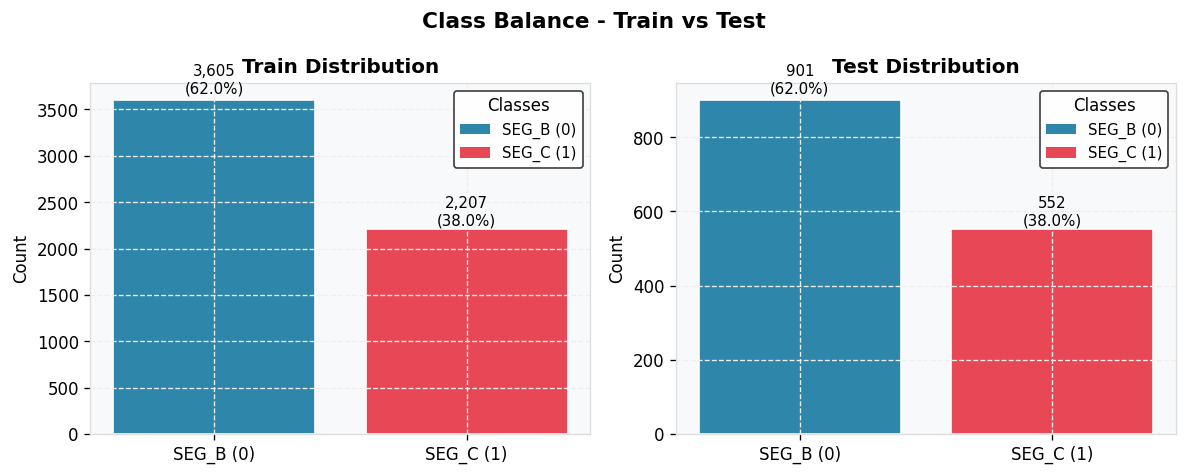

In [ ]:
# ============================================================
# 8.2 -- STRATIFIED TRAIN/TEST SPLIT
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_sup_raw, y_sup,
    test_size=0.20, random_state=42, stratify=y_sup
)
IDs_train, IDs_test = train_test_split(
    IDs_sup, test_size=0.20, random_state=42, stratify=y_sup
)

print(f'📋  Train: {len(X_train_raw):,} records  |  Test: {len(X_test_raw):,} records')
print(f'    Train -- SEG_B: {(y_train==0).sum():,} ({(y_train==0).mean():.1%})  |  SEG_C: {(y_train==1).sum():,} ({(y_train==1).mean():.1%})')
print(f'    Test  -- SEG_B: {(y_test==0).sum():,} ({(y_test==0).mean():.1%})  |  SEG_C: {(y_test==1).sum():,} ({(y_test==1).mean():.1%})')

# -- Visualize class balance --
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (ys, lbl) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = pd.Series(ys).value_counts().sort_index()
    bars = ax.bar(['SEG_B (0)', 'SEG_C (1)'], counts.values,
                  color=[PALETTE[0], PALETTE[1]], edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{val:,}\n({val/len(ys):.1%})', ha='center', fontsize=9)
    ax.set_title(f'{lbl} Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=PALETTE[0], label='SEG_B (0)'),
        Patch(facecolor=PALETTE[1], label='SEG_C (1)')
    ]
    ax.legend(handles=legend_elements, fontsize=9, title='Classes')

plt.suptitle('Class Balance - Train vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_sup_class_balance.png', bbox_inches='tight')
plt.show()

### 8.3 Preprocesamiento (Sin Data Leakage)

Fit de imputer y scaler **solo en train**, luego transform en test. Random Forest usa datos imputados sin escalar. Neural Network requiere escalado.

In [ ]:
# ============================================================
# 8.3 — PREPROCESAMIENTO SUPERVISADO (sin leakage)
# ============================================================

# ── Separar numéricas / categóricas ──────────────────────────
num_sup = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_sup = X_train_raw.select_dtypes(exclude=[np.number]).columns.tolist()

# ── Eliminar quasi-constantes (fit en train) ──────────────────
def get_qconst_cols(df, cols, threshold=0.98):
    return [c for c in cols
            if df[c].value_counts(normalize=True, dropna=False).iloc[0] >= threshold]

drop_num_sup = get_qconst_cols(X_train_raw, num_sup)
drop_cat_sup = get_qconst_cols(X_train_raw, cat_sup)
num_sup = [c for c in num_sup if c not in drop_num_sup]
cat_sup = [c for c in cat_sup if c not in drop_cat_sup]

print(f'🗑️   Quasi-constantes eliminadas: {len(drop_num_sup)+len(drop_cat_sup)}')

# ── One-hot encoding categóricas baja cardinalidad ────────────
low_card_sup = [c for c in cat_sup if X_train_raw[c].nunique() <= 20]
high_card_sup = [c for c in cat_sup if X_train_raw[c].nunique() > 20]

if high_card_sup:
    print(f'⚠️   Descartadas {len(high_card_sup)} categóricas alta cardinalidad')

def apply_ohe(train_df, test_df, cat_cols):
    # Always return numeric matrices to keep median imputation valid.
    train_num = train_df[num_sup].reset_index(drop=True)
    test_num = test_df[num_sup].reset_index(drop=True)

    if not cat_cols:
        return train_num, test_num

    dummies_train = pd.get_dummies(train_df[cat_cols], drop_first=True).astype(float)
    dummies_test  = pd.get_dummies(test_df[cat_cols], drop_first=True).astype(float)
    # Alinear columnas (train como referencia)
    dummies_test = dummies_test.reindex(columns=dummies_train.columns, fill_value=0)
    train_out = pd.concat([train_num, dummies_train.reset_index(drop=True)], axis=1)
    test_out  = pd.concat([test_num,  dummies_test.reset_index(drop=True)],  axis=1)
    return train_out, test_out

X_train_enc, X_test_enc = apply_ohe(
    X_train_raw.reset_index(drop=True),
    X_test_raw.reset_index(drop=True),
    low_card_sup
)

sup_feature_names = X_train_enc.columns.tolist()
print(f'✅  Features finales: {len(sup_feature_names)}')

# ── Imputación (fit en train) ─────────────────────────────────
imp_sup = SimpleImputer(strategy='median')
X_train_imp = imp_sup.fit_transform(X_train_enc)
X_test_imp  = imp_sup.transform(X_test_enc)

# ── Escalado (fit en train — para Neural Network) ─────────────
scaler_sup = StandardScaler()
X_train_sc = scaler_sup.fit_transform(X_train_imp)
X_test_sc  = scaler_sup.transform(X_test_imp)

print(f'\n📐  Shapes finales:')
print(f'    X_train (RF, sin escalar) : {X_train_imp.shape}')
print(f'    X_test  (RF, sin escalar) : {X_test_imp.shape}')
print(f'    X_train (NN, escalado)    : {X_train_sc.shape}')
print(f'    X_test  (NN, escalado)    : {X_test_sc.shape}')

🗑️   Quasi-constantes eliminadas: 4
⚠️   Descartadas 2 categóricas alta cardinalidad
✅  Features finales: 143

📐  Shapes finales:
    X_train (RF, sin escalar) : (5812, 143)
    X_test  (RF, sin escalar) : (1453, 143)
    X_train (NN, escalado)    : (5812, 143)
    X_test  (NN, escalado)    : (1453, 143)


### 8.4 Modelo 1 — Random Forest Classifier

Búsqueda de hiperparámetros con `RandomizedSearchCV` (más eficiente que Grid para este espacio), optimizando `f1_macro` en CV=5 estratificado.

In [ ]:
# ============================================================
# 8.4 — RANDOM FOREST
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators'    : [300, 500],
    'max_depth'       : [None, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features'    : ['sqrt', 0.3]
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=42, n_jobs=-1
)

print('🔍  Buscando mejores hiperparámetros para Random Forest...')
rf_search = RandomizedSearchCV(
    rf_base, rf_param_grid,
    n_iter=20, scoring='f1_macro',
    cv=cv_strat, random_state=42,
    n_jobs=-1, verbose=0
)
rf_search.fit(X_train_imp, y_train)

rf_best = rf_search.best_estimator_
print(f'\n✅  Mejores hiperparámetros RF:')
for k, v in rf_search.best_params_.items():
    print(f'    {k}: {v}')
print(f'\n    CV F1-macro (train): {rf_search.best_score_:.4f}')

🔍  Buscando mejores hiperparámetros para Random Forest...

✅  Mejores hiperparámetros RF:
    n_estimators: 500
    min_samples_leaf: 5
    max_features: 0.3
    max_depth: 10

    CV F1-macro (train): 0.6946


In [ ]:
# ── Evaluación RF en test ─────────────────────────────────────
y_pred_rf   = rf_best.predict(X_test_imp)
y_prob_rf   = rf_best.predict_proba(X_test_imp)[:, 1]  # prob SEG_C

acc_rf      = accuracy_score(y_test, y_pred_rf)
bacc_rf     = balanced_accuracy_score(y_test, y_pred_rf)
f1_rf       = f1_score(y_test, y_pred_rf, average='macro')
auc_rf      = roc_auc_score(y_test, y_prob_rf)
prec_rf, rec_rf, f1c_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, labels=[0,1]
)

print('=== RANDOM FOREST — Resultados en TEST ===')
print(f'  Accuracy         : {acc_rf:.4f}')
print(f'  Balanced Accuracy: {bacc_rf:.4f}')
print(f'  Macro F1         : {f1_rf:.4f}')
print(f'  ROC-AUC          : {auc_rf:.4f}')
print(f'  Recall SEG_B (0) : {rec_rf[0]:.4f}')
print(f'  Recall SEG_C (1) : {rec_rf[1]:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['SEG_B', 'SEG_C']))

=== RANDOM FOREST — Resultados en TEST ===
  Accuracy         : 0.7330
  Balanced Accuracy: 0.7187
  Macro F1         : 0.7178
  ROC-AUC          : 0.7975
  Recall SEG_B (0) : 0.7780
  Recall SEG_C (1) : 0.6594

              precision    recall  f1-score   support

       SEG_B       0.79      0.78      0.78       901
       SEG_C       0.65      0.66      0.65       552

    accuracy                           0.73      1453
   macro avg       0.72      0.72      0.72      1453
weighted avg       0.73      0.73      0.73      1453



### 8.5 Modelo 2 — Neural Network (MLP Classifier)

Usamos `MLPClassifier` de scikit-learn para evitar dependencias externas. Se prueban distintas arquitecturas y tasas de regularización con `RandomizedSearchCV`.

In [ ]:
# ============================================================
# 8.5 — NEURAL NETWORK (MLP)
# ============================================================

nn_param_grid = {
    'hidden_layer_sizes': [(64,), (128, 64), (128, 64, 32), (256, 128)],
    'alpha'             : [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.0005],
    'batch_size'        : [32, 64]
}

nn_base = MLPClassifier(
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42
)

print('🔍  Buscando mejores hiperparámetros para Neural Network...')
nn_search = RandomizedSearchCV(
    nn_base, nn_param_grid,
    n_iter=12, scoring='f1_macro',
    cv=cv_strat, random_state=42,
    n_jobs=1, verbose=0  # MLP no es thread-safe con n_jobs=-1
)
nn_search.fit(X_train_sc, y_train)

nn_best = nn_search.best_estimator_
print(f'\n✅  Mejores hiperparámetros NN:')
for k, v in nn_search.best_params_.items():
    print(f'    {k}: {v}')
print(f'\n    CV F1-macro (train): {nn_search.best_score_:.4f}')

🔍  Buscando mejores hiperparámetros para Neural Network...

✅  Mejores hiperparámetros NN:
    learning_rate_init: 0.0005
    hidden_layer_sizes: (128, 64)
    batch_size: 64
    alpha: 0.01

    CV F1-macro (train): 0.6943


In [ ]:
# ── Evaluación NN en test ─────────────────────────────────────
y_pred_nn  = nn_best.predict(X_test_sc)
y_prob_nn  = nn_best.predict_proba(X_test_sc)[:, 1]

acc_nn     = accuracy_score(y_test, y_pred_nn)
bacc_nn    = balanced_accuracy_score(y_test, y_pred_nn)
f1_nn      = f1_score(y_test, y_pred_nn, average='macro')
auc_nn     = roc_auc_score(y_test, y_prob_nn)
prec_nn, rec_nn, f1c_nn, _ = precision_recall_fscore_support(
    y_test, y_pred_nn, labels=[0,1]
)

print('=== NEURAL NETWORK — Resultados en TEST ===')
print(f'  Accuracy         : {acc_nn:.4f}')
print(f'  Balanced Accuracy: {bacc_nn:.4f}')
print(f'  Macro F1         : {f1_nn:.4f}')
print(f'  ROC-AUC          : {auc_nn:.4f}')
print(f'  Recall SEG_B (0) : {rec_nn[0]:.4f}')
print(f'  Recall SEG_C (1) : {rec_nn[1]:.4f}')
print()
print(classification_report(y_test, y_pred_nn, target_names=['SEG_B', 'SEG_C']))

=== NEURAL NETWORK — Resultados en TEST ===
  Accuracy         : 0.7275
  Balanced Accuracy: 0.6950
  Macro F1         : 0.7001
  ROC-AUC          : 0.8012
  Recall SEG_B (0) : 0.8302
  Recall SEG_C (1) : 0.5598

              precision    recall  f1-score   support

       SEG_B       0.75      0.83      0.79       901
       SEG_C       0.67      0.56      0.61       552

    accuracy                           0.73      1453
   macro avg       0.71      0.69      0.70      1453
weighted avg       0.72      0.73      0.72      1453



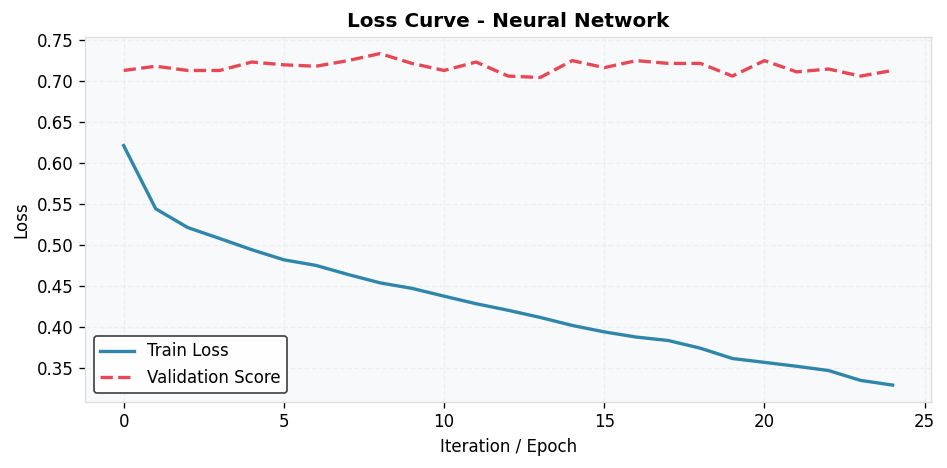

✅  Loss curve saved


In [ ]:
# -- Neural Network loss curve --
if hasattr(nn_best, 'loss_curve_'):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(nn_best.loss_curve_, color='#2E86AB', linewidth=2, label='Train Loss')
    if hasattr(nn_best, 'validation_scores_') and nn_best.validation_scores_ is not None:
        ax.plot(nn_best.validation_scores_, color='#E84855', linewidth=2,
                linestyle='--', label='Validation Score')
    ax.set_xlabel('Iteration / Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss Curve - Neural Network', fontsize=12, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_sup_nn_loss.png', bbox_inches='tight')
    plt.show()
    print('✅  Loss curve saved')
else:
    print('ℹ️   Loss curve not available for this configuration')

### 8.6 Baseline — DummyClassifier

Referencia mínima para contextualizar el desempeño de los modelos.

In [ ]:
# ============================================================
# 8.6 — BASELINE DUMMYCLASSIFIER
# ============================================================

dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train_imp, y_train)
y_pred_dum  = dummy_strat.predict(X_test_imp)
y_prob_dum  = dummy_strat.predict_proba(X_test_imp)[:, 1]

acc_dum  = accuracy_score(y_test, y_pred_dum)
bacc_dum = balanced_accuracy_score(y_test, y_pred_dum)
f1_dum   = f1_score(y_test, y_pred_dum, average='macro')
try:
    auc_dum = roc_auc_score(y_test, y_prob_dum)
except:
    auc_dum = 0.5
prec_dum, rec_dum, _, _ = precision_recall_fscore_support(y_test, y_pred_dum, labels=[0,1])

print(f'Baseline — Accuracy: {acc_dum:.4f}  |  Macro F1: {f1_dum:.4f}  |  ROC-AUC: {auc_dum:.4f}')

Baseline — Accuracy: 0.5389  |  Macro F1: 0.5120  |  ROC-AUC: 0.5121


### 8.7 Tabla Comparativa de Modelos

In [ ]:
# ============================================================
# 8.7 — TABLA COMPARATIVA
# ============================================================

comparison = pd.DataFrame([
    {
        'Modelo'           : 'Random Forest',
        'Accuracy'         : round(acc_rf, 4),
        'Balanced Accuracy': round(bacc_rf, 4),
        'Macro F1'         : round(f1_rf, 4),
        'ROC-AUC'          : round(auc_rf, 4),
        'Recall SEG_B'     : round(rec_rf[0], 4),
        'Recall SEG_C'     : round(rec_rf[1], 4),
    },
    {
        'Modelo'           : 'Neural Network (MLP)',
        'Accuracy'         : round(acc_nn, 4),
        'Balanced Accuracy': round(bacc_nn, 4),
        'Macro F1'         : round(f1_nn, 4),
        'ROC-AUC'          : round(auc_nn, 4),
        'Recall SEG_B'     : round(rec_nn[0], 4),
        'Recall SEG_C'     : round(rec_nn[1], 4),
    },
    {
        'Modelo'           : 'Baseline (Dummy)',
        'Accuracy'         : round(acc_dum, 4),
        'Balanced Accuracy': round(bacc_dum, 4),
        'Macro F1'         : round(f1_dum, 4),
        'ROC-AUC'          : round(auc_dum, 4),
        'Recall SEG_B'     : round(rec_dum[0], 4),
        'Recall SEG_C'     : round(rec_dum[1], 4),
    }
])
comparison = comparison.set_index('Modelo')

display(comparison.style
        .background_gradient(subset=['Macro F1'], cmap='Greens')
        .background_gradient(subset=['ROC-AUC'], cmap='Blues')
        .background_gradient(subset=['Balanced Accuracy'], cmap='Oranges')
        .format('{:.4f}')
        .set_caption('Comparación de Modelos Supervisados — Test Set'))

# Determinar ganador
if f1_rf > f1_nn + 0.02:
    winner = 'Random Forest'
    winner_msg = 'Random Forest supera claramente a Neural Network. Recomendado por interpretabilidad y menor complejidad.'
elif f1_nn > f1_rf + 0.02:
    winner = 'Neural Network'
    winner_msg = 'Neural Network supera a Random Forest. Evaluar si la mejora justifica mayor complejidad operativa.'
else:
    winner = 'Empate técnico'
    winner_msg = 'Desempeño similar entre ambos modelos. Random Forest preferido por parsimonia e interpretabilidad.'

print(f'\n🏆  Resultado: {winner}')
print(f'    {winner_msg}')

,Accuracy,Balanced Accuracy,Macro F1,ROC-AUC,Recall SEG_B,Recall SEG_C
Modelo,,,,,,
Random Forest,0.7330,0.7187,0.7178,0.7975,0.7780,0.6594
Neural Network (MLP),0.7275,0.6950,0.7001,0.8012,0.8302,0.5598
Baseline (Dummy),0.5389,0.5121,0.5120,0.5121,0.6238,0.4004



🏆  Resultado: Empate técnico
    Desempeño similar entre ambos modelos. Random Forest preferido por parsimonia e interpretabilidad.


### 8.8 Visualizaciones Profesionales

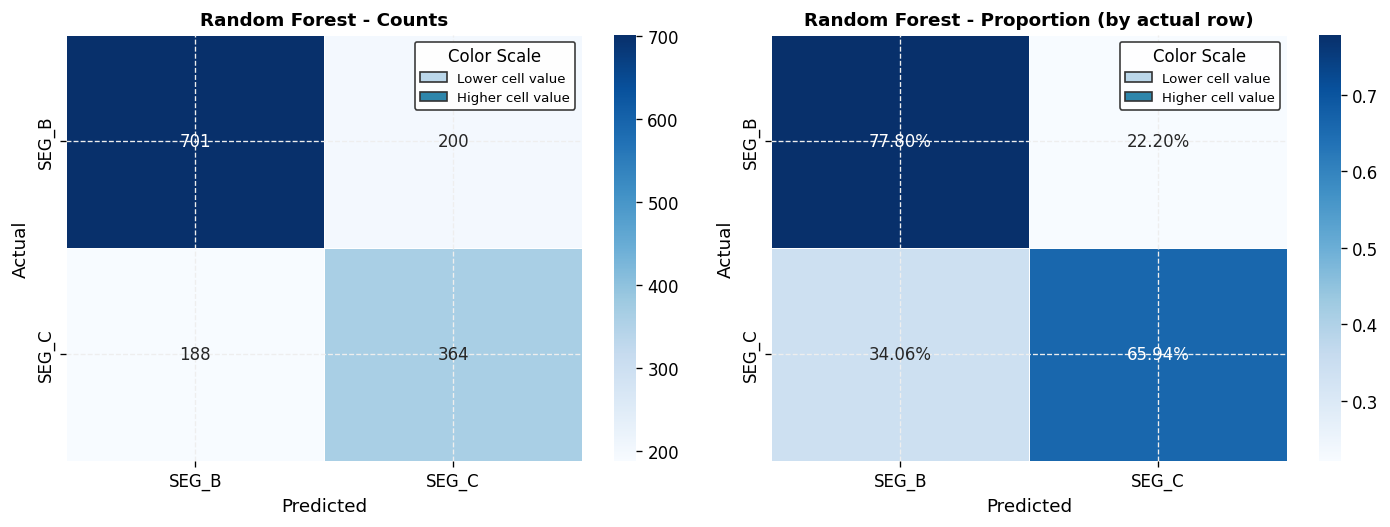

✅  fig_14_rf_confusion_matrix.png


In [ ]:
# ============================================================
# fig_14 -- RF Confusion Matrix
# ============================================================

def plot_confusion(y_true, y_pred, title, figname, labels=['SEG_B', 'SEG_C']):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#BBD7EA', edgecolor='#333333', label='Lower cell value'),
        Patch(facecolor='#2E86AB', edgecolor='#333333', label='Higher cell value')
    ]

    for ax, data, fmt, ttl in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2%'],
        ['Counts', 'Proportion (by actual row)']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, cbar=True)
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('Actual', fontsize=11)
        ax.set_title(f'{title} - {ttl}', fontsize=11, fontweight='bold')
        ax.legend(handles=legend_elements, fontsize=8, title='Color Scale')

    plt.tight_layout()
    plt.savefig(figname, bbox_inches='tight')
    plt.show()
    print(f'✅  {figname}')

plot_confusion(y_test, y_pred_rf, 'Random Forest', 'fig_14_rf_confusion_matrix.png')

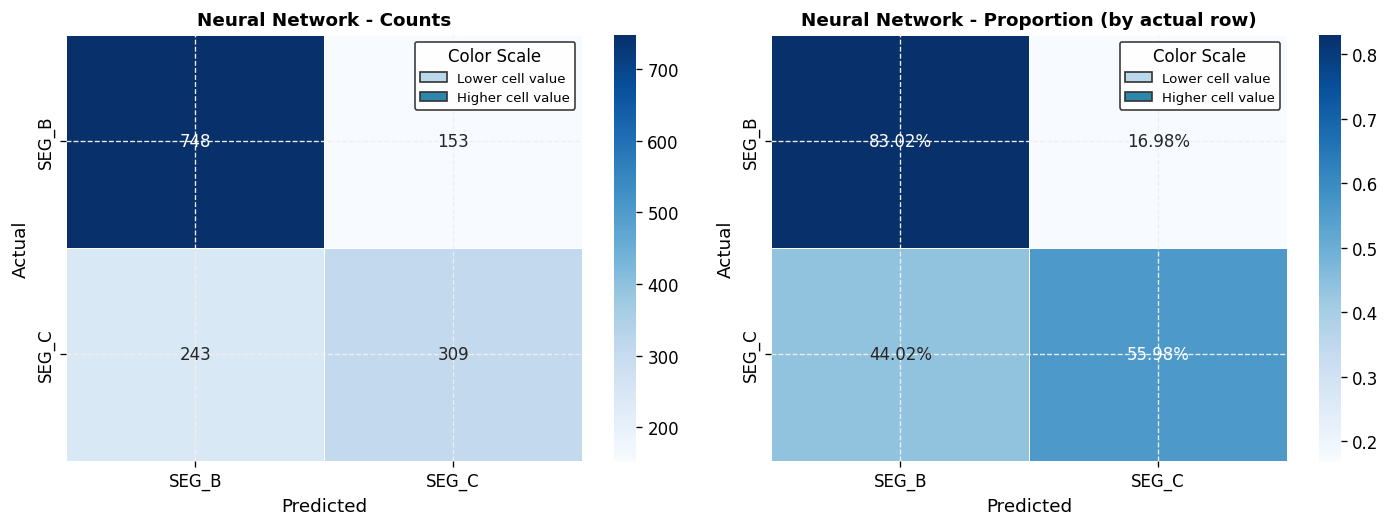

✅  fig_15_nn_confusion_matrix.png


In [ ]:
# -- fig_15: NN Confusion Matrix --
plot_confusion(y_test, y_pred_nn, 'Neural Network', 'fig_15_nn_confusion_matrix.png')

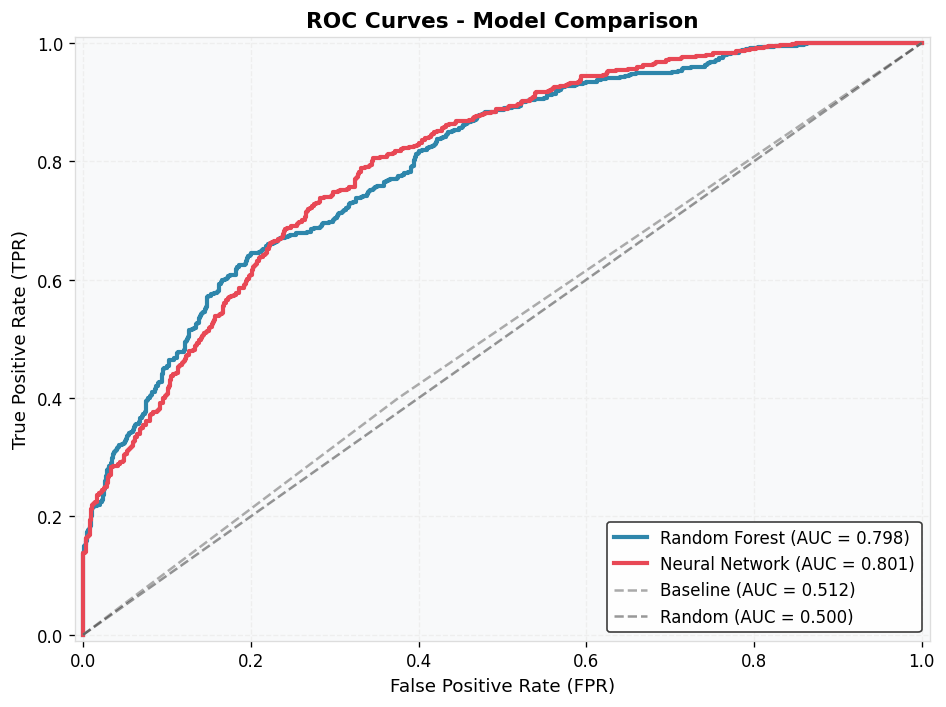

✅  fig_16_roc_curves.png


In [ ]:
# -- fig_16: Comparative ROC Curves --
fig, ax = plt.subplots(figsize=(8, 6))

for (name, y_prob, col) in [
    ('Random Forest', y_prob_rf, PALETTE[0]),
    ('Neural Network', y_prob_nn, PALETTE[1]),
    ('Baseline', y_prob_dum, '#AAAAAA')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    lw = 2.5 if name != 'Baseline' else 1.5
    ls = '-' if name != 'Baseline' else '--'
    ax.plot(fpr, tpr, color=col, lw=lw, linestyle=ls,
            label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (AUC = 0.500)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC Curves - Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('fig_16_roc_curves.png', bbox_inches='tight')
plt.show()
print('✅  fig_16_roc_curves.png')

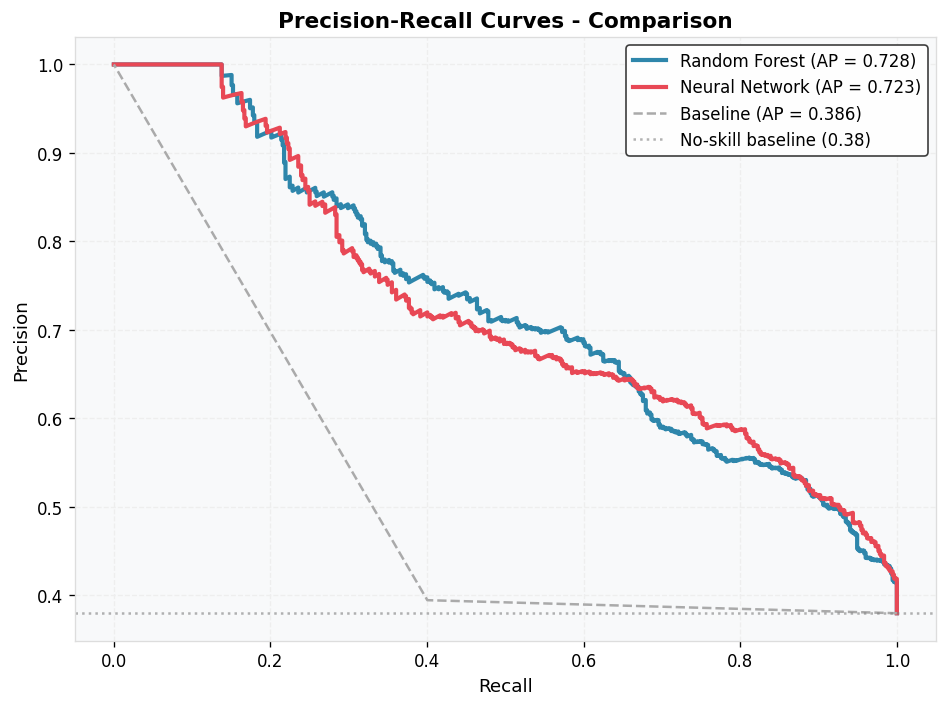

✅  fig_17_precision_recall_curves.png


In [ ]:
# -- fig_17: Precision-Recall Curves --
fig, ax = plt.subplots(figsize=(8, 6))

for (name, y_prob, col) in [
    ('Random Forest', y_prob_rf, PALETTE[0]),
    ('Neural Network', y_prob_nn, PALETTE[1]),
    ('Baseline', y_prob_dum, '#AAAAAA')
]:
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    lw = 2.5 if name != 'Baseline' else 1.5
    ls = '-' if name != 'Baseline' else '--'
    ax.plot(rec_c, prec_c, color=col, lw=lw, linestyle=ls,
            label=f'{name} (AP = {ap:.3f})')

baseline_precision = y_test.mean()
ax.axhline(baseline_precision, color='grey', linestyle=':', alpha=0.6,
           label=f'No-skill baseline ({baseline_precision:.2f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves - Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_17_precision_recall_curves.png', bbox_inches='tight')
plt.show()
print('✅  fig_17_precision_recall_curves.png')

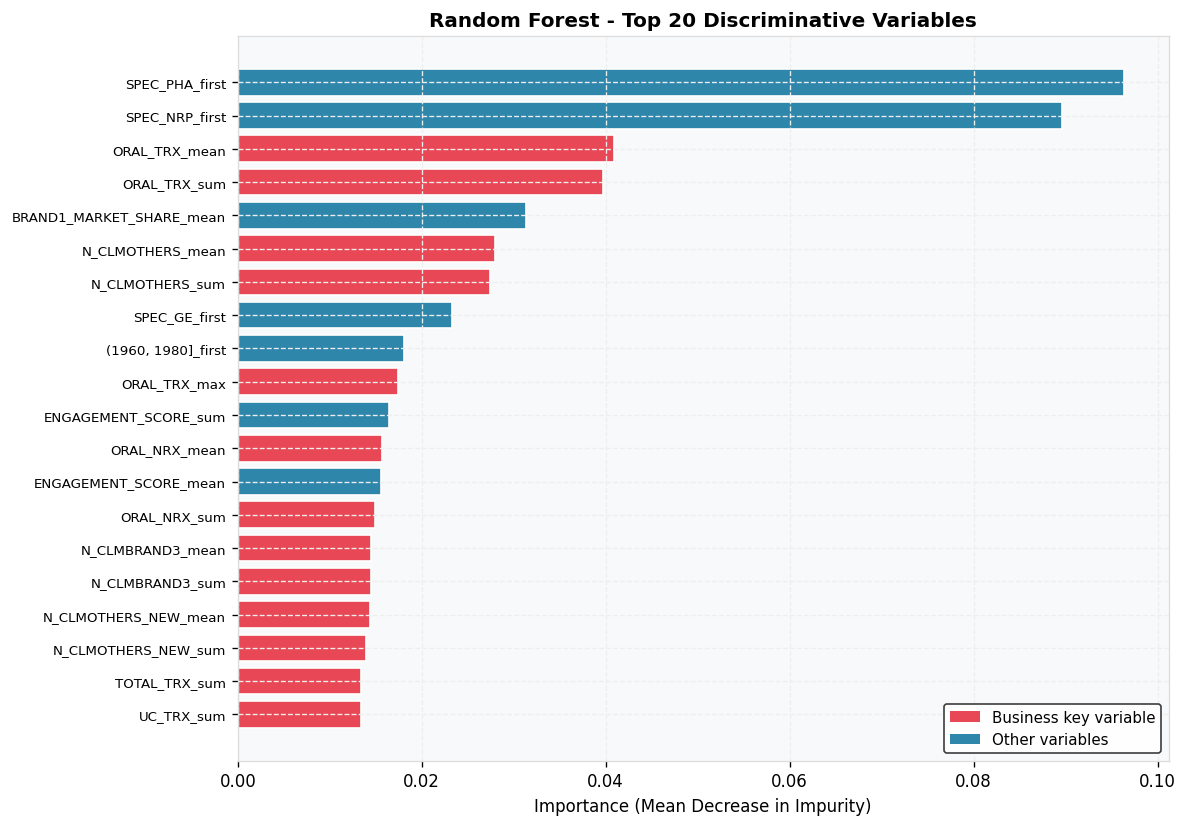

✅  fig_18_rf_feature_importance.png


In [ ]:
# -- fig_18: RF Feature Importance Top 20 --
rf_imp_series = pd.Series(
    rf_best.feature_importances_,
    index=sup_feature_names
).sort_values(ascending=False)

TOP_N = 20
top_rf = rf_imp_series.head(TOP_N)

# Mark business key variables
KEY_VARS = ['TOTAL_NRX','TOTAL_TRX','UC_TRX','UC_NRX','ORAL_NRX','ORAL_TRX',
            'N_CLMOTHERS','N_CLMBRAND3']
colors_rf = ['#E84855' if any(k in f.upper() for k in
             [v.upper() for v in KEY_VARS]) else '#2E86AB'
             for f in top_rf.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(TOP_N), top_rf.values[::-1], color=colors_rf[::-1], edgecolor='white')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels([f[:40] for f in top_rf.index[::-1]], fontsize=8)
ax.set_xlabel('Importance (Mean Decrease in Impurity)', fontsize=10)
ax.set_title(f'Random Forest - Top {TOP_N} Discriminative Variables', fontsize=12, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E84855', label='Business key variable'),
                   Patch(facecolor='#2E86AB', label='Other variables')]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('fig_18_rf_feature_importance.png', bbox_inches='tight')
plt.show()
print('✅  fig_18_rf_feature_importance.png')

Computing permutation importance for Neural Network (may take ~2 min)...


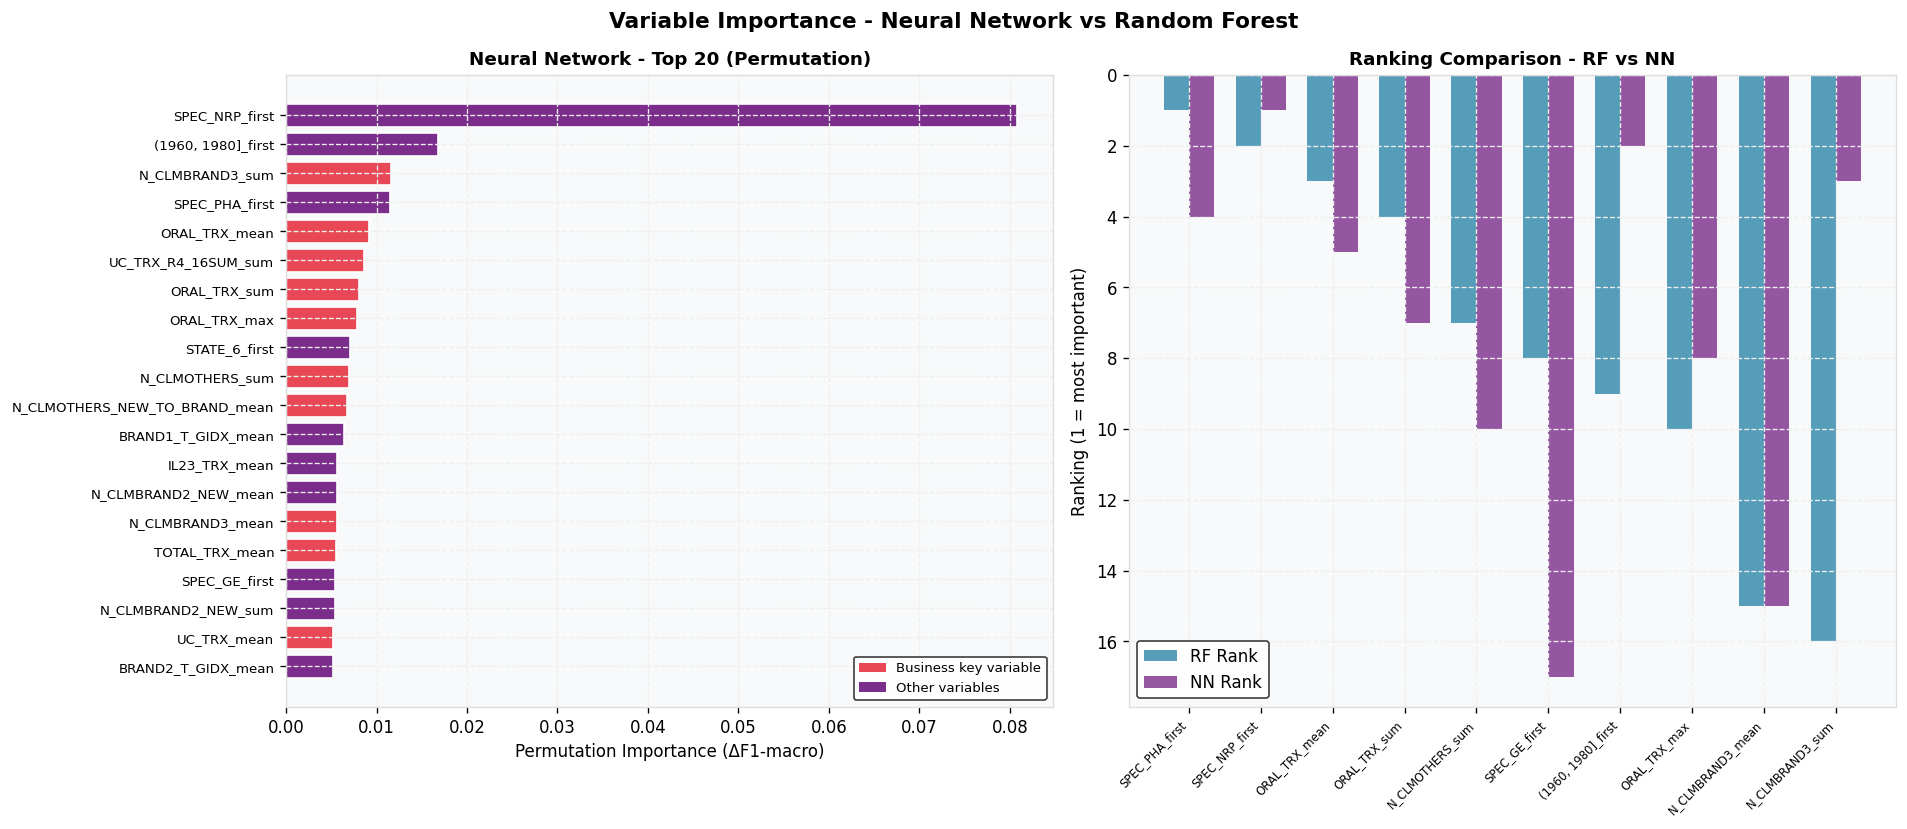

✅  fig_19_nn_permutation_importance.png


In [ ]:
# -- fig_19: NN Permutation Importance --
print('Computing permutation importance for Neural Network (may take ~2 min)...')

perm_imp = permutation_importance(
    nn_best, X_test_sc, y_test,
    n_repeats=10, random_state=42,
    scoring='f1_macro', n_jobs=-1
)

perm_series = pd.Series(
    perm_imp.importances_mean,
    index=sup_feature_names
).sort_values(ascending=False)

top_perm = perm_series.head(TOP_N)

colors_nn = ['#E84855' if any(k in f.upper() for k in
             [v.upper() for v in KEY_VARS]) else '#7B2D8B'
             for f in top_perm.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# NN Permutation
axes[0].barh(range(TOP_N), top_perm.values[::-1], color=colors_nn[::-1], edgecolor='white')
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels([f[:35] for f in top_perm.index[::-1]], fontsize=8)
axes[0].set_xlabel('Permutation Importance (ΔF1-macro)')
axes[0].set_title('Neural Network - Top 20 (Permutation)', fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
legend_elements_left = [
    Patch(facecolor='#E84855', label='Business key variable'),
    Patch(facecolor='#7B2D8B', label='Other variables')
]
axes[0].legend(handles=legend_elements_left, fontsize=8)

# Compare RF vs NN ranks
common = set(top_rf.index) & set(top_perm.index)
rank_rf   = {f: i+1 for i, f in enumerate(rf_imp_series.index)}
rank_nn   = {f: i+1 for i, f in enumerate(perm_series.index)}
rank_df   = pd.DataFrame([
    {'feature': f, 'RF_rank': rank_rf.get(f, 999), 'NN_rank': rank_nn.get(f, 999)}
    for f in list(common)[:15]
]).sort_values('RF_rank')

x_ = np.arange(len(rank_df))
w  = 0.35
axes[1].bar(x_-w/2, rank_df['RF_rank'], w, label='RF Rank', color=PALETTE[0], alpha=0.8)
axes[1].bar(x_+w/2, rank_df['NN_rank'], w, label='NN Rank', color='#7B2D8B', alpha=0.8)
axes[1].set_xticks(x_)
axes[1].set_xticklabels([f[:20] for f in rank_df['feature']], rotation=45, ha='right', fontsize=7)
axes[1].invert_yaxis()  # Rank 1 at top
axes[1].set_ylabel('Ranking (1 = most important)')
axes[1].set_title('Ranking Comparison - RF vs NN', fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle('Variable Importance - Neural Network vs Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_19_nn_permutation_importance.png', bbox_inches='tight')
plt.show()
print('✅  fig_19_nn_permutation_importance.png')

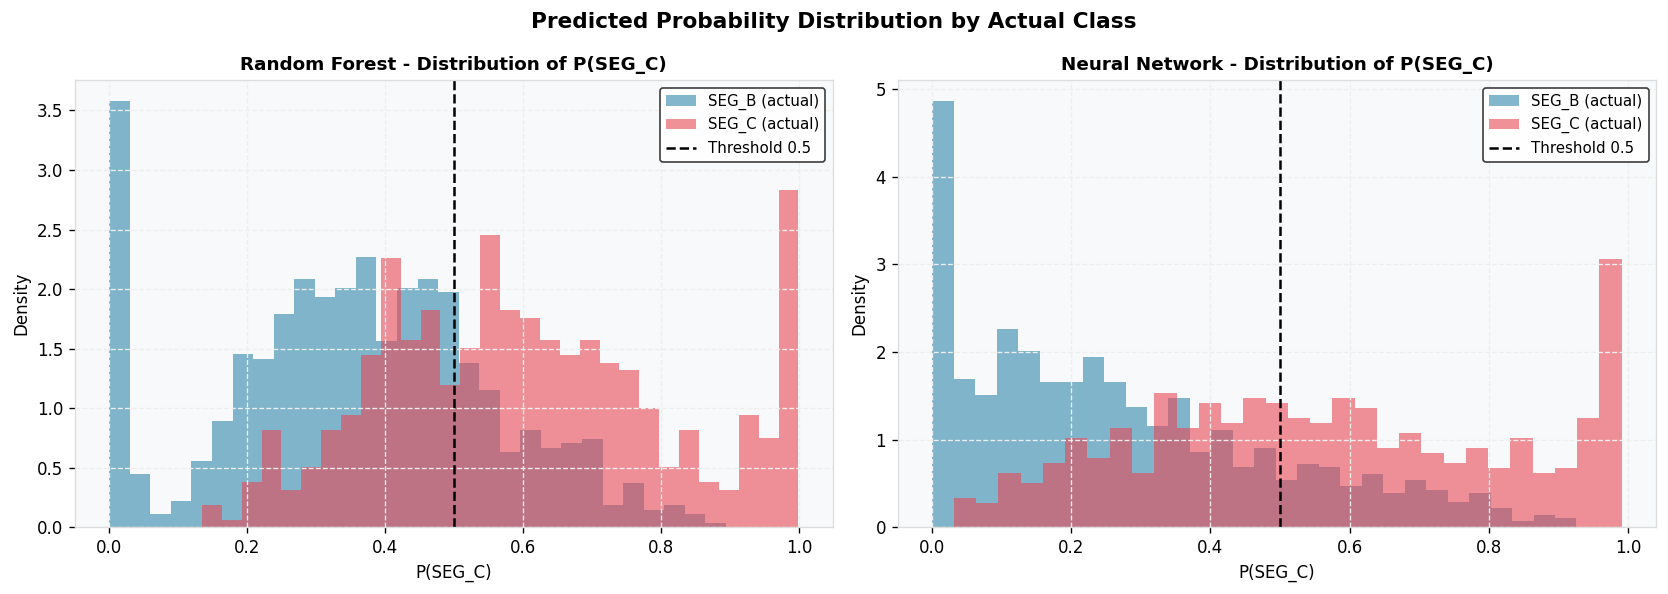

✅  fig_20_predicted_probabilities.png

📊  Records in uncertainty zone (0.4-0.6):
    Random Forest : 32.8%
    Neural Network: 19.5%
    ⚠️  High proportion in uncertainty zone -> B/C boundary is not clearly separated


In [ ]:
# -- fig_20: Predicted probability distributions --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_prob) in zip(axes, [
    ('Random Forest', y_prob_rf),
    ('Neural Network', y_prob_nn)
]):
    for cls, lbl, col in [(0, 'SEG_B (actual)', PALETTE[0]), (1, 'SEG_C (actual)', PALETTE[1])]:
        mask = y_test == cls
        ax.hist(y_prob[mask], bins=30, alpha=0.6, color=col,
                label=lbl, density=True, edgecolor='none')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.5')
    ax.set_xlabel('P(SEG_C)', fontsize=10)
    ax.set_ylabel('Density')
    ax.set_title(f'{name} - Distribution of P(SEG_C)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Predicted Probability Distribution by Actual Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_20_predicted_probabilities.png', bbox_inches='tight')
plt.show()
print('✅  fig_20_predicted_probabilities.png')

# -- Overlap diagnostics --
overlap_rf = np.mean((y_prob_rf > 0.4) & (y_prob_rf < 0.6))
overlap_nn = np.mean((y_prob_nn > 0.4) & (y_prob_nn < 0.6))
print(f'\n📊  Records in uncertainty zone (0.4-0.6):')
print(f'    Random Forest : {overlap_rf:.1%}')
print(f'    Neural Network: {overlap_nn:.1%}')
if overlap_rf > 0.25:
    print('    ⚠️  High proportion in uncertainty zone -> B/C boundary is not clearly separated')

### 8.9 Análisis Crítico

Respondemos las seis preguntas clave del análisis.

In [ ]:
# ============================================================
# 8.9 — ANÁLISIS CRÍTICO AUTOMATIZADO
# ============================================================

print('='*65)
print('ANÁLISIS CRÍTICO — MODELOS SUPERVISADOS SEG_B vs SEG_C')
print('='*65)

THRESHOLD_GOOD_F1  = 0.70
THRESHOLD_MOD_F1   = 0.60
THRESHOLD_BAD_F1   = 0.55

best_f1 = max(f1_rf, f1_nn)

# ── Q1: ¿Son SEG_B y SEG_C separables? ───────────────────────
print('\n❓ Q1: ¿SEG_B y SEG_C son separables de manera supervisada?')
if best_f1 >= THRESHOLD_GOOD_F1:
    print(f'   ✅  SÍ — F1-macro máximo: {best_f1:.3f} > {THRESHOLD_GOOD_F1}.')
    print('      Los modelos aprenden una frontera clara. Los segmentos son válidos.')
elif best_f1 >= THRESHOLD_MOD_F1:
    print(f'   ⚠️   PARCIALMENTE — F1-macro máximo: {best_f1:.3f}.')
    print('      Hay señal, pero la frontera es difusa. Los segmentos se solapan.')
else:
    print(f'   ❌  NO — F1-macro máximo: {best_f1:.3f} < {THRESHOLD_MOD_F1}.')
    print('      Los modelos no logran separar claramente B y C. Problema de etiquetas.')

# ── Q2: ¿RF supera claramente a NN? ──────────────────────────
print('\n❓ Q2: ¿Random Forest supera claramente a Neural Network?')
delta_f1 = abs(f1_rf - f1_nn)
if delta_f1 >= 0.03:
    mejor = 'Random Forest' if f1_rf > f1_nn else 'Neural Network'
    print(f'   ✅  SÍ — Diferencia F1-macro: {delta_f1:.3f}. {mejor} es superior.')
else:
    print(f'   ➡️   NO — Diferencia F1-macro mínima: {delta_f1:.3f}.')
    print('      Desempeño estadísticamente equivalente.')

# ── Q3: ¿NN aporta algo? ─────────────────────────────────────
print('\n❓ Q3: ¿Neural Network justifica mayor complejidad?')
nn_lift = f1_nn - f1_rf
if nn_lift > 0.02:
    print(f'   ✅  SÍ — NN mejora {nn_lift:.3f} F1-macro sobre RF.')
    print('      La complejidad adicional está justificada.')
else:
    print(f'   ❌  NO — NN no mejora significativamente sobre RF (delta={nn_lift:.3f}).')
    print('      Recomendación: usar Random Forest por su interpretabilidad y menor costo operativo.')

# ── Q4: ¿Errores concentrados en SEG_C? ──────────────────────
print('\n❓ Q4: ¿Los errores se concentran en SEG_C?')
err_b_rf = 1 - rec_rf[0]
err_c_rf = 1 - rec_rf[1]
print(f'   RF — Error SEG_B: {err_b_rf:.1%}  |  Error SEG_C: {err_c_rf:.1%}')
if abs(err_b_rf - err_c_rf) > 0.10:
    worse = 'SEG_C' if err_c_rf > err_b_rf else 'SEG_B'
    print(f'   ⚠️   SÍ — {worse} tiene significativamente más errores.')
    if worse == 'SEG_C':
        print('      SEG_C puede ser un grupo heterogéneo internamente.')
else:
    print('   ✅  Errores distribuidos de forma similar entre ambas clases.')

# ── Q5: ¿Problema de modelo o de etiquetas? ──────────────────
print('\n❓ Q5: ¿El problema es de modelo o de definición de etiquetas?')
if best_f1 < THRESHOLD_BAD_F1:
    print('   📌  PROBLEMA DE ETIQUETAS — Múltiples algoritmos sofisticados fallan.')
    print('      Los datos no contienen información suficiente para distinguir B de C.')
    print('      Conclusión: SEG_B y SEG_C comparten el mismo espacio de features.')
elif best_f1 < THRESHOLD_GOOD_F1:
    print('   📌  PROBLEMA MIXTO — Hay señal pero también ambigüedad en las etiquetas.')
    print('      Posiblemente algunos registros fueron mal etiquetados históricamente.')
else:
    print('   📌  PROBLEMA DE MODELO — Las etiquetas son separables.')
    print('      El modelo actual ya es suficientemente bueno.')

# ── Q6: ¿Mantener, redefinir o crear subsegmentos? ───────────
print('\n❓ Q6: ¿Conviene mantener SEG_B/SEG_C, redefinirlos o crear subsegmentos?')
if best_f1 >= THRESHOLD_GOOD_F1:
    print('   📋  MANTENER con ajustes: la frontera existe y es aprendible.')
    print('      Mejorar el proceso de etiquetado para reducir ruido marginal.')
elif best_f1 >= THRESHOLD_MOD_F1:
    print('   📋  REDEFINIR: revisar criterios de asignación B/C.')
    print('      Usar los clusters descubiertos en Partes 4-5 como nueva referencia.')
else:
    print('   📋  REDESIGN COMPLETO: la distinción B/C no está soportada por los datos.')
    print('      Adoptar los clusters no supervisados como nueva segmentación base.')
    print('      Redefinir B y C desde criterios de negocio, no de patrones históricos.')

print('\n' + '='*65)

ANÁLISIS CRÍTICO — MODELOS SUPERVISADOS SEG_B vs SEG_C

❓ Q1: ¿SEG_B y SEG_C son separables de manera supervisada?
   ✅  SÍ — F1-macro máximo: 0.718 > 0.7.
      Los modelos aprenden una frontera clara. Los segmentos son válidos.

❓ Q2: ¿Random Forest supera claramente a Neural Network?
   ➡️   NO — Diferencia F1-macro mínima: 0.018.
      Desempeño estadísticamente equivalente.

❓ Q3: ¿Neural Network justifica mayor complejidad?
   ❌  NO — NN no mejora significativamente sobre RF (delta=-0.018).
      Recomendación: usar Random Forest por su interpretabilidad y menor costo operativo.

❓ Q4: ¿Los errores se concentran en SEG_C?
   RF — Error SEG_B: 22.2%  |  Error SEG_C: 34.1%
   ⚠️   SÍ — SEG_C tiene significativamente más errores.
      SEG_C puede ser un grupo heterogéneo internamente.

❓ Q5: ¿El problema es de modelo o de definición de etiquetas?
   📌  PROBLEMA DE MODELO — Las etiquetas son separables.
      El modelo actual ya es suficientemente bueno.

❓ Q6: ¿Conviene mantener SE

### 8.10 Outputs — Dataset con Predicciones

In [ ]:
# ============================================================
# 8.10 — GUARDAR OUTPUTS
# ============================================================

# ── Dataset de predicciones ───────────────────────────────────
df_pred = pd.DataFrame({
    'NUEVO_ID'      : IDs_test.values,
    'SEGMENT_FINAL' : df_sup.loc[IDs_test.index, 'SEGMENT_FINAL'].values
                      if 'SEGMENT_FINAL' in df_sup.columns
                      else ['SEG_B' if y==0 else 'SEG_C' for y in y_test.values],
    'y_true'        : y_test.values,
    'rf_pred'       : y_pred_rf,
    'rf_prob_seg_c' : y_prob_rf.round(4),
    'nn_pred'       : y_pred_nn,
    'nn_prob_seg_c' : y_prob_nn.round(4),
    'rf_correct'    : (y_pred_rf == y_test.values).astype(int),
    'nn_correct'    : (y_pred_nn == y_test.values).astype(int),
    'both_correct'  : ((y_pred_rf == y_test.values) & (y_pred_nn == y_test.values)).astype(int),
    'both_wrong'    : ((y_pred_rf != y_test.values) & (y_pred_nn != y_test.values)).astype(int),
})

df_pred.to_csv('supervised_predictions_bc.csv', index=False)
print(f'💾  supervised_predictions_bc.csv guardado ({len(df_pred):,} filas)')

# Resumen de acuerdos/desacuerdos entre modelos
agree = (df_pred['rf_pred'] == df_pred['nn_pred']).mean()
both_wrong_n = df_pred['both_wrong'].sum()
print(f'\n📊  Acuerdo RF ↔ NN      : {agree:.1%}')
print(f'    Ambos incorrectos     : {both_wrong_n:,} ({both_wrong_n/len(df_pred):.1%})')
print(f'    Ambos correctos       : {df_pred["both_correct"].sum():,} ({df_pred["both_correct"].mean():.1%})')

display(df_pred.head())

💾  supervised_predictions_bc.csv guardado (1,453 filas)

📊  Acuerdo RF ↔ NN      : 83.2%
    Ambos incorrectos     : 270 (18.6%)
    Ambos correctos       : 939 (64.6%)


,NUEVO_ID,SEGMENT_FINAL,y_true,rf_pred,rf_prob_seg_c,nn_pred,nn_prob_seg_c,rf_correct,nn_correct,both_correct,both_wrong
0,15351,SEG_B,0,0,0.3729,0,0.3775,1,1,1,0
1,5301,SEG_B,0,0,0.2265,0,0.1261,1,1,1,0
2,11093,SEG_C,1,1,0.5708,1,0.5895,1,1,1,0
3,15484,SEG_B,0,1,0.5699,0,0.2285,0,1,0,0
4,10531,SEG_B,0,0,0.3586,0,0.3001,1,1,1,0


---
## Resumen de Outputs — Parte 8

| Archivo | Descripción |
|---------|-------------|
| `supervised_predictions_bc.csv` | Predicciones RF y NN por médico en test set |
| `fig_14_rf_confusion_matrix.png` | Matrices de confusión Random Forest |
| `fig_15_nn_confusion_matrix.png` | Matrices de confusión Neural Network |
| `fig_16_roc_curves.png` | Curvas ROC comparativas |
| `fig_17_precision_recall_curves.png` | Curvas Precision-Recall |
| `fig_18_rf_feature_importance.png` | Feature importance Random Forest top 20 |
| `fig_19_nn_permutation_importance.png` | Permutation importance NN + ranking comparado |
| `fig_20_predicted_probabilities.png` | Distribución de probabilidades predichas |

---
*Parte 8 — Modelos Supervisados | Data Science Team | 2024*